# Mini Project Notebook: Principal Component Analysis PCA

## Dr. Prashanth Kannadaguli
### Founding Chief Research Architect & President
### Dhaarini AI-Tech Research Academy, Bengaluru, India

In [107]:
# Load the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, log_loss, silhouette_score)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier)
from xgboost import XGBClassifier

sns.set_style('whitegrid')

# DATASET


*   marketing_campaign.csv
*   Label: Response
*   Features: All other columns

Load the "marketing_campaign.csv" dataset into a Pandas DataFrame.

In [108]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

## EDA

Print the shape, data types, and first few rows of the DataFrame.


In [109]:
print('Shape:', df.shape)
print('\nData types:\n', df.dtypes)
df.head()

Shape: (2240, 29)

Data types:
 ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Identify missing values in each column and calculate the percentage of missing data.


In [110]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({'Missing Values': missing,
                           'Percentage (%)': (missing / len(df) * 100).round(2)})
missing_df

,Missing Values,Percentage (%)
ID,0,0.00
Year_Birth,0,0.00
Education,0,0.00
Marital_Status,0,0.00
Income,24,1.07
Kidhome,0,0.00
Teenhome,0,0.00
Dt_Customer,0,0.00
Recency,0,0.00
MntWines,0,0.00


Check for any inconsistencies in the data (e.g., invalid values, typos) and correct them.

In [111]:
print(df['Education'].value_counts(), '\n')
print(df['Marital_Status'].value_counts(), '\n')
print('Duplicate rows:', df.duplicated().sum())
print('Year_Birth min:', df['Year_Birth'].min(), '| Income max:', df['Income'].max())

# 'Alone', 'Absurd' and 'YOLO' are not valid marital statuses -> 'Single'
df['Marital_Status'] = df['Marital_Status'].replace({'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single'})
# '2n Cycle' is the same level as 'Master'
df['Education'] = df['Education'].replace({'2n Cycle': 'Master'})
# Remove duplicates and impossible birth years (age > 100)
df = df.drop_duplicates()
df = df[df['Year_Birth'] > 1900].reset_index(drop=True)
# Impute the missing Income values with the median
df['Income'] = df['Income'].fillna(df['Income'].median())

print('\nAfter cleaning:', df.shape)
print(df['Marital_Status'].value_counts())
print('Missing values left:', df.isnull().sum().sum())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64 

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Duplicate rows: 0
Year_Birth min: 1893 | Income max: 666666.0

After cleaning: (2237, 29)
Marital_Status
Married     864
Together    579
Single      486
Divorced    231
Widow        77
Name: count, dtype: int64
Missing values left: 0


Create histograms for numerical variables to understand their distributions.


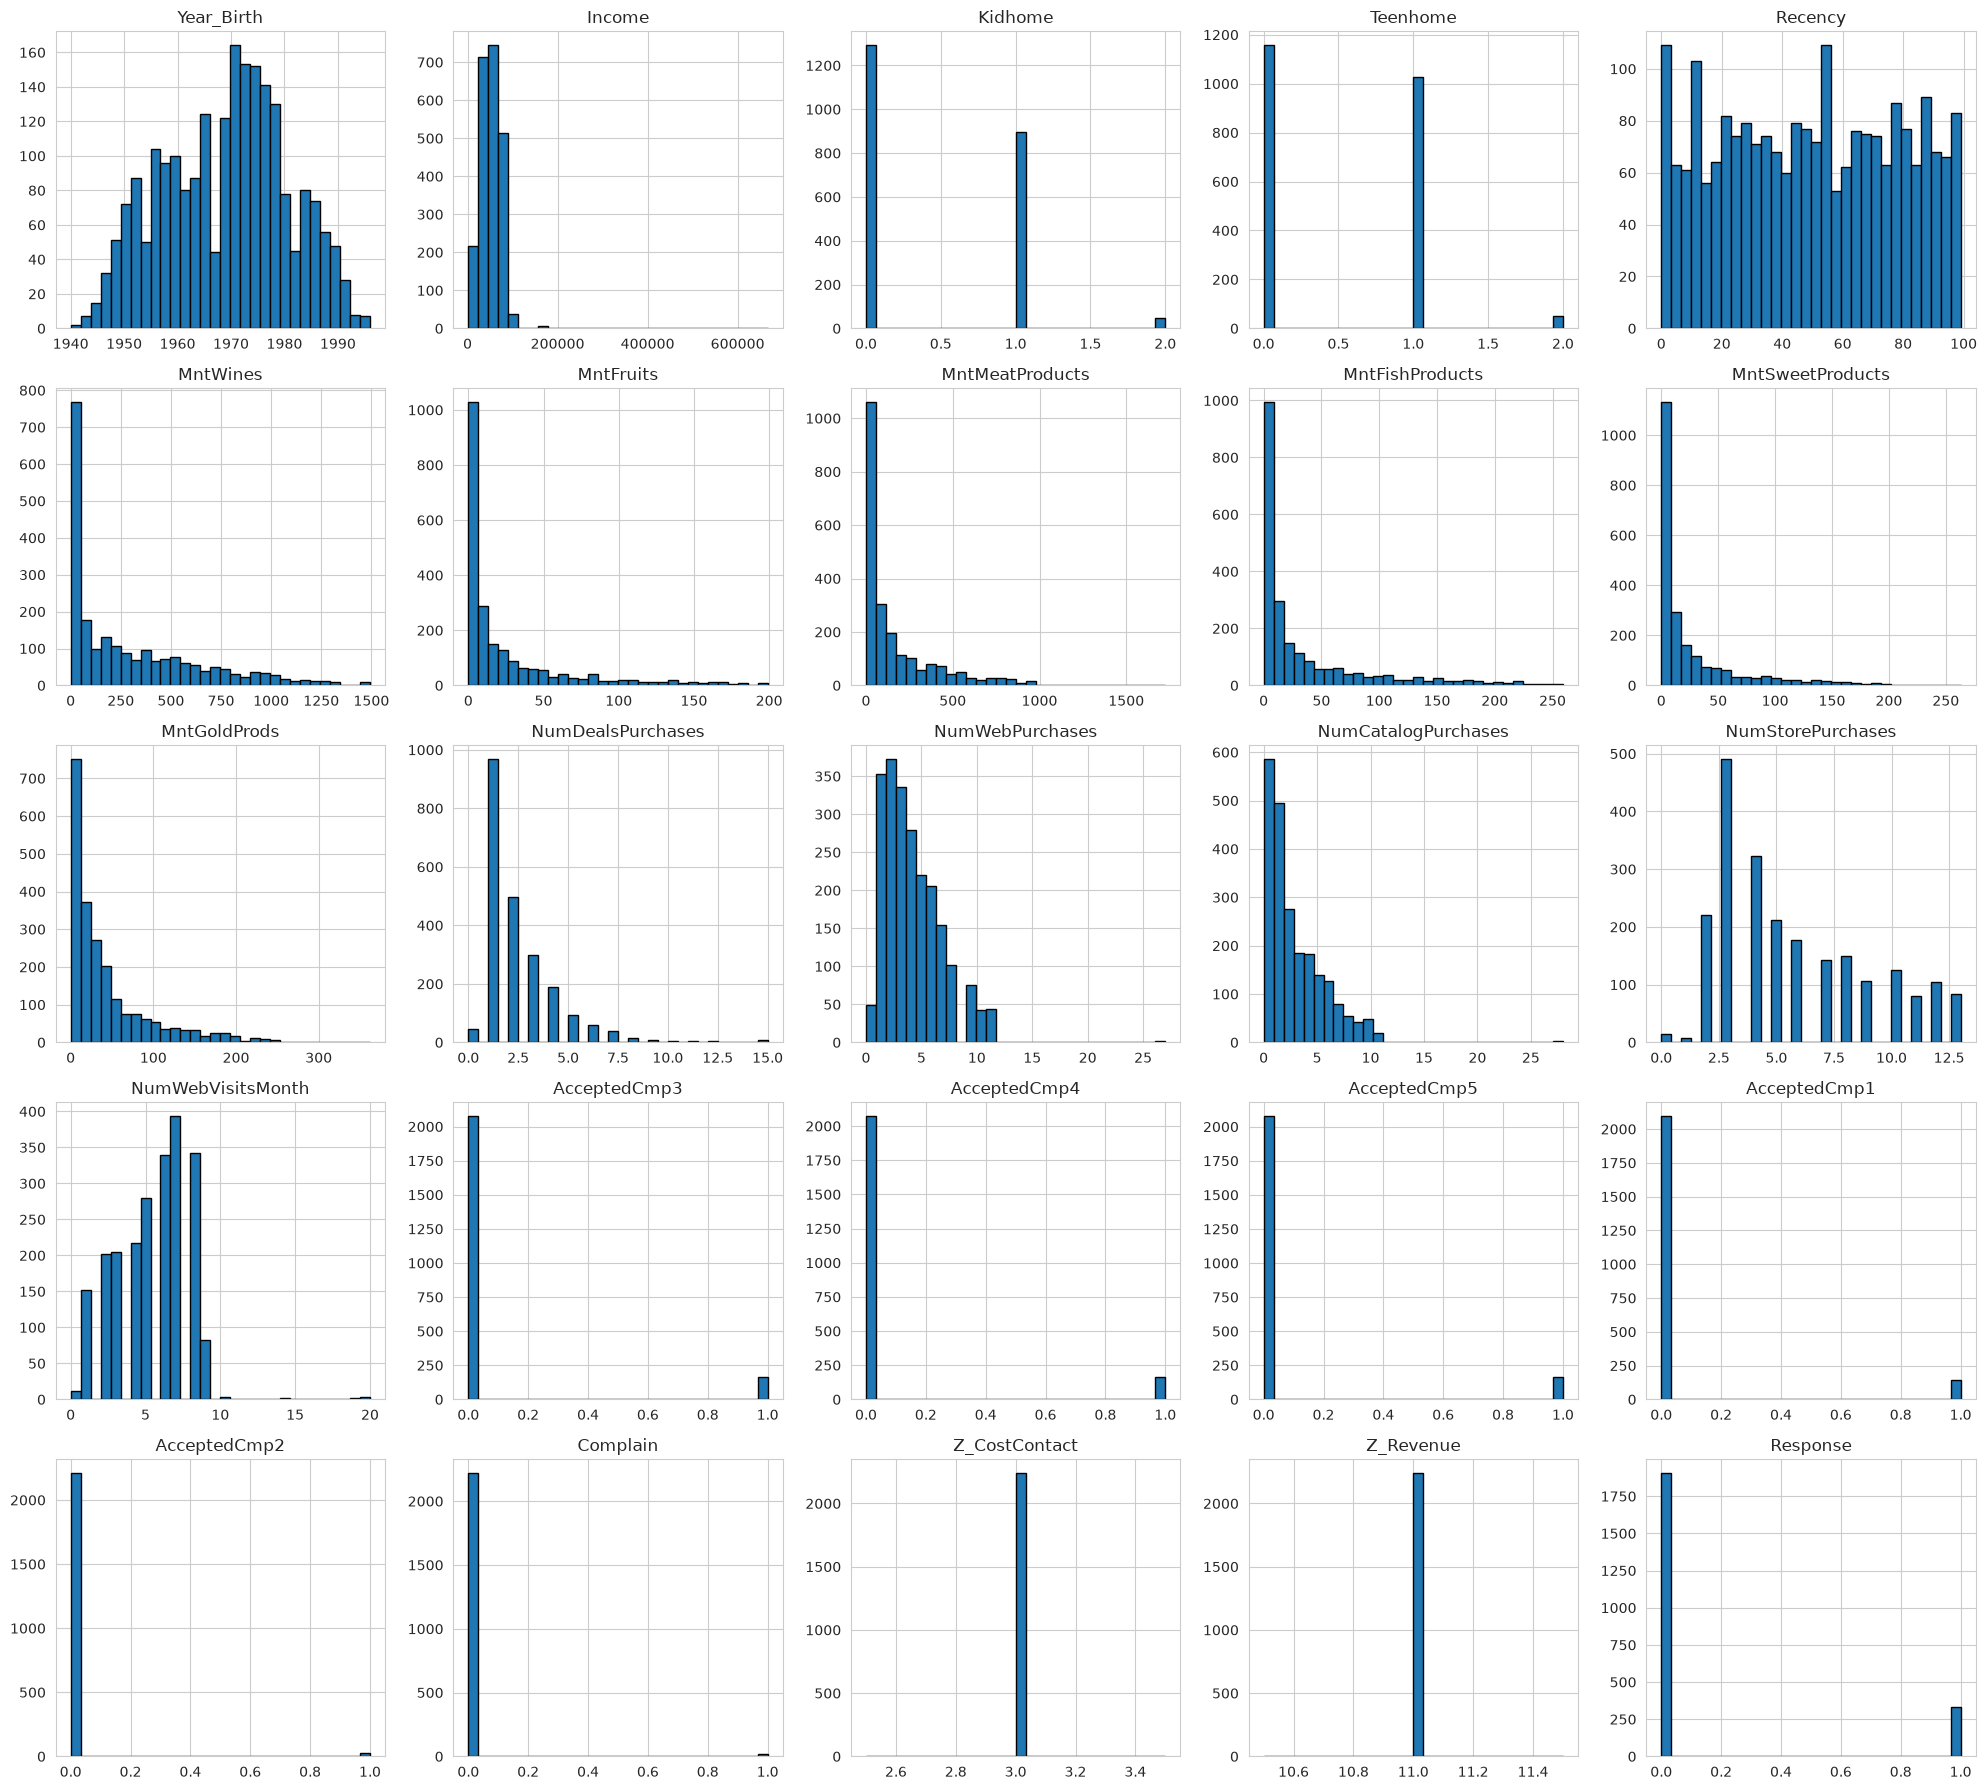

In [112]:
num_cols = [c for c in df.select_dtypes(include='number').columns if c != 'ID']
df[num_cols].hist(bins=30, figsize=(20, 18), edgecolor='black')
plt.tight_layout()
plt.show()

Create bar charts or pie charts for categorical variables to visualize their frequencies.


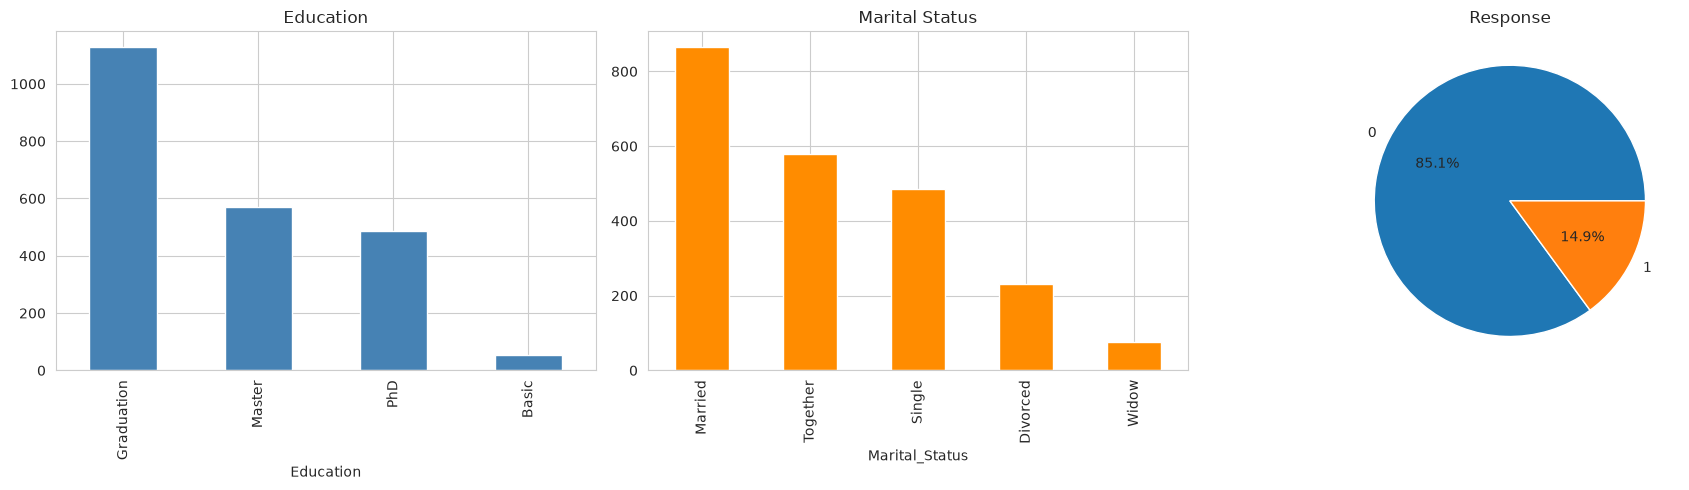

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df['Education'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', title='Education')
df['Marital_Status'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange', title='Marital Status')
df['Response'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%', title='Response')
axes[2].set_ylabel('')
plt.tight_layout()
plt.show()

Compute mean, median, mode, standard deviation, and other summary statistics for numerical variables.


In [114]:
stats = df[num_cols].describe().T
stats['median'] = df[num_cols].median()
stats['mode'] = df[num_cols].mode().iloc[0]
stats['skew'] = df[num_cols].skew()
stats

,count,mean,std,min,25%,50%,75%,max,median,mode,skew
Year_Birth,2237.0,1968.901654,11.701917,1940.0,1959.0,1970.0,1977.0,1996.0,1970.0,1976.0,-0.093266
Income,2237.0,52227.316495,25043.269927,1730.0,35523.0,51373.0,68281.0,666666.0,51373.0,51373.0,6.806244
Kidhome,2237.0,0.444345,0.538467,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.635078
Teenhome,2237.0,0.506482,0.544593,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.406646
Recency,2237.0,49.104604,28.956073,0.0,24.0,49.0,74.0,99.0,49.0,56.0,-0.003416
MntWines,2237.0,303.995530,336.574382,0.0,24.0,174.0,504.0,1493.0,174.0,2.0,1.176567
MntFruits,2237.0,26.270451,39.715972,0.0,1.0,8.0,33.0,199.0,8.0,0.0,2.104978
MntMeatProducts,2237.0,166.916853,225.661158,0.0,16.0,67.0,232.0,1725.0,67.0,7.0,2.085896
MntFishProducts,2237.0,37.523022,54.639909,0.0,3.0,12.0,50.0,259.0,12.0,0.0,1.920677
MntSweetProducts,2237.0,27.068842,41.293949,0.0,1.0,8.0,33.0,263.0,8.0,0.0,2.136315


Calculate the correlation matrix between numerical variables and visualize it using a heatmap.


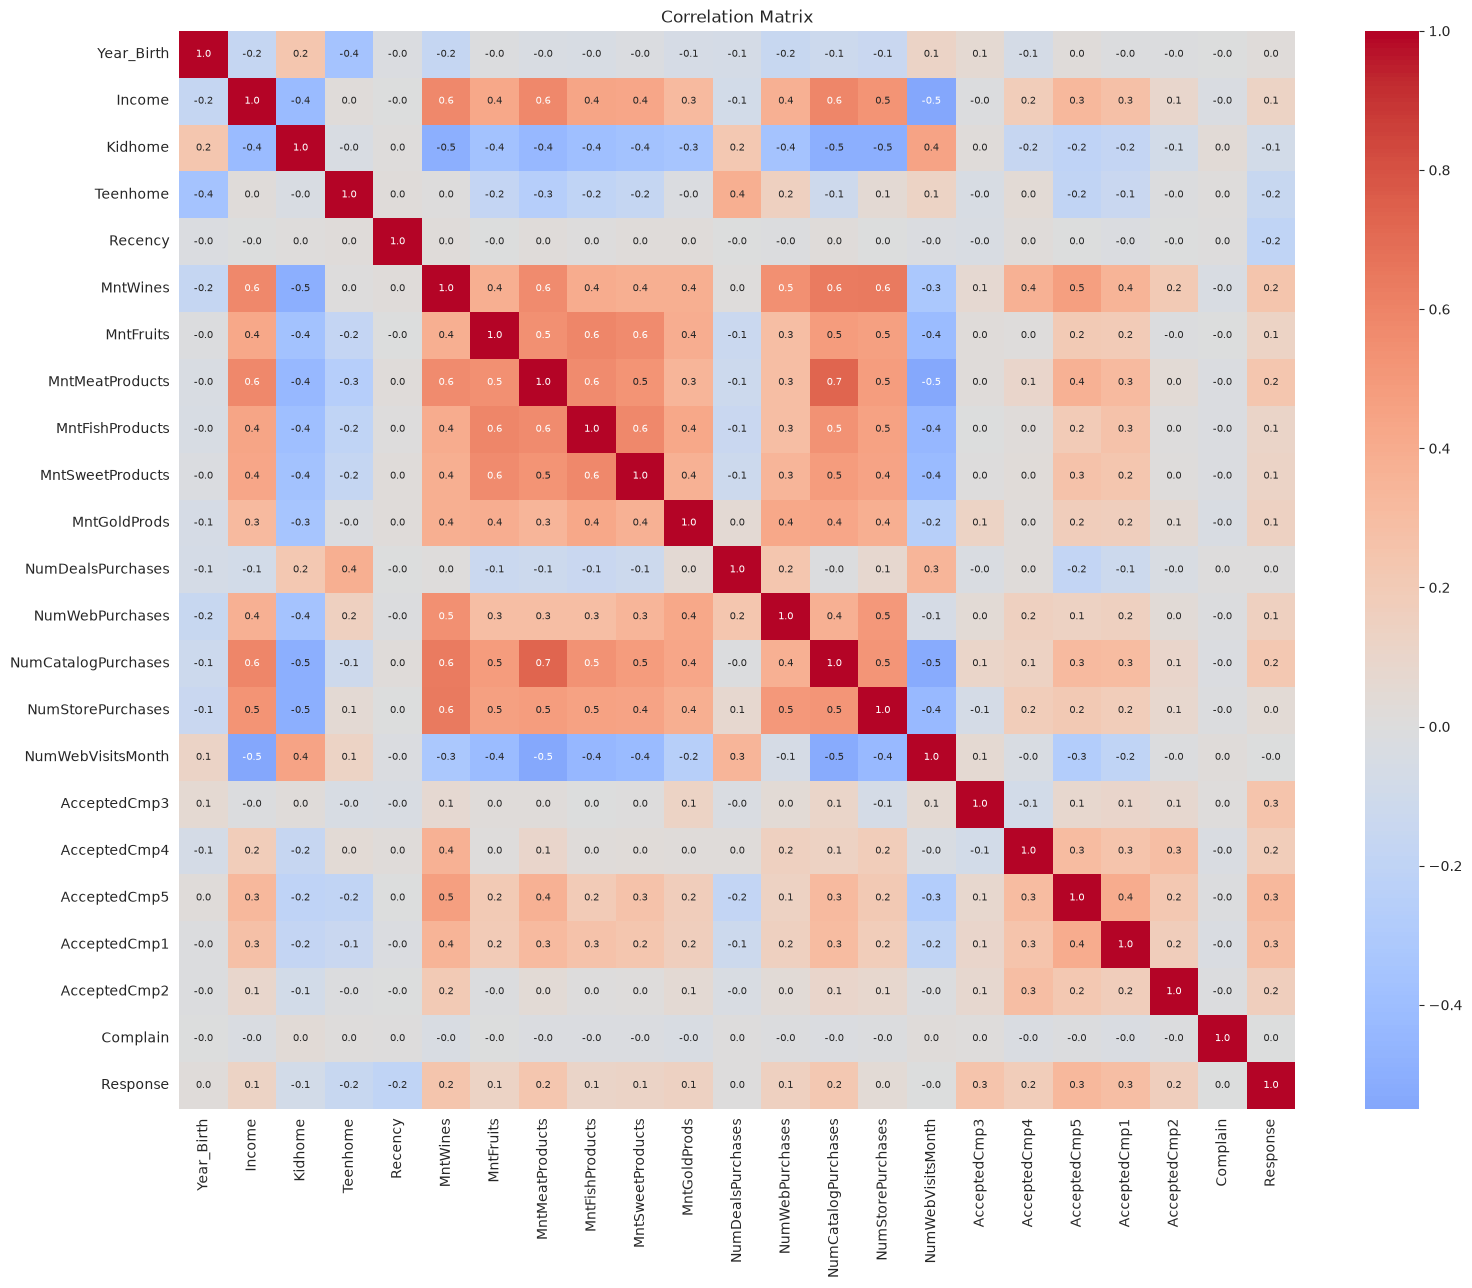

In [115]:
corr_cols = [c for c in num_cols if c not in ['Z_CostContact', 'Z_Revenue']]
plt.figure(figsize=(18, 14))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.1f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Correlation Matrix')
plt.show()

Create 5 different scatter plots to visualize relationships between pairs of numerical variables (e.g., Income vs. MntWines).


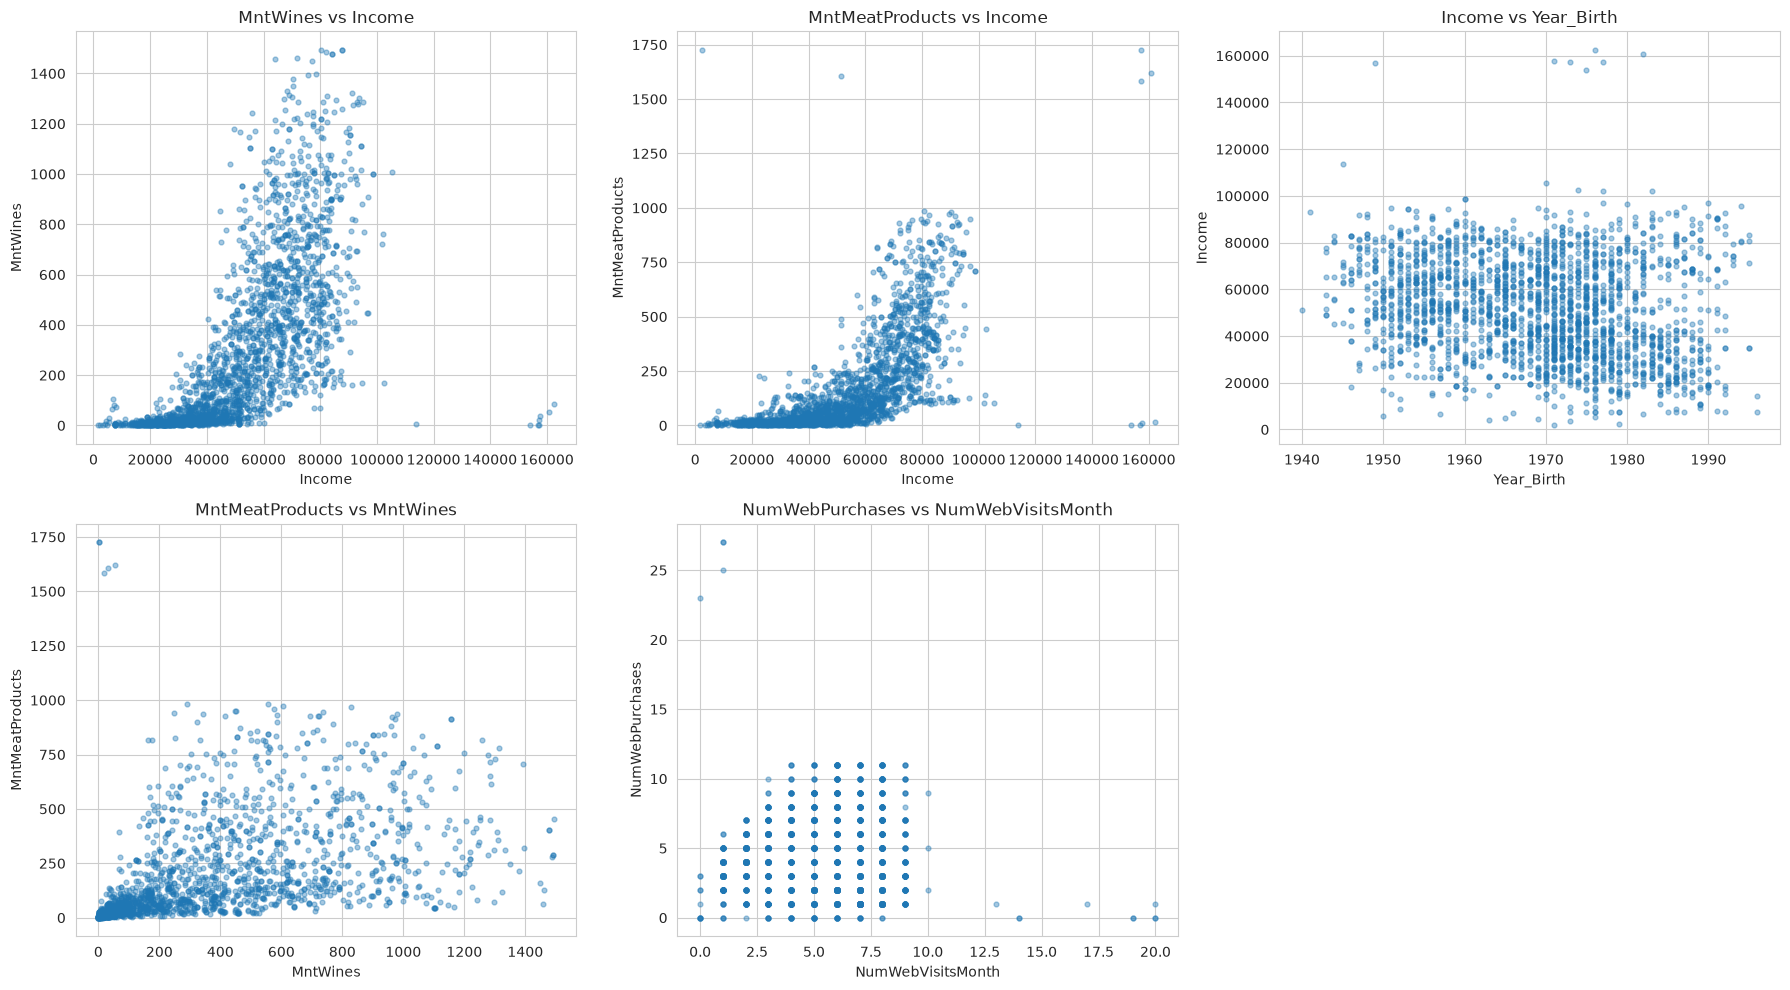

In [116]:
d = df[df['Income'] < 200000]   # drop the extreme income so the plots stay readable
pairs = [('Income', 'MntWines'), ('Income', 'MntMeatProducts'), ('Year_Birth', 'Income'),
         ('MntWines', 'MntMeatProducts'), ('NumWebVisitsMonth', 'NumWebPurchases')]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, (x, y_) in zip(axes, pairs):
    ax.scatter(d[x], d[y_], alpha=0.4, s=12)
    ax.set_xlabel(x)
    ax.set_ylabel(y_)
    ax.set_title(f'{y_} vs {x}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

Create at least 2 box plots to compare distributions of numerical variables across different categories of categorical variables (e.g., MntWines by Education).


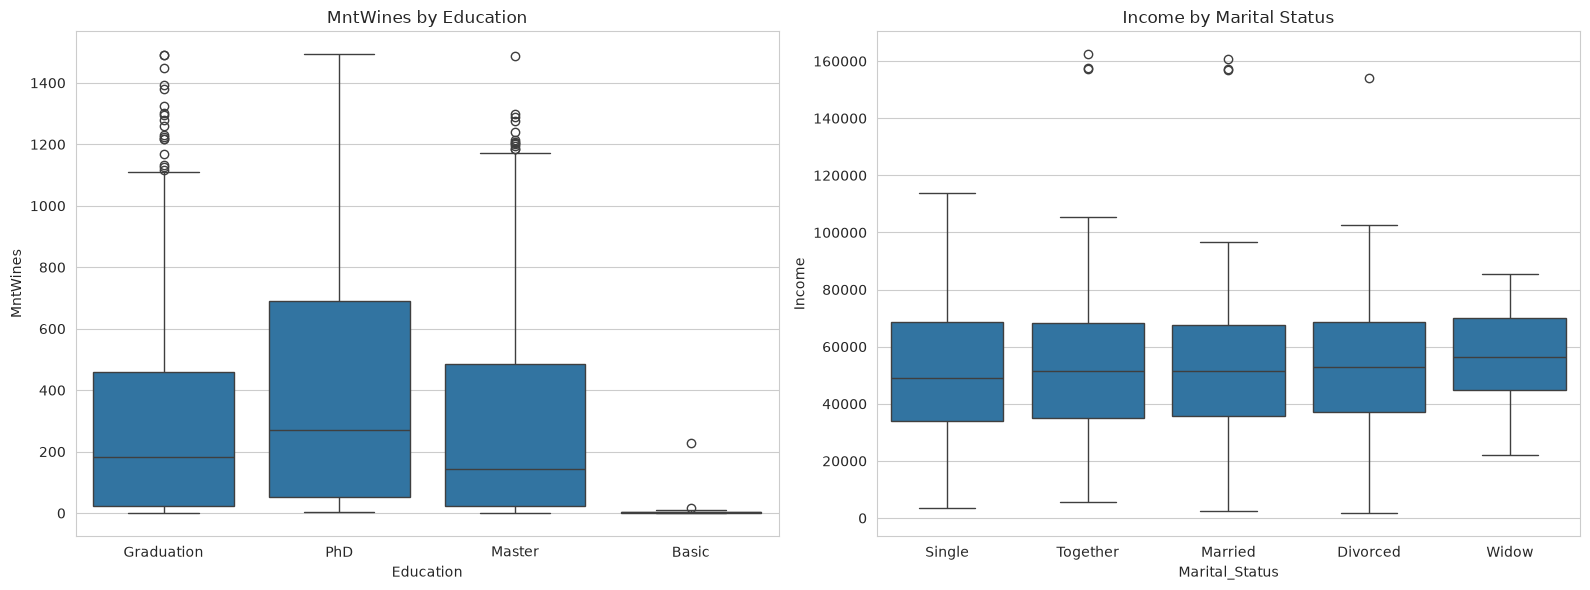

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='Education', y='MntWines', ax=axes[0])
axes[0].set_title('MntWines by Education')
sns.boxplot(data=df[df['Income'] < 200000], x='Marital_Status', y='Income', ax=axes[1])
axes[1].set_title('Income by Marital Status')
plt.tight_layout()
plt.show()

Convert the Dt_Customer column to a datetime format.


In [118]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
print(df['Dt_Customer'].dtype)
print('Enrolment dates:', df['Dt_Customer'].min().date(), 'to', df['Dt_Customer'].max().date())

datetime64[ns]
Enrolment dates: 2012-07-30 to 2014-06-29


Explore 5 different trends over time using line charts (e.g., MntWines by Dt_Customer).


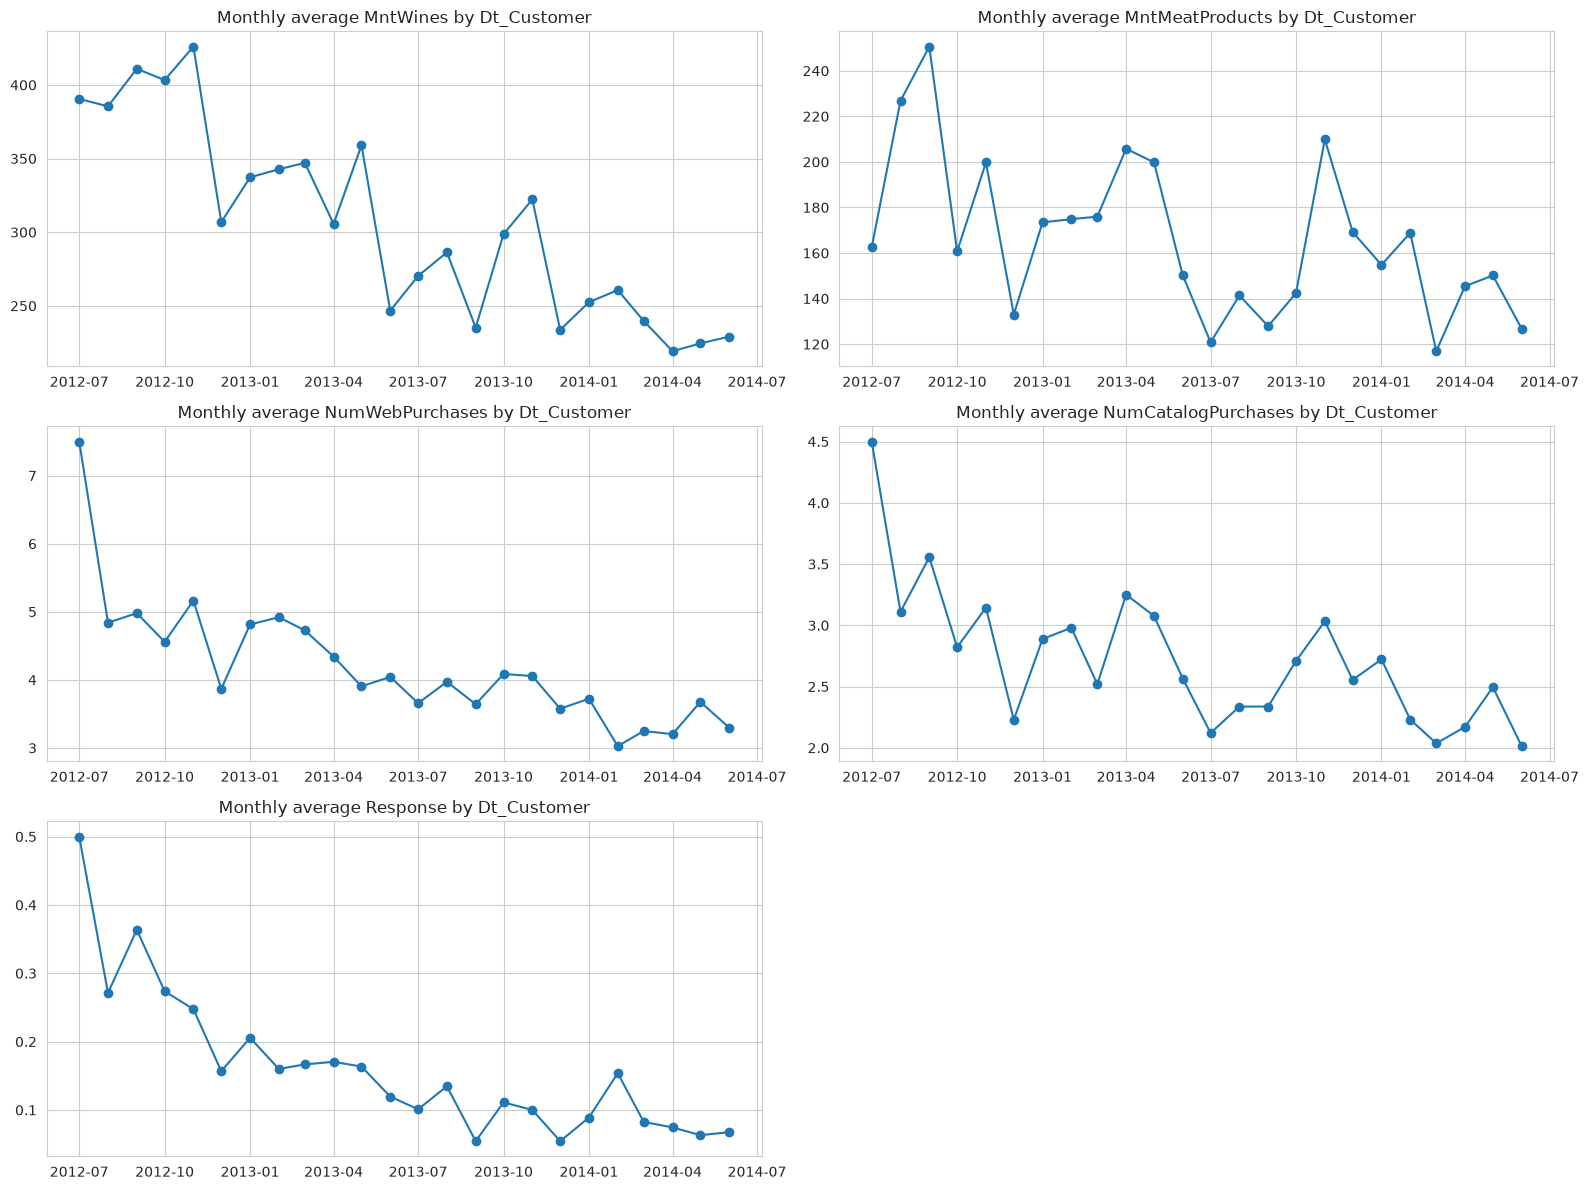

In [119]:
trend_cols = ['MntWines', 'MntMeatProducts', 'NumWebPurchases', 'NumCatalogPurchases', 'Response']
monthly = df.groupby(df['Dt_Customer'].dt.to_period('M'))[trend_cols].mean()
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.ravel()
for ax, c in zip(axes, trend_cols):
    ax.plot(monthly.index, monthly[c], marker='o')
    ax.set_title(f'Monthly average {c} by Dt_Customer')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

Use box plots or scatter plots to identify outliers in numerical variables.


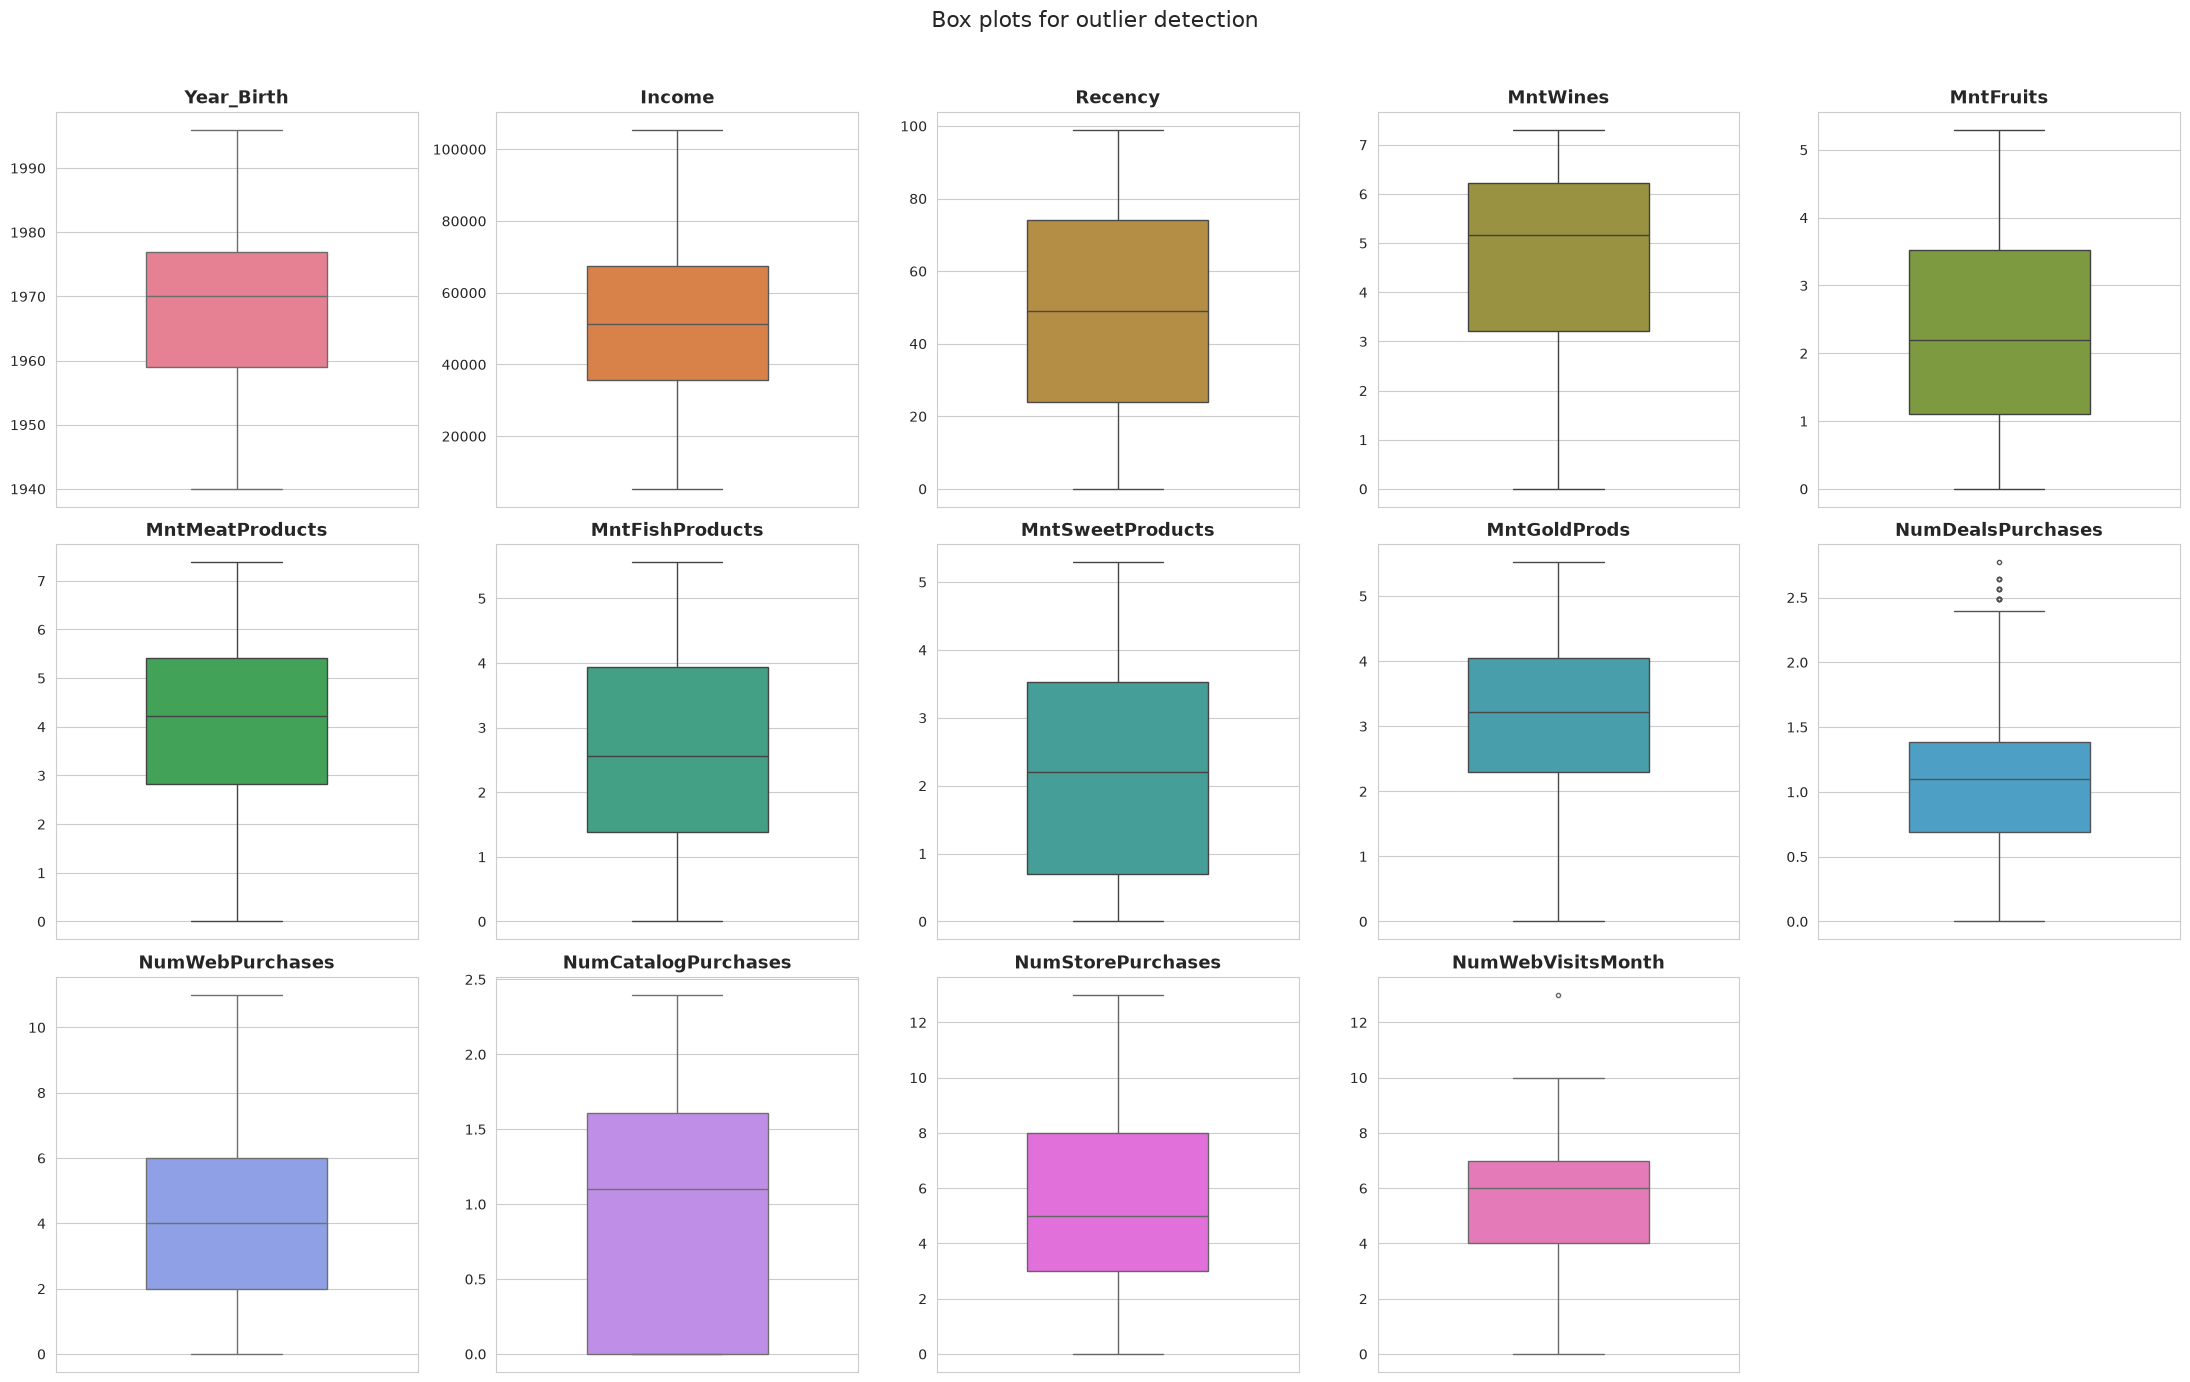

In [213]:
out_cols = ['Year_Birth', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
            'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

n_cols = 5
n_rows = int(np.ceil(len(out_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5 * n_rows))
axes = axes.ravel()
colors = sns.color_palette('husl', len(out_cols))

for ax, c, col in zip(axes, out_cols, colors):
    sns.boxplot(y=df[c], ax=ax, color=col, width=0.5, fliersize=3)
    ax.set_title(c, fontsize=13, fontweight='bold')
    ax.set_ylabel('')                      # title already names the variable

for ax in axes[len(out_cols):]:            # hide unused panels
    ax.axis('off')

plt.suptitle('Box plots for outlier detection', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Remove outliers using suitable methods of your choice

In [121]:
def remove_outliers_iqr(data, cols, k=1.5):
    mask = pd.Series(True, index=data.index)
    for c in cols:
        q1, q3 = data[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        mask &= data[c].between(q1 - k * iqr, q3 + k * iqr)
    return data[mask]

iqr_cols = ['Year_Birth', 'Income', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth']
before = df.shape[0]
df = remove_outliers_iqr(df, iqr_cols).reset_index(drop=True)
print(f'Rows before: {before} | after: {df.shape[0]} | removed: {before - df.shape[0]}')

Rows before: 2237 | after: 2197 | removed: 40


Scale numerical features to a common range using techniques like min-max scaling or standardization.


In [122]:
scale_cols = out_cols
df_scaled = df.copy()
df_scaled[scale_cols] = StandardScaler().fit_transform(df[scale_cols])   # standardization
df_scaled[scale_cols].describe().loc[['mean', 'std']].round(3)

,Year_Birth,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
mean,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Convert categorical variables to numerical representations using techniques like one-hot encoding or label encoding.

In [123]:
df_encoded = pd.get_dummies(df, columns=['Education', 'Marital_Status'], dtype=int)   # one-hot encoding
print(df_encoded.shape)
df_encoded.head()

(2197, 36)


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Response,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,1,0,1,0,0,0,0,1,0,0
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,0,0,1,0,0,0,0,1,0,0
2,4141,1965,71613.0,0,0,2013-08-21,26,426,49,127,...,0,0,1,0,0,0,0,0,1,0
3,6182,1984,26646.0,1,0,2014-02-10,26,11,4,20,...,0,0,1,0,0,0,0,0,1,0
4,5324,1981,58293.0,1,0,2014-01-19,94,173,43,118,...,0,0,0,0,1,0,1,0,0,0


Group the data by categorical variables (e.g., Marital_Status) and calculate summary statistics for each group.


In [124]:
summary_cols = {'Customers': ('ID', 'count'), 'Avg_Income': ('Income', 'mean'),
                'Median_Income': ('Income', 'median'), 'Avg_MntWines': ('MntWines', 'mean'),
                'Avg_MntMeat': ('MntMeatProducts', 'mean'), 'Avg_Recency': ('Recency', 'mean'),
                'Response_Rate': ('Response', 'mean')}
for col in ['Marital_Status', 'Education']:
    display(df.groupby(col).agg(**summary_cols).round(2))

,Customers,Avg_Income,Median_Income,Avg_MntWines,Avg_MntMeat,Avg_Recency,Response_Rate
Marital_Status,,,,,,,
Divorced,227,52911.50,53367.0,330.22,153.04,49.28,0.21
Married,851,51287.37,51373.0,298.78,153.12,48.25,0.11
Single,475,50943.25,48918.0,290.78,179.38,49.15,0.23
Together,569,51527.95,51369.0,304.69,163.67,50.24,0.10
Widow,75,55789.67,54356.0,359.72,179.73,49.33,0.24


,Customers,Avg_Income,Median_Income,Avg_MntWines,Avg_MntMeat,Avg_Recency,Response_Rate
Education,,,,,,,
Basic,54,20306.26,20744.0,7.24,11.44,48.44,0.04
Graduation,1104,51898.71,51373.0,283.30,173.59,50.13,0.13
Master,566,50828.67,49681.0,285.27,154.50,47.93,0.14
PhD,473,55383.47,54880.0,408.19,163.11,48.18,0.21


Explore the distribution of Year_Birth, Education, and Marital_Status.


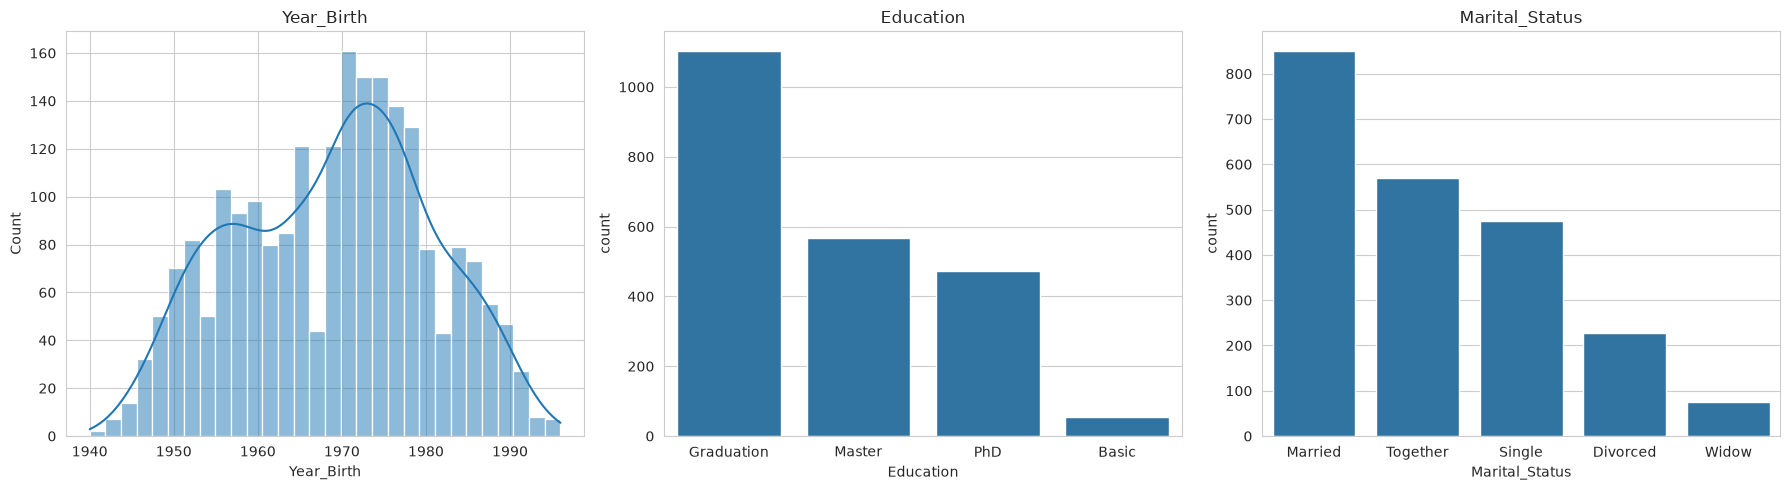

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Year_Birth'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Year_Birth')
sns.countplot(data=df, x='Education', ax=axes[1], order=df['Education'].value_counts().index)
axes[1].set_title('Education')
sns.countplot(data=df, x='Marital_Status', ax=axes[2], order=df['Marital_Status'].value_counts().index)
axes[2].set_title('Marital_Status')
plt.tight_layout()
plt.show()

Analyze the relationship between demographics and purchase behavior.


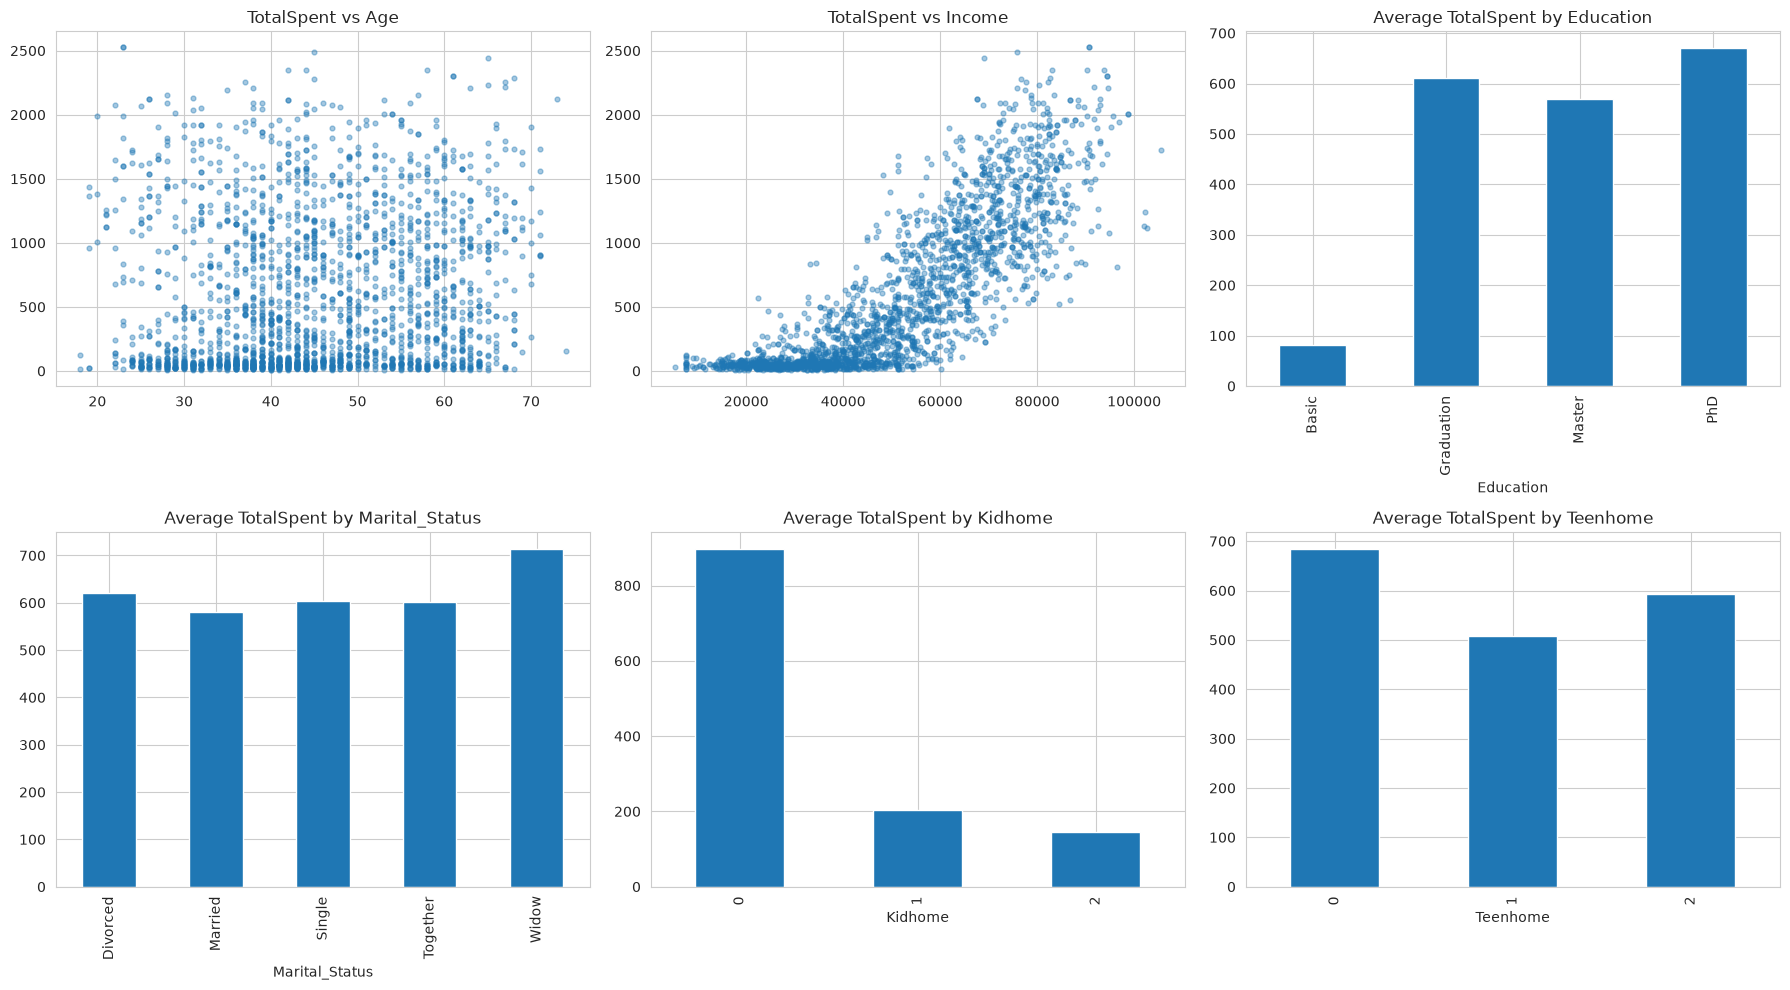

Age           0.118
Income        0.828
Kidhome      -0.559
Teenhome     -0.133
TotalSpent    1.000
Name: TotalSpent, dtype: float64


In [126]:
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
demo = df.copy()
demo['Age'] = 2014 - demo['Year_Birth']     # 2014 is the latest enrolment year in the data
demo['TotalSpent'] = demo[mnt_cols].sum(axis=1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].scatter(demo['Age'], demo['TotalSpent'], alpha=0.4, s=12)
axes[0, 0].set_title('TotalSpent vs Age')
axes[0, 1].scatter(demo['Income'], demo['TotalSpent'], alpha=0.4, s=12)
axes[0, 1].set_title('TotalSpent vs Income')
for ax, col in zip([axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]],
                   ['Education', 'Marital_Status', 'Kidhome', 'Teenhome']):
    demo.groupby(col)['TotalSpent'].mean().plot(kind='bar', ax=ax)
    ax.set_title(f'Average TotalSpent by {col}')
plt.tight_layout()
plt.show()
print(demo[['Age', 'Income', 'Kidhome', 'Teenhome', 'TotalSpent']].corr()['TotalSpent'].round(3))

Compare the purchase amounts of each and every product categories in this dataset (e.g., MntWines, MntFruits).


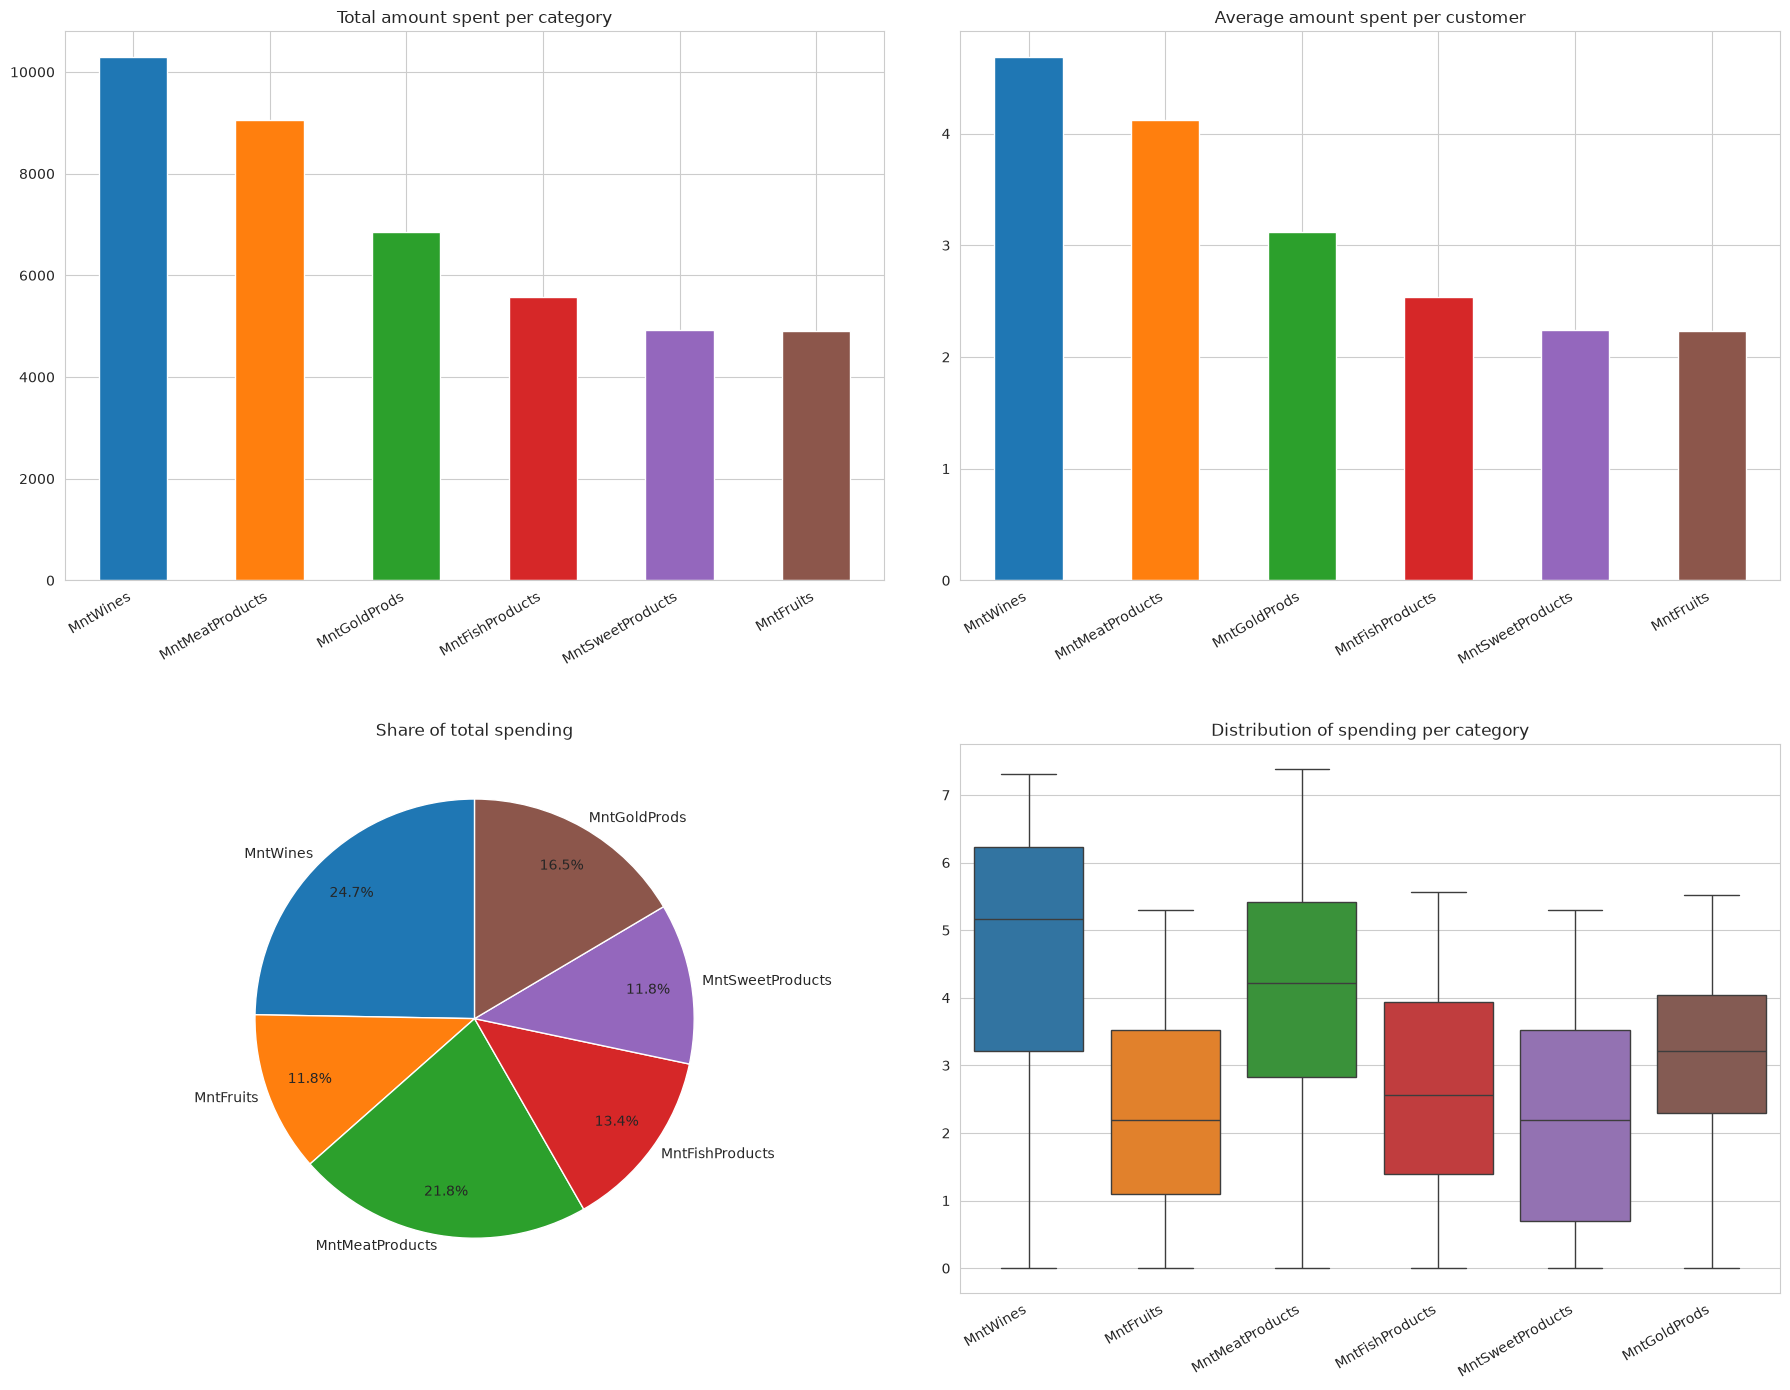

In [214]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

df[mnt_cols].sum().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0, 0], color=sns.color_palette('tab10', len(mnt_cols)))
axes[0, 0].set_title('Total amount spent per category')

df[mnt_cols].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0, 1], color=sns.color_palette('tab10', len(mnt_cols)))
axes[0, 1].set_title('Average amount spent per customer')

df[mnt_cols].sum().plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%',
                        startangle=90, pctdistance=0.8, labeldistance=1.05)
axes[1, 0].set_title('Share of total spending')
axes[1, 0].set_ylabel('')

sns.boxplot(data=df[mnt_cols], ax=axes[1, 1])
axes[1, 1].set_title('Distribution of spending per category')

for ax in [axes[0, 0], axes[0, 1], axes[1, 1]]:
    ax.tick_params(axis='x', rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout(h_pad=4, w_pad=3)
plt.show()

Analyze the relationship between purchase frequency and purchase amounts.


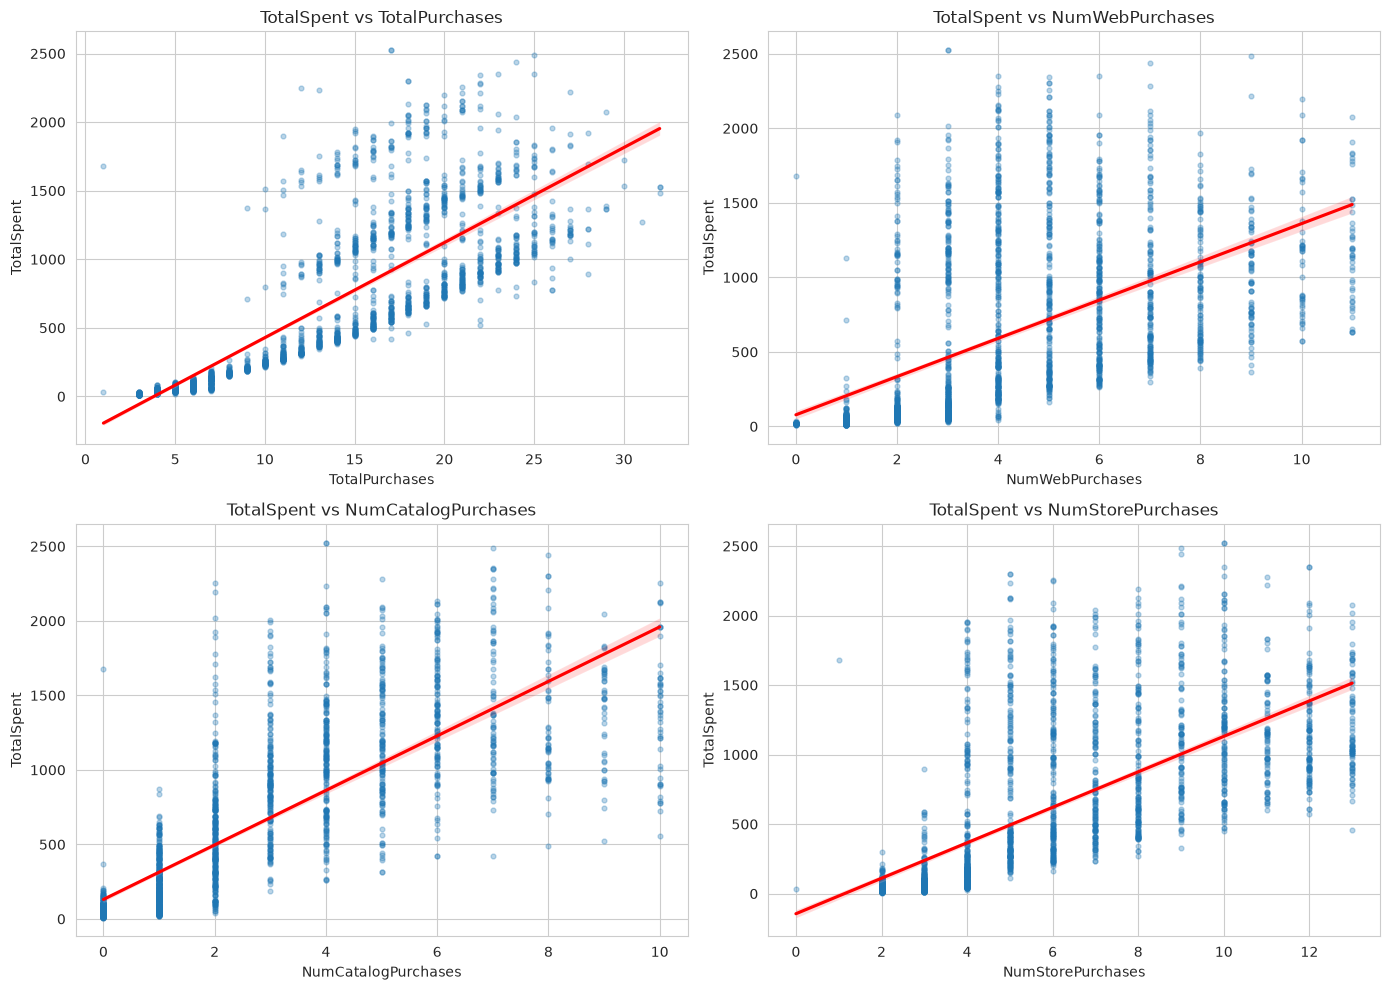

NumWebPurchases        0.562
NumCatalogPurchases    0.809
NumStorePurchases      0.689
TotalPurchases         0.822
TotalSpent             1.000
Name: TotalSpent, dtype: float64


In [128]:
freq = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].copy()
freq['TotalPurchases'] = freq.sum(axis=1)
freq['TotalSpent'] = df[mnt_cols].sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), ['TotalPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']):
    sns.regplot(data=freq, x=col, y='TotalSpent', ax=ax, scatter_kws={'alpha': 0.3, 's': 12}, line_kws={'color': 'red'})
    ax.set_title(f'TotalSpent vs {col}')
plt.tight_layout()
plt.show()
print(freq.corr()['TotalSpent'].round(3))

Analyze the acceptance rates of different campaigns in this dataset (AcceptedCmp1, AcceptedCmp2, etc.).


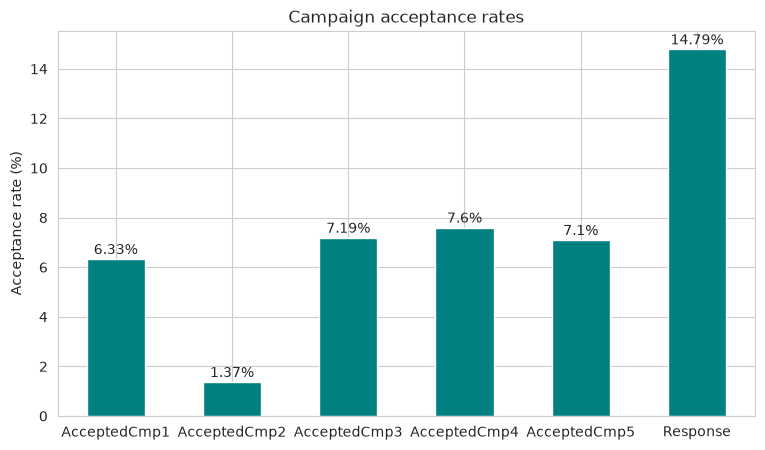

In [129]:
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
rates = (df[cmp_cols].mean() * 100).round(2)
ax = rates.plot(kind='bar', figsize=(9, 5), color='teal')
for i, v in enumerate(rates):
    ax.text(i, v + 0.2, f'{v}%', ha='center')
ax.set_ylabel('Acceptance rate (%)')
ax.set_title('Campaign acceptance rates')
plt.xticks(rotation=0)
plt.show()

Explore the relationship between campaign acceptance and customer demographics or purchase behavior.


Response,0,1
Age,45.16,44.55
Income,50213.46,59564.72
Kidhome,0.47,0.35
Teenhome,0.54,0.31
Recency,51.52,35.17
TotalSpent,536.43,967.42
TotalPurchases,12.01,15.16
NumWebVisitsMonth,5.32,5.36


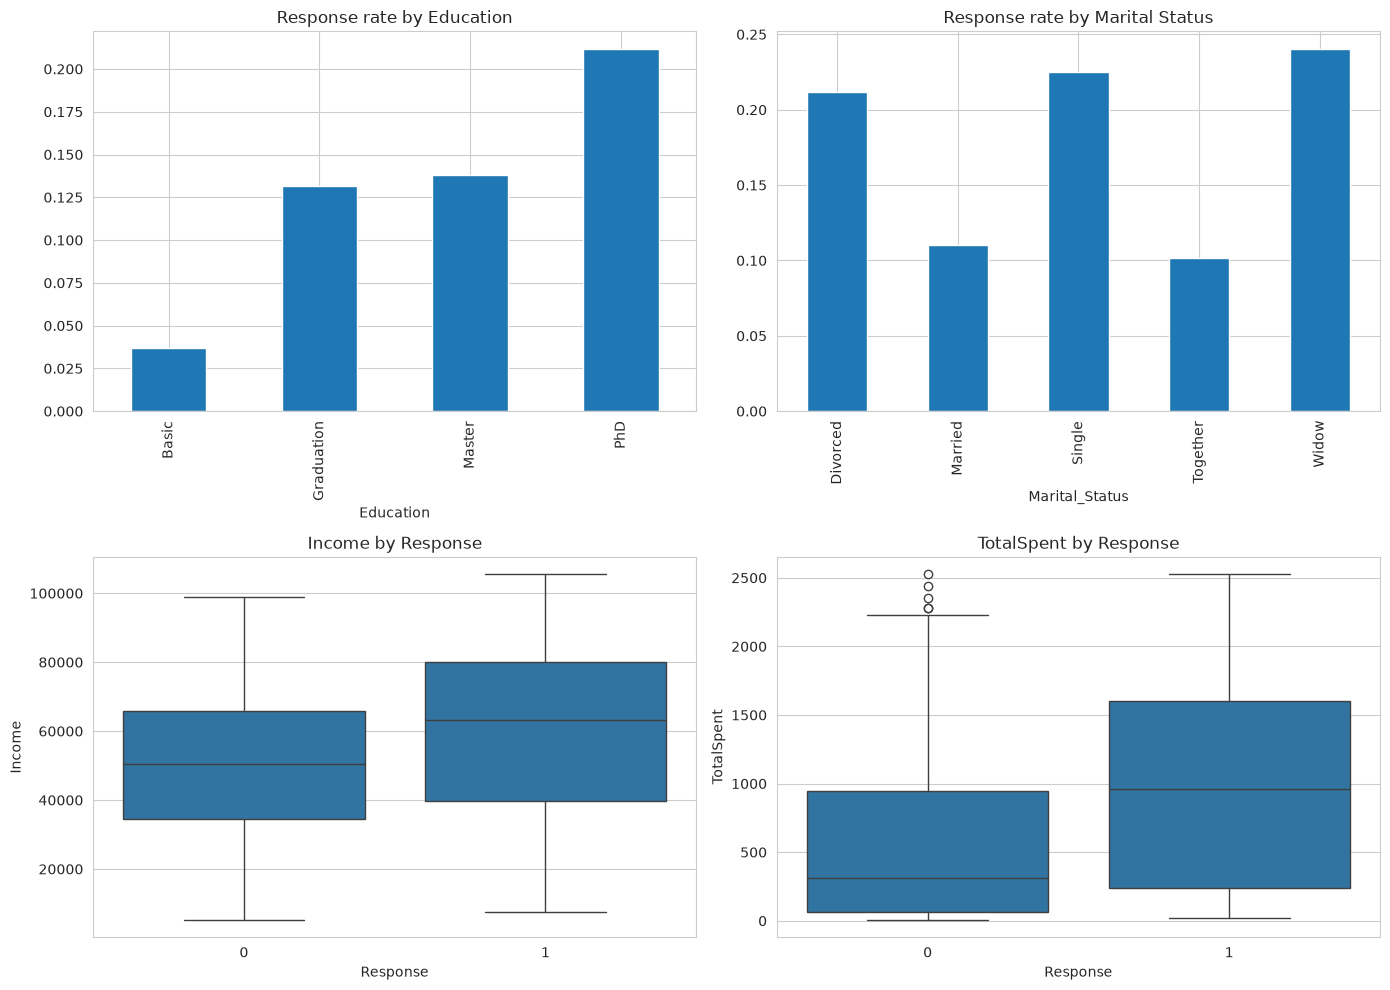

In [130]:
camp = df.copy()
camp['Age'] = 2014 - camp['Year_Birth']
camp['TotalSpent'] = camp[mnt_cols].sum(axis=1)
camp['TotalPurchases'] = camp[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)

display(camp.groupby('Response')[['Age', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'TotalSpent',
                                   'TotalPurchases', 'NumWebVisitsMonth']].mean().T.round(2))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
camp.groupby('Education')['Response'].mean().plot(kind='bar', ax=axes[0, 0], title='Response rate by Education')
camp.groupby('Marital_Status')['Response'].mean().plot(kind='bar', ax=axes[0, 1], title='Response rate by Marital Status')
sns.boxplot(data=camp, x='Response', y='Income', ax=axes[1, 0])
axes[1, 0].set_title('Income by Response')
sns.boxplot(data=camp, x='Response', y='TotalSpent', ax=axes[1, 1])
axes[1, 1].set_title('TotalSpent by Response')
plt.tight_layout()
plt.show()

Analyze the relationship between Recency and purchase behavior.


Recency             1.000
MntWines            0.015
MntFruits          -0.002
MntMeatProducts     0.024
MntFishProducts     0.004
MntSweetProducts    0.034
MntGoldProds        0.021
TotalPurchases      0.010
TotalSpent          0.021
Name: Recency, dtype: float64


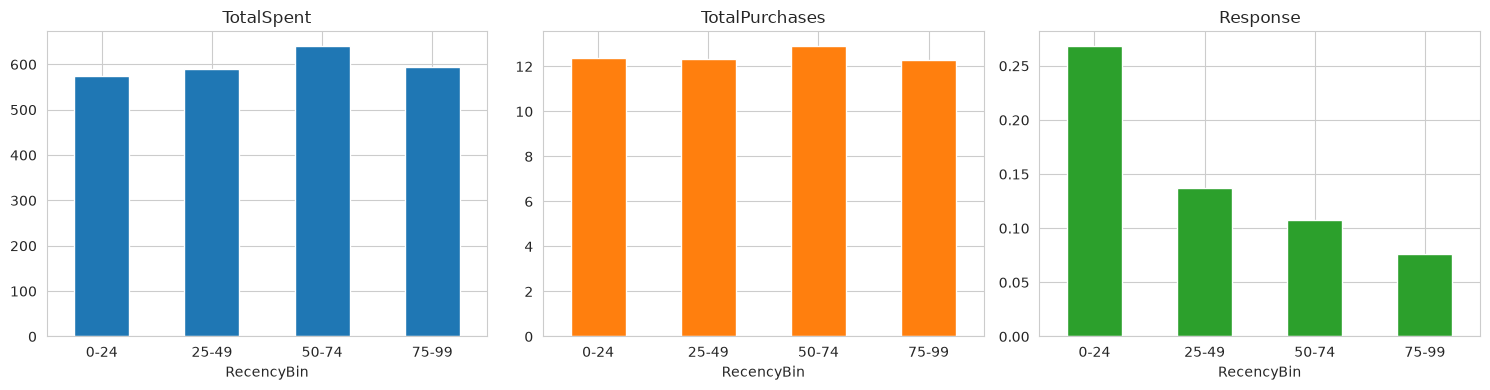

In [131]:
rec = df.copy()
rec['TotalSpent'] = rec[mnt_cols].sum(axis=1)
rec['TotalPurchases'] = rec[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
print(rec[['Recency'] + mnt_cols + ['TotalPurchases', 'TotalSpent']].corr()['Recency'].round(3))

rec['RecencyBin'] = pd.cut(rec['Recency'], bins=[-1, 24, 49, 74, 99], labels=['0-24', '25-49', '50-74', '75-99'])
rec.groupby('RecencyBin', observed=True)[['TotalSpent', 'TotalPurchases', 'Response']].mean().plot(
    kind='bar', subplots=True, layout=(1, 3), figsize=(15, 4), legend=False, rot=0)
plt.tight_layout()
plt.show()

Identify frequent customers and their characteristics.


In [132]:
cust = df.copy()
cust['Age'] = 2014 - cust['Year_Birth']
cust['TotalSpent'] = cust[mnt_cols].sum(axis=1)
cust['TotalPurchases'] = cust[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)

threshold = cust['TotalPurchases'].quantile(0.75)      # top 25% by number of purchases
cust['CustomerType'] = np.where(cust['TotalPurchases'] >= threshold, 'Frequent', 'Others')
print('Threshold (total purchases):', threshold)
print(cust['CustomerType'].value_counts(), '\n')
display(cust.groupby('CustomerType')[['Age', 'Income', 'Kidhome', 'Teenhome', 'TotalSpent',
                                       'NumDealsPurchases', 'NumWebVisitsMonth', 'Recency', 'Response']].mean().T.round(2))
display(pd.crosstab(cust['CustomerType'], cust['Education'], normalize='index').round(3))
display(pd.crosstab(cust['CustomerType'], cust['Marital_Status'], normalize='index').round(3))

Threshold (total purchases): 18.0
CustomerType
Others      1563
Frequent     634
Name: count, dtype: int64 



CustomerType,Frequent,Others
Age,46.88,44.33
Income,70086.21,44096.91
Kidhome,0.10,0.59
Teenhome,0.49,0.52
TotalSpent,1229.45,344.94
NumDealsPurchases,2.30,2.32
NumWebVisitsMonth,4.17,5.79
Recency,49.71,48.85
Response,0.21,0.12


Education,Basic,Graduation,Master,PhD
CustomerType,,,,
Frequent,0.002,0.506,0.244,0.248
Others,0.034,0.501,0.263,0.202


Marital_Status,Divorced,Married,Single,Together,Widow
CustomerType,,,,,
Frequent,0.112,0.379,0.202,0.267,0.041
Others,0.100,0.391,0.222,0.256,0.031


Analyze the relationship between Complain and customer satisfaction or purchase behavior.


Complain
0    2177
1      20
Name: count, dtype: int64 



,TotalSpent,TotalPurchases,NumDealsPurchases,NumWebVisitsMonth,Recency,Response
Complain,,,,,,
0,602.1,12.49,2.31,5.32,49.09,0.15
1,392.0,11.20,2.40,5.85,50.75,0.15


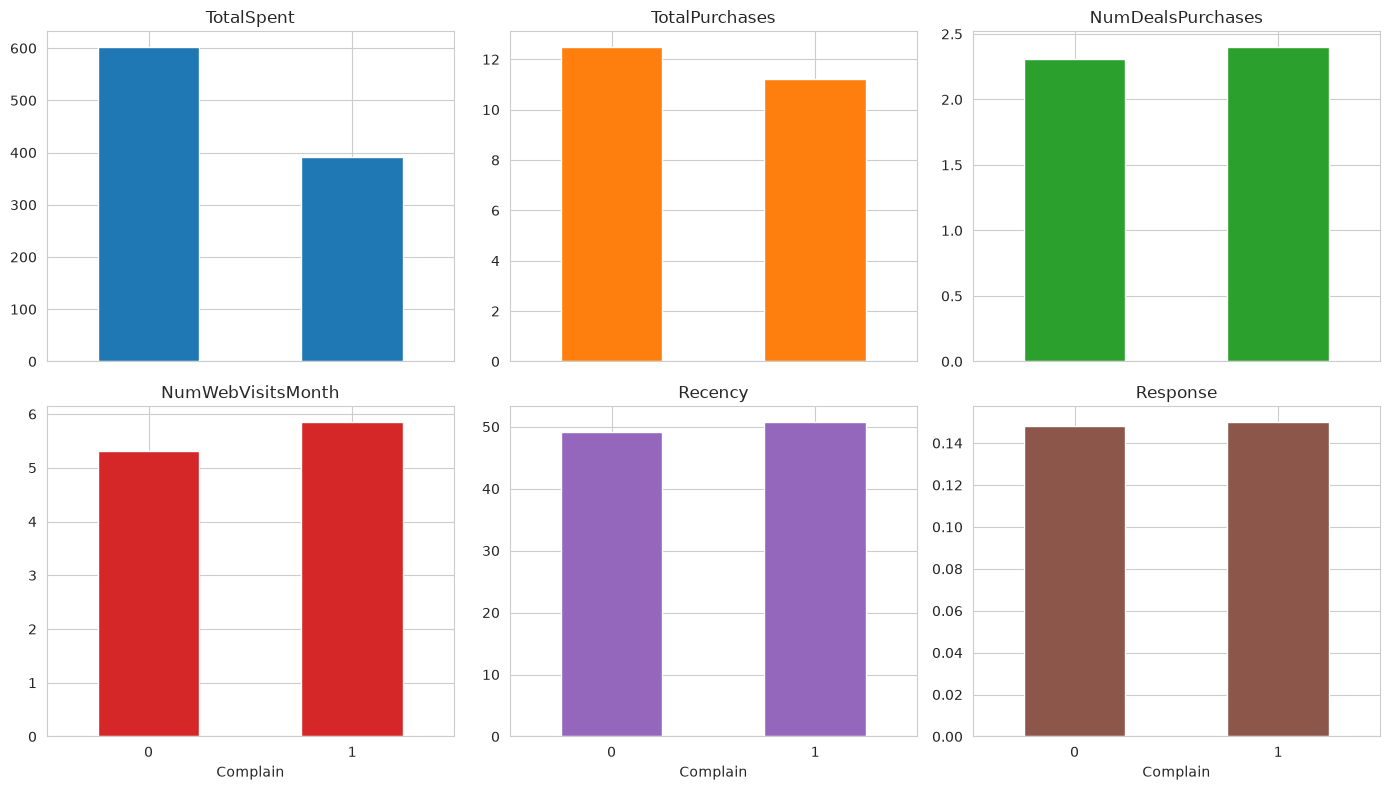

In [133]:
print(df['Complain'].value_counts(), '\n')
comp = df.copy()
comp['TotalSpent'] = comp[mnt_cols].sum(axis=1)
comp['TotalPurchases'] = comp[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
# The data has no satisfaction score, so spending, recency and campaign response act as proxies
comp_summary = comp.groupby('Complain')[['TotalSpent', 'TotalPurchases', 'NumDealsPurchases',
                                         'NumWebVisitsMonth', 'Recency', 'Response']].mean()
display(comp_summary.round(2))
comp_summary.plot(kind='bar', subplots=True, layout=(2, 3), figsize=(14, 8), legend=False, rot=0)
plt.tight_layout()
plt.show()

Analyze the relationship between Z_Revenue and Z_CostContact.

Z_CostContact    1
Z_Revenue        1
dtype: int64

Unique pairs:
    Z_CostContact  Z_Revenue
0              3         11

Revenue / Cost ratio: 3.667
Correlation: nan (undefined - both columns are constant)


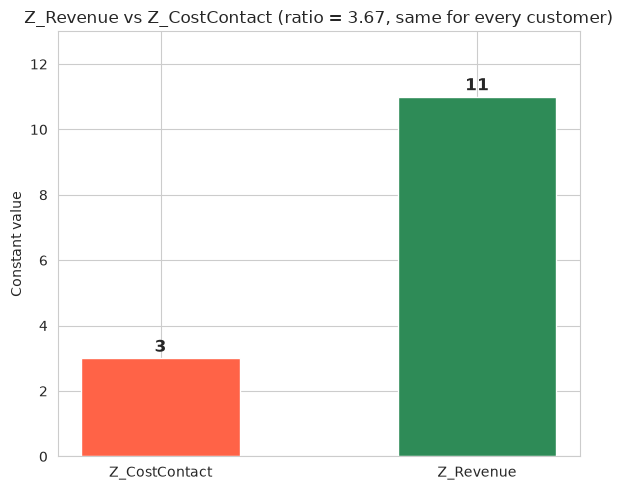

In [215]:
print(df[['Z_CostContact', 'Z_Revenue']].nunique())
print('\nUnique pairs:\n', df[['Z_CostContact', 'Z_Revenue']].drop_duplicates())
print('\nRevenue / Cost ratio:', round(df['Z_Revenue'].iloc[0] / df['Z_CostContact'].iloc[0], 3))
print('Correlation:', df['Z_Revenue'].corr(df['Z_CostContact']), '(undefined - both columns are constant)')

# Both columns hold a single constant value, so a bar chart shows them better than a scatter plot
values = [df['Z_CostContact'].iloc[0], df['Z_Revenue'].iloc[0]]
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Z_CostContact', 'Z_Revenue'], values, color=['tomato', 'seagreen'], width=0.5)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.2, str(v), ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(values) + 2)
ax.set_ylabel('Constant value')
ax.set_title(f'Z_Revenue vs Z_CostContact (ratio = {values[1] / values[0]:.2f}, same for every customer)')
plt.tight_layout()
plt.show()

Use clustering techniques ( K-means, hierarchical clustering) to identify distinct customer segments based on their characteristics and purchase behavior.


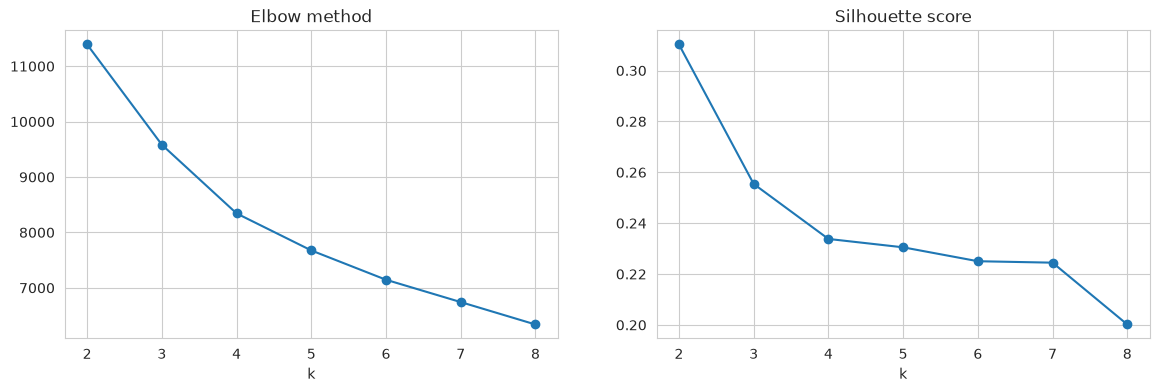

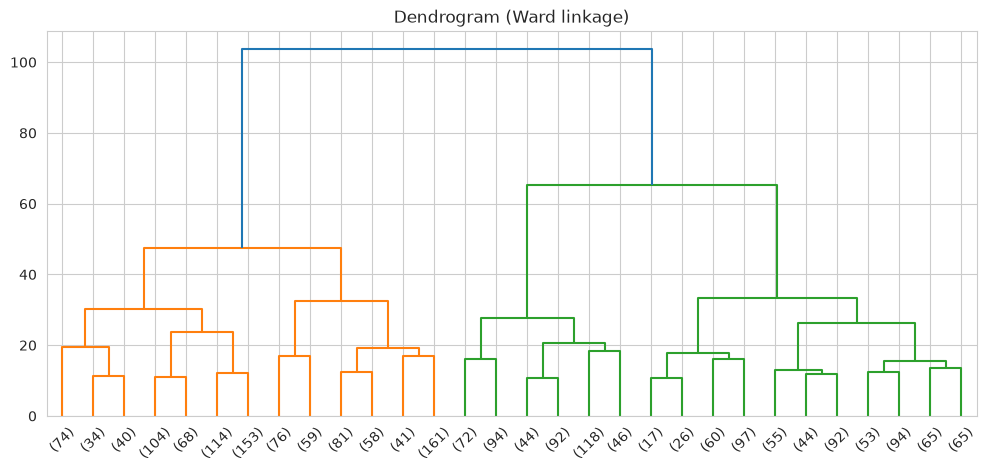

Cluster_KMeans
0    622
1    600
2    498
3    477
Name: count, dtype: int64


,Age,Income,TotalSpent,TotalPurchases,Recency,Kidhome,Teenhome,NumWebVisitsMonth
Cluster_KMeans,,,,,,,,
0,51.0,60369.5,785.9,17.4,49.6,0.1,1.0,5.3
1,36.1,30393.2,124.2,6.4,49.0,0.8,0.0,6.8
2,44.5,75956.6,1387.8,19.1,49.0,0.1,0.0,2.7
3,49.2,41396.2,134.4,6.7,48.6,0.9,1.0,6.2


,Age,Income,TotalSpent,TotalPurchases,Recency,Kidhome,Teenhome,NumWebVisitsMonth
Cluster_Hier,,,,,,,,
0,50.1,57795.4,692.9,15.6,49.3,0.0,1.1,5.2
1,46.7,45463.0,287.7,9.2,48.1,1.1,0.8,6.4
2,45.8,75740.4,1393.3,19.1,49.4,0.0,0.0,2.6
3,37.4,30349.9,118.4,6.3,49.5,0.7,0.0,6.7


In [135]:
seg = df.copy()
seg['Age'] = 2014 - seg['Year_Birth']
seg['TotalSpent'] = seg[mnt_cols].sum(axis=1)
seg['TotalPurchases'] = seg[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
cluster_feats = ['Age', 'Income', 'TotalSpent', 'TotalPurchases', 'Recency', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth']
X_seg = StandardScaler().fit_transform(seg[cluster_feats])

# Elbow method and silhouette score to choose k
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_seg)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_seg, km.labels_))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ks, inertia, marker='o')
axes[0].set_title('Elbow method')
axes[0].set_xlabel('k')
axes[1].plot(ks, sil, marker='o')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
plt.show()

n_clusters = 4   # chosen from the elbow plot; gives clearly interpretable segments
seg['Cluster_KMeans'] = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit_predict(X_seg)

# Hierarchical clustering
plt.figure(figsize=(12, 5))
dendrogram(linkage(X_seg, method='ward'), truncate_mode='lastp', p=30)
plt.title('Dendrogram (Ward linkage)')
plt.show()
seg['Cluster_Hier'] = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit_predict(X_seg)

print(seg['Cluster_KMeans'].value_counts().sort_index())
display(seg.groupby('Cluster_KMeans')[cluster_feats].mean().round(1))
display(seg.groupby('Cluster_Hier')[cluster_feats].mean().round(1))

Use scatter plots or other visualization techniques to visualize the identified customer segments.


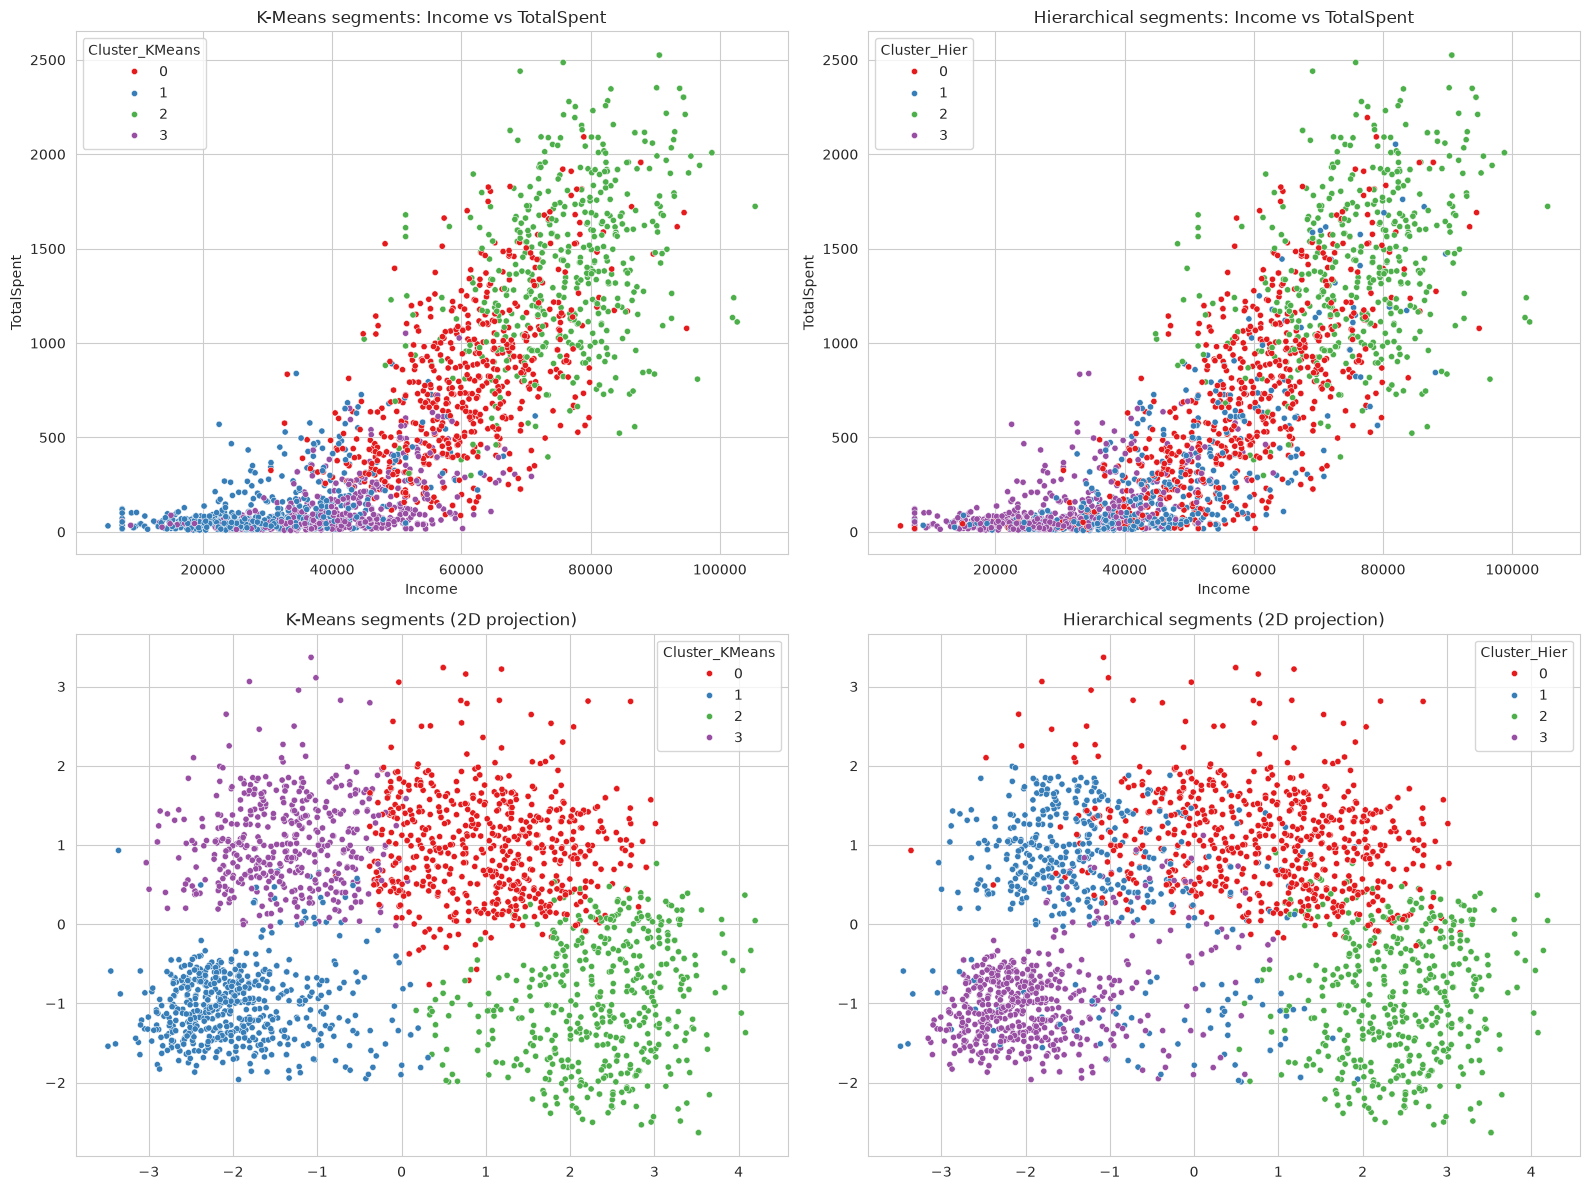

In [136]:
pcs = PCA(n_components=2, random_state=42).fit_transform(X_seg)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.scatterplot(data=seg, x='Income', y='TotalSpent', hue='Cluster_KMeans', palette='Set1', ax=axes[0, 0], s=20)
axes[0, 0].set_title('K-Means segments: Income vs TotalSpent')
sns.scatterplot(data=seg, x='Income', y='TotalSpent', hue='Cluster_Hier', palette='Set1', ax=axes[0, 1], s=20)
axes[0, 1].set_title('Hierarchical segments: Income vs TotalSpent')
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=seg['Cluster_KMeans'], palette='Set1', ax=axes[1, 0], s=20)
axes[1, 0].set_title('K-Means segments (2D projection)')
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=seg['Cluster_Hier'], palette='Set1', ax=axes[1, 1], s=20)
axes[1, 1].set_title('Hierarchical segments (2D projection)')
plt.tight_layout()
plt.show()

Calculate customer lifetime value (CLTV) based on purchase history and customer demographics.


In [137]:
# CLTV = average order value x purchase frequency x expected customer lifespan
total_spent = df[mnt_cols].sum(axis=1)
total_purchases = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
avg_order_value = (total_spent / total_purchases.replace(0, np.nan)).fillna(0)
purchases_per_year = total_purchases / 2           # Mnt* columns cover the last 2 years

# Demographic churn proxy: share of inactive customers (Recency > 60 days) in each Education x Marital_Status group
inactive = (df['Recency'] > 60).astype(int)
group_churn = inactive.groupby([df['Education'], df['Marital_Status']]).transform('mean').clip(lower=0.05)
lifespan_years = 1 / group_churn

df['CLTV'] = avg_order_value * purchases_per_year * lifespan_years
print(df['CLTV'].describe().round(2))
display(df.groupby('Education')['CLTV'].mean().round(2))
display(df.groupby('Marital_Status')['CLTV'].mean().round(2))

count    2197.00
mean      787.36
std       793.08
min        10.04
25%        90.32
50%       501.53
75%      1348.34
max      4238.40
Name: CLTV, dtype: float64


Education
Basic         130.19
Graduation    769.45
Master        760.58
PhD           936.23
Name: CLTV, dtype: float64

Marital_Status
Divorced     814.22
Married      765.37
Single       766.98
Together     778.05
Widow       1155.28
Name: CLTV, dtype: float64

Consider creating new features based on existing variables (e.g., calculate the total purchase amount or average purchase frequency).

In [138]:
df['Age'] = 2014 - df['Year_Birth']
df['TotalSpent'] = df[mnt_cols].sum(axis=1)
df['TotalPurchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
df['TotalAcceptedCmp'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)
df['AvgSpendPerPurchase'] = (df['TotalSpent'] / df['TotalPurchases'].replace(0, np.nan)).fillna(0)
df[['Age', 'TotalSpent', 'TotalPurchases', 'TotalChildren', 'TotalAcceptedCmp', 'AvgSpendPerPurchase']].head()

,Age,TotalSpent,TotalPurchases,TotalChildren,TotalAcceptedCmp,AvgSpendPerPurchase
0,57,1617,22,0,0,73.500000
1,60,27,4,2,0,6.750000
2,49,776,20,0,0,38.800000
3,30,53,6,1,0,8.833333
4,33,422,14,1,0,30.142857


Extract relevant date-based features (e.g., day of week, month, year) from Dt_Customer.


In [139]:
df['Enrol_Year'] = df['Dt_Customer'].dt.year
df['Enrol_Month'] = df['Dt_Customer'].dt.month
df['Enrol_DayOfWeek'] = df['Dt_Customer'].dt.dayofweek
df['Customer_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days
df[['Dt_Customer', 'Enrol_Year', 'Enrol_Month', 'Enrol_DayOfWeek', 'Customer_Days']].head()

,Dt_Customer,Enrol_Year,Enrol_Month,Enrol_DayOfWeek,Customer_Days
0,2012-09-04,2012,9,1,663
1,2014-03-08,2014,3,5,113
2,2013-08-21,2013,8,2,312
3,2014-02-10,2014,2,0,139
4,2014-01-19,2014,1,6,161


Combine existing features to capture interactions (e.g., Income * NumDealsPurchases).


In [140]:
df['Income_x_NumDealsPurchases'] = df['Income'] * df['NumDealsPurchases']
df['Spend_to_Income'] = df['TotalSpent'] / df['Income']
df['Age_x_Income'] = df['Age'] * df['Income']
df[['Income_x_NumDealsPurchases', 'Spend_to_Income', 'Age_x_Income']].head()

,Income_x_NumDealsPurchases,Spend_to_Income,Age_x_Income
0,174414.0,0.027813,3313866.0
1,92688.0,0.000583,2780640.0
2,71613.0,0.010836,3509037.0
3,53292.0,0.001989,799380.0
4,291465.0,0.007239,1923669.0


If numerical variables have skewed distributions, apply transformations like log transformations or square root transformations.


In [141]:
skew_cols = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
             'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
             'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'TotalSpent',
             'TotalPurchases', 'AvgSpendPerPurchase', 'CLTV', 'Customer_Days',
             'Income_x_NumDealsPurchases', 'Spend_to_Income', 'Age_x_Income']
skew_before = df[skew_cols].skew()
skewed = skew_before[skew_before.abs() > 0.75].index.tolist()
df[skewed] = np.log1p(df[skewed])          # log transformation (all values are >= 0)
print(pd.DataFrame({'skew_before': skew_before[skewed], 'skew_after': df[skewed].skew()}).round(3))

                            skew_before  skew_after
MntWines                          1.180      -0.548
MntFruits                         2.106       0.081
MntMeatProducts                   1.827      -0.081
MntFishProducts                   1.917      -0.057
MntSweetProducts                  2.079       0.077
MntGoldProds                      1.780      -0.357
NumDealsPurchases                 2.064       0.659
NumCatalogPurchases               1.053       0.082
TotalSpent                        0.873      -0.351
AvgSpendPerPurchase              21.197      -0.065
CLTV                              0.954      -0.352
Income_x_NumDealsPurchases        2.553      -5.341


If the target variable (Response) is imbalanced, use techniques like oversampling, undersampling, or class weighting to address the imbalance.

Response
0    1872
1     325
Name: count, dtype: int64
Response
0    85.21
1    14.79
Name: proportion, dtype: float64


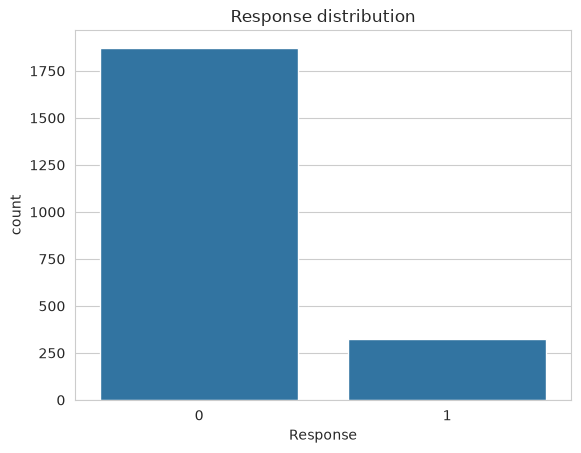

Class counts after oversampling: [1872 1872]


In [142]:
print(df['Response'].value_counts())
print((df['Response'].value_counts(normalize=True) * 100).round(2))
sns.countplot(data=df, x='Response')
plt.title('Response distribution')
plt.show()

# Random oversampling of the minority class.
# It is applied only to the TRAINING splits later on, so the test sets stay untouched.
def oversample(X, y, random_state=42):
    X, y = np.asarray(X), np.asarray(y)
    rng = np.random.RandomState(random_state)
    classes, counts = np.unique(y, return_counts=True)
    idx = []
    for c in classes:
        c_idx = np.where(y == c)[0]
        idx.append(c_idx if len(c_idx) == counts.max() else rng.choice(c_idx, counts.max(), replace=True))
    idx = np.concatenate(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]

_, y_demo = oversample(df.drop(columns='Response'), df['Response'])
print('Class counts after oversampling:', np.bincount(y_demo))

## Feature Selection:

Consider using feature selection techniques (e.g., correlation analysis, recursive feature elimination) to identify the most relevant features before applying PCA.

In [143]:
feat_df = df.drop(columns=['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'])   # identifier, raw date, constants
feat_df = pd.get_dummies(feat_df, columns=['Education', 'Marital_Status'], dtype=int)
target = feat_df['Response']
X_all = feat_df.drop(columns='Response')

# 1) Correlation with the target
corr_target = X_all.corrwith(target).abs().sort_values(ascending=False)
print('Top 10 features correlated with Response:\n', corr_target.head(10).round(3))

# 2) Remove one feature from every highly correlated pair (|r| > 0.9)
corr_matrix = X_all.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if (upper[c] > 0.9).any()]
print('\nDropped (highly correlated):', to_drop)
X_all = X_all.drop(columns=to_drop)

# 3) Recursive feature elimination
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=20)
rfe.fit(StandardScaler().fit_transform(X_all), target)
selected_features = X_all.columns[rfe.support_].tolist()
print('\nSelected features (%d):' % len(selected_features), selected_features)

Top 10 features correlated with Response:
 TotalAcceptedCmp       0.418
AcceptedCmp5           0.314
AcceptedCmp1           0.281
AcceptedCmp3           0.251
Spend_to_Income        0.248
AvgSpendPerPurchase    0.231
NumCatalogPurchases    0.228
MntMeatProducts        0.216
CLTV                   0.208
TotalSpent             0.207
dtype: float64

Dropped (highly correlated): ['CLTV', 'Age', 'TotalSpent', 'TotalPurchases', 'AvgSpendPerPurchase', 'Customer_Days', 'Spend_to_Income']

Selected features (20): ['Year_Birth', 'Income', 'Teenhome', 'Recency', 'MntWines', 'MntMeatProducts', 'MntFishProducts', 'NumDealsPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'TotalChildren', 'TotalAcceptedCmp', 'Enrol_Year', 'Enrol_Month', 'Age_x_Income', 'Education_Basic', 'Education_PhD', 'Marital_Status_Married', 'Marital_Status_Together']


Save the preprocessed data into a .csv file

In [144]:
X_sel = X_all[selected_features]
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_sel), columns=selected_features)
preprocessed = pd.concat([X_scaled, target.reset_index(drop=True)], axis=1)
preprocessed.to_csv('preprocessed_marketing_campaign.csv', index=False)
print('Saved:', preprocessed.shape)

Saved: (2197, 21)


## PCA

Load the preprocessed data:

In [145]:
data = pd.read_csv('preprocessed_marketing_campaign.csv')
data.head()

,Year_Birth,Income,Teenhome,Recency,MntWines,MntMeatProducts,MntFishProducts,NumDealsPurchases,NumCatalogPurchases,NumStorePurchases,...,TotalChildren,TotalAcceptedCmp,Enrol_Year,Enrol_Month,Age_x_Income,Education_Basic,Education_PhD,Marital_Status_Married,Marital_Status_Together,Response
0,-1.021738,0.322727,-0.937332,0.307465,0.988406,1.415792,1.577506,0.664089,1.856952,-0.569211,...,-1.277422,-0.439036,-1.498748,0.725461,0.787131,-0.15874,-0.523796,-0.795138,-0.591193,1
1,-1.278605,-0.259159,0.899705,-0.383620,-1.223631,-1.410684,-0.868631,0.034854,-0.400888,-1.188759,...,1.386551,-0.439036,1.424243,-0.992037,0.339955,-0.15874,-0.523796,-0.795138,-0.591193,0
2,-0.336760,0.987549,-0.937332,-0.798271,0.766430,0.473911,1.315201,-0.852003,0.136127,1.289432,...,-1.277422,-0.439036,-0.037253,0.439212,0.950806,-0.15874,-0.523796,-0.795138,1.691496,0
3,1.290063,-1.231007,-0.937332,-0.798271,-1.223631,-0.698243,-0.084790,0.034854,-1.318921,-0.569211,...,0.054565,-0.439036,1.424243,-1.278287,-1.321577,-0.15874,-0.523796,-0.795138,1.691496,0
4,1.033196,0.330374,-0.937332,1.551418,0.266263,0.426631,0.791336,1.550945,0.517145,0.050336,...,0.054565,-0.439036,1.424243,-1.564537,-0.378721,-0.15874,1.909141,1.257644,-0.591193,0


Select features for PCA without target variable

In [146]:
X = data.drop(columns='Response')
y = data['Response']
print(X.shape, y.shape)

(2197, 20) (2197,)


Create a PCA object:



In [147]:
pca = PCA(random_state=42)

Fit PCA to the data:



In [148]:
pca.fit(X)

,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",42
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to

Get explained variance ratio:



In [149]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
pd.DataFrame({'Component': [f'PC{i + 1}' for i in range(len(explained_variance_ratio))],
              'Explained Variance Ratio': explained_variance_ratio.round(4),
              'Cumulative Variance': cumulative_variance.round(4)})

,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.3053,0.3053
1,PC2,0.1244,0.4297
2,PC3,0.0912,0.5209
3,PC4,0.0743,0.5952
4,PC5,0.0583,0.6535
5,PC6,0.0521,0.7056
6,PC7,0.0495,0.7551
7,PC8,0.0457,0.8008
8,PC9,0.0436,0.8443
9,PC10,0.0338,0.8781


Determine the optimal number of components:

Analyze the explained variance ratio to determine the number of components that capture a significant portion of the variance.

In [150]:
n_components = int(np.argmax(cumulative_variance >= 0.95) + 1)   # smallest number of components keeping 95% variance
print(f'Components needed for 95% variance: {n_components} (of {X.shape[1]})')

Components needed for 95% variance: 14 (of 20)


Transform the data:

In [151]:
pca_opt = PCA(n_components=n_components, random_state=42)
X_pca = pca_opt.fit_transform(X)
pca_names = [f'PC{i + 1}' for i in range(n_components)]
print('Transformed shape:', X_pca.shape)

Transformed shape: (2197, 14)


Visualize explained variance ratio:


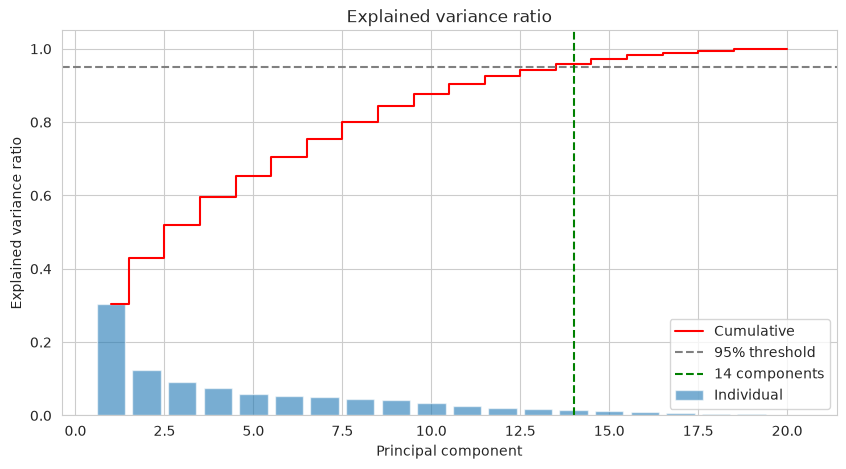

In [152]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, label='Individual')
ax.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', color='red', label='Cumulative')
ax.axhline(0.95, color='gray', linestyle='--', label='95% threshold')
ax.axvline(n_components, color='green', linestyle='--', label=f'{n_components} components')
ax.set_xlabel('Principal component')
ax.set_ylabel('Explained variance ratio')
ax.set_title('Explained variance ratio')
ax.legend()
plt.show()

Visualize principal components:


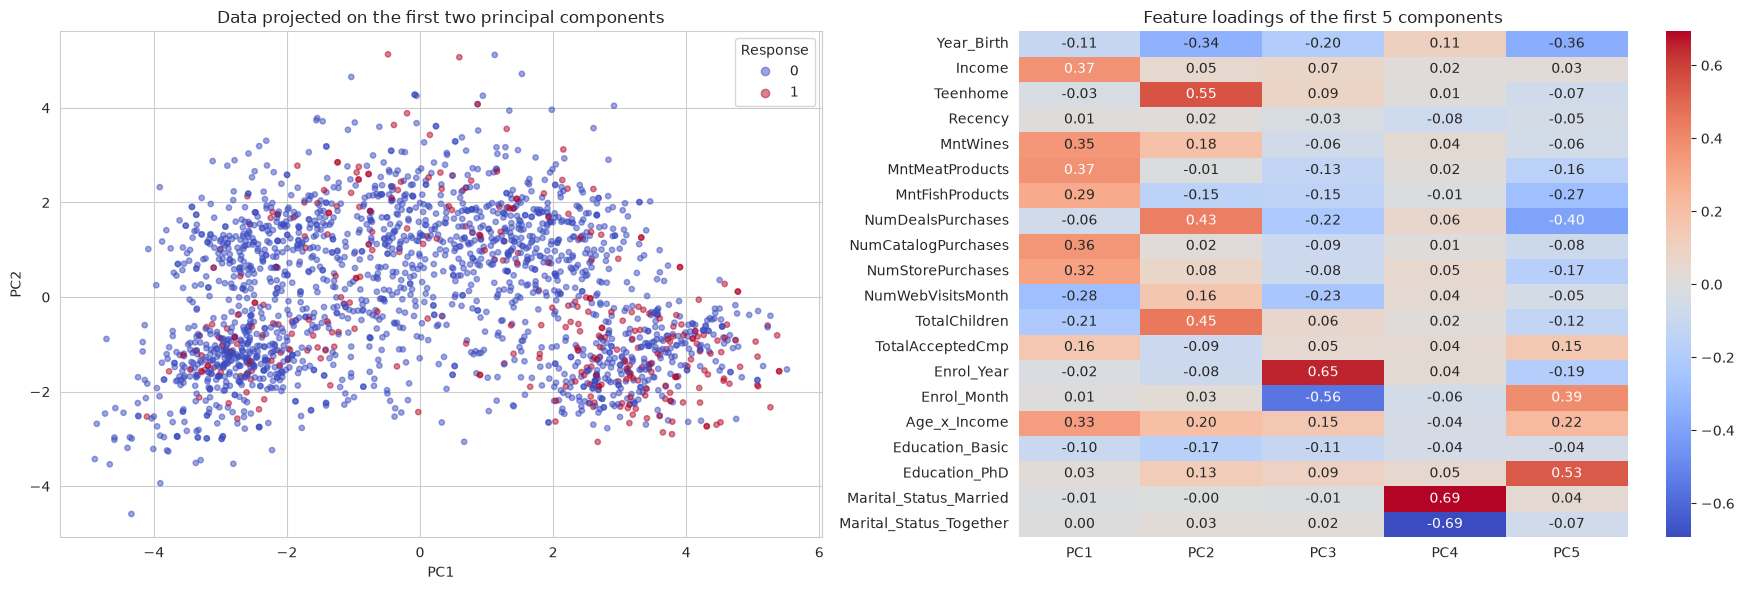

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.5, s=15)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Data projected on the first two principal components')
axes[0].legend(*sc.legend_elements(), title='Response')
loadings = pd.DataFrame(pca_opt.components_[:5].T, index=X.columns, columns=pca_names[:5])
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('Feature loadings of the first 5 components')
plt.tight_layout()
plt.show()

Save the PCA results into a .csv file

In [154]:
pca_df = pd.DataFrame(X_pca, columns=pca_names)
pca_df['Response'] = y.values
pca_df.to_csv('pca_results.csv', index=False)
print('Saved:', pca_df.shape)

Saved: (2197, 15)


## Model Building, Evaluation, and Comparison

### Logistic Regression

Build models with and without PCA:

Create logistic regression models using the original features and the features extracted from PCA.

In [155]:
lr_orig = LogisticRegression(max_iter=1000, random_state=42)   # original features
lr_pca = LogisticRegression(max_iter=1000, random_state=42)    # PCA features

Split data into training and testing sets:

Randomly split the data into training and testing sets.

In [156]:
def make_split(X, y, test_size=0.2, random_state=42):
    X_tr, X_te, y_tr, y_te = train_test_split(np.asarray(X), np.asarray(y), test_size=test_size,
                                              stratify=y, random_state=random_state)
    X_tr, y_tr = oversample(X_tr, y_tr, random_state)    # oversample only the training set
    return X_tr, X_te, y_tr, y_te

X_train, X_test, y_train, y_test = make_split(X, y)
Xp_train, Xp_test, yp_train, yp_test = make_split(X_pca, y)
print('Original:', X_train.shape, X_test.shape, '| PCA:', Xp_train.shape, Xp_test.shape)

Original: (2994, 20) (440, 20) | PCA: (2994, 14) (440, 14)


Train models:

Train the logistic regression models on the training sets.

In [157]:
lr_orig.fit(X_train, y_train)
lr_pca.fit(Xp_train, yp_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

Make predictions:

Use the trained models to make predictions on the testing sets.

In [158]:
y_pred_lr = lr_orig.predict(X_test)
y_pred_lr_pca = lr_pca.predict(Xp_test)

Evaluate performance:

Calculate accuracy, precision, recall, F1-score, and confusion matrix for both models.
Plot the learning curves (training and testing loss/accuracy) for both models.

Logistic Regression (Original): Accuracy=0.8477  Precision=0.4914  Recall=0.8769  F1=0.6298
Confusion matrix:
 [[316  59]
 [  8  57]] 

Logistic Regression (PCA): Accuracy=0.8432  Precision=0.4828  Recall=0.8615  F1=0.6188
Confusion matrix:
 [[315  60]
 [  9  56]] 



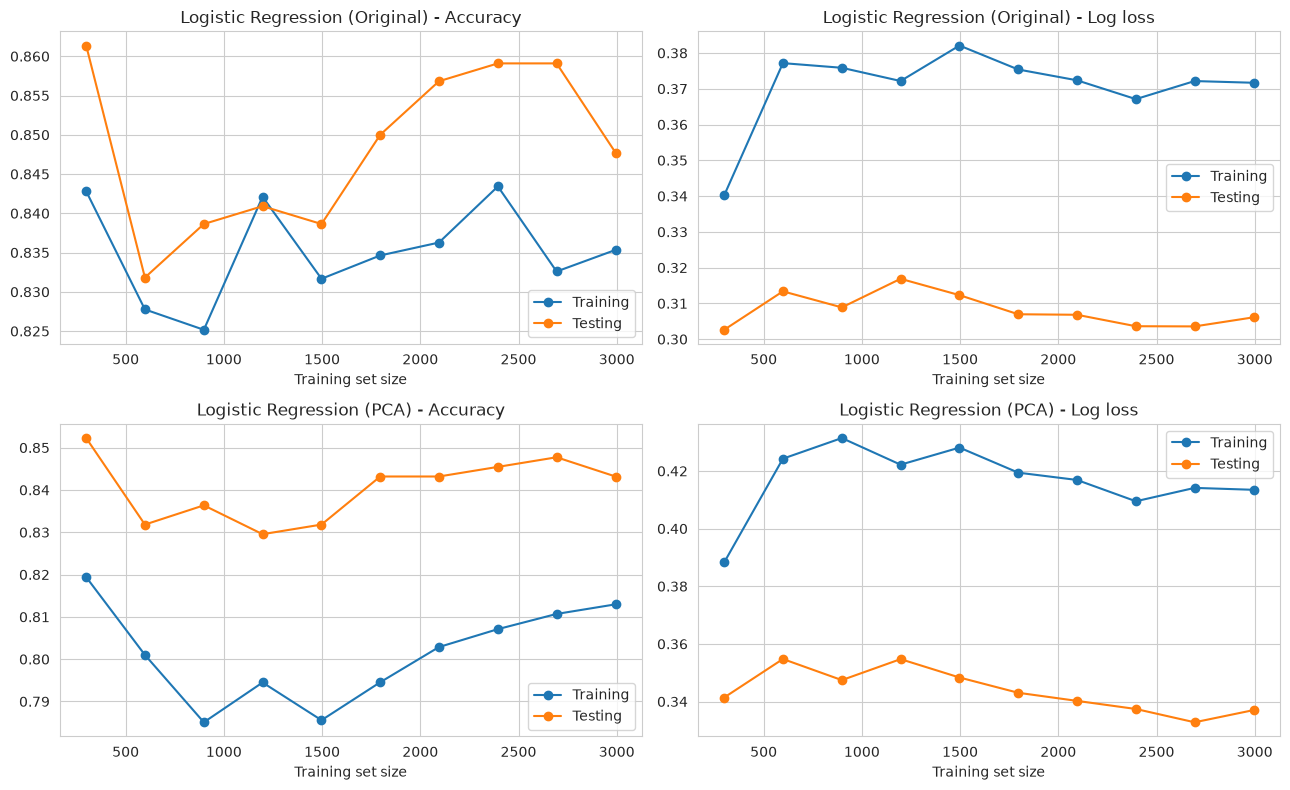

In [159]:
results = []

def evaluate_model(name, features, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    results.append({'Model': name, 'Features': features,
                    'Accuracy': accuracy_score(y_true, y_pred),
                    'Precision': precision_score(y_true, y_pred, zero_division=0),
                    'Recall': recall_score(y_true, y_pred, zero_division=0),
                    'F1': f1_score(y_true, y_pred, zero_division=0)})
    r = results[-1]
    print(f"{name} ({features}): Accuracy={r['Accuracy']:.4f}  Precision={r['Precision']:.4f}  "
          f"Recall={r['Recall']:.4f}  F1={r['F1']:.4f}")
    print('Confusion matrix:\n', cm, '\n')
    return cm

def plot_learning_curves(curves, title):
    # curves: {label: (model, X_train, y_train, X_test, y_test)}
    fig, axes = plt.subplots(len(curves), 2, figsize=(13, 4 * len(curves)), squeeze=False)
    for row, (label, (model, Xtr, ytr, Xte, yte)) in enumerate(curves.items()):
        order = np.random.RandomState(42).permutation(len(ytr))
        sizes, tr_acc, te_acc, tr_loss, te_loss = [], [], [], [], []
        for frac in np.linspace(0.1, 1.0, 10):
            sub = order[:int(frac * len(order))]
            m = clone(model).fit(Xtr[sub], ytr[sub])
            sizes.append(len(sub))
            tr_acc.append(accuracy_score(ytr[sub], m.predict(Xtr[sub])))
            te_acc.append(accuracy_score(yte, m.predict(Xte)))
            tr_loss.append(log_loss(ytr[sub], m.predict_proba(Xtr[sub]), labels=[0, 1]))
            te_loss.append(log_loss(yte, m.predict_proba(Xte), labels=[0, 1]))
        axes[row, 0].plot(sizes, tr_acc, marker='o', label='Training')
        axes[row, 0].plot(sizes, te_acc, marker='o', label='Testing')
        axes[row, 0].set_title(f'{title} ({label}) - Accuracy')
        axes[row, 1].plot(sizes, tr_loss, marker='o', label='Training')
        axes[row, 1].plot(sizes, te_loss, marker='o', label='Testing')
        axes[row, 1].set_title(f'{title} ({label}) - Log loss')
        for ax in axes[row]:
            ax.set_xlabel('Training set size')
            ax.legend()
    plt.tight_layout()
    plt.show()

cm_lr = evaluate_model('Logistic Regression', 'Original', y_test, y_pred_lr)
cm_lr_pca = evaluate_model('Logistic Regression', 'PCA', yp_test, y_pred_lr_pca)
plot_learning_curves({'Original': (lr_orig, X_train, y_train, X_test, y_test),
                      'PCA': (lr_pca, Xp_train, yp_train, Xp_test, yp_test)}, 'Logistic Regression')

Visualize confusion matrices:

Create heatmaps to visualize the confusion matrices for both models.

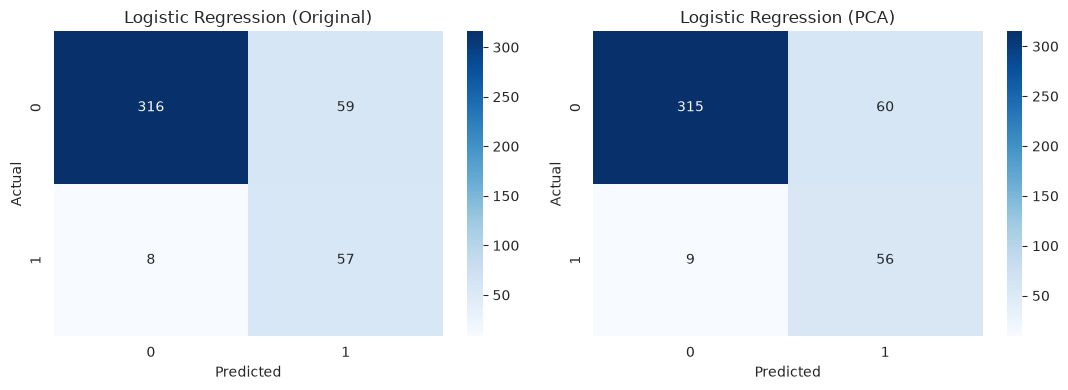

In [160]:
def plot_confusion_matrices(cm_orig, cm_pca, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, cm, label in zip(axes, [cm_orig, cm_pca], ['Original', 'PCA']):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'{title} ({label})')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(cm_lr, cm_lr_pca, 'Logistic Regression')

Compare performance:

Analyze the evaluation metrics and visualizations to compare the performance of the models with and without PCA.

,Model,Features,Accuracy,Precision,Recall,F1
0,Logistic Regression,Original,0.8477,0.4914,0.8769,0.6298
1,Logistic Regression,PCA,0.8432,0.4828,0.8615,0.6188


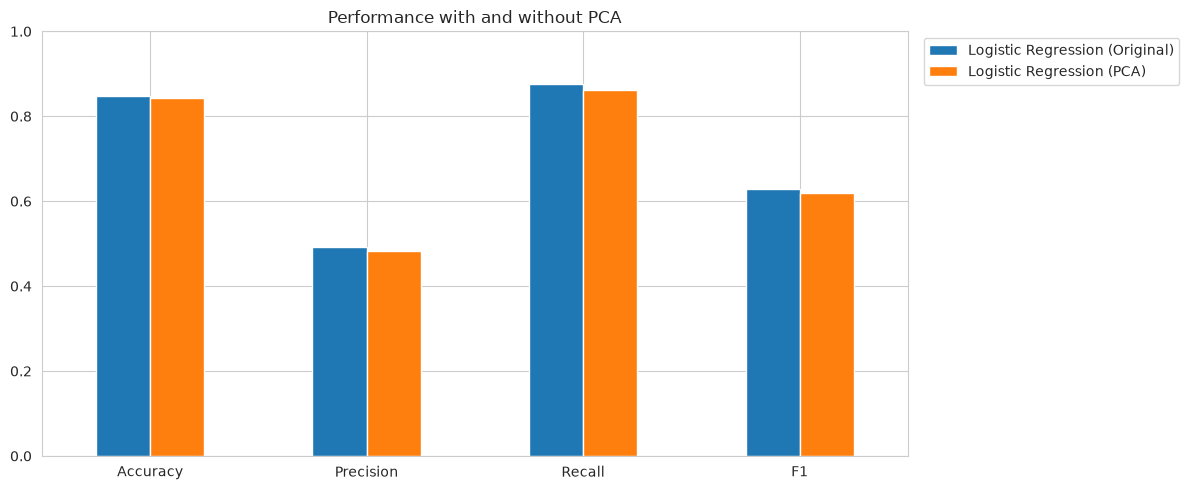

Logistic Regression: F1 Original=0.6298, PCA=0.6188 -> better F1 with: Original


In [161]:
def compare_models(model_names):
    res = pd.DataFrame(results)
    res = res[res['Model'].isin(model_names)].reset_index(drop=True)
    display(res.round(4))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
    plot_df = res.assign(Label=res['Model'] + ' (' + res['Features'] + ')').set_index('Label')[metrics]
    plot_df.T.plot(kind='bar', figsize=(12, 5), rot=0)
    plt.ylim(0, 1)
    plt.title('Performance with and without PCA')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    for m in model_names:
        sub = res[res['Model'] == m].set_index('Features')
        better = 'Original' if sub.loc['Original', 'F1'] >= sub.loc['PCA', 'F1'] else 'PCA'
        print(f"{m}: F1 Original={sub.loc['Original', 'F1']:.4f}, PCA={sub.loc['PCA', 'F1']:.4f} -> better F1 with: {better}")

compare_models(['Logistic Regression'])

### KNN

Choose the number of neighbors:

Experiment with different values for the n_neighbors parameter to find the optimal value.

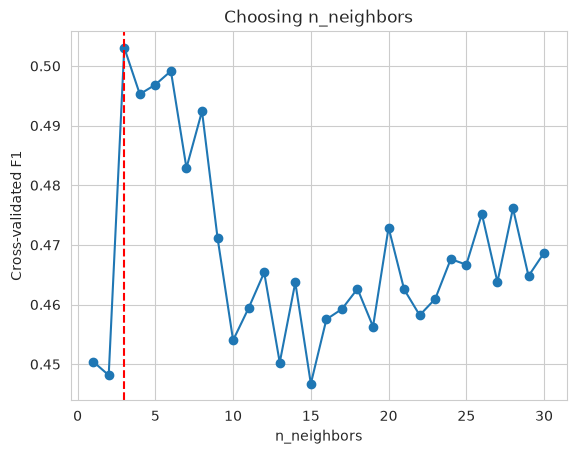

Best n_neighbors: 3


In [162]:
# Hyperparameters are tuned with cross-validation on the training part of the split only
Xt, _, yt, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
k_values = list(range(1, 31))
Xt_arr, yt_arr = np.asarray(Xt), np.asarray(yt)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = []
for k in k_values:
    fold_scores = []
    for tr, va in skf.split(Xt_arr, yt_arr):
        X_tr, y_tr = oversample(Xt_arr[tr], yt_arr[tr])      # oversample inside each training fold only
        knn = KNeighborsClassifier(n_neighbors=k).fit(X_tr, y_tr)
        fold_scores.append(f1_score(yt_arr[va], knn.predict(Xt_arr[va])))
    cv_f1.append(np.mean(fold_scores))
best_k = k_values[int(np.argmax(cv_f1))]
plt.plot(k_values, cv_f1, marker='o')
plt.axvline(best_k, color='red', linestyle='--')
plt.xlabel('n_neighbors')
plt.ylabel('Cross-validated F1')
plt.title('Choosing n_neighbors')
plt.show()
print('Best n_neighbors:', best_k)

Build models with and without PCA:

Create KNN models using the original features and the features extracted from PCA.

In [163]:
knn_orig = KNeighborsClassifier(n_neighbors=best_k)
knn_pca = KNeighborsClassifier(n_neighbors=best_k)

Split data into training and testing sets:

Randomly split the data into training and testing sets.

In [164]:
X_train, X_test, y_train, y_test = make_split(X, y)
Xp_train, Xp_test, yp_train, yp_test = make_split(X_pca, y)

Train models:

Train the KNN models on the training sets.

In [165]:
knn_orig.fit(X_train, y_train)
knn_pca.fit(Xp_train, yp_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Make predictions:

Use the trained models to make predictions on the testing sets.

In [166]:
y_pred_knn = knn_orig.predict(X_test)
y_pred_knn_pca = knn_pca.predict(Xp_test)

Calculate accuracy, precision, recall, F1-score, and confusion matrix for both models.
Plot the learning curves (training and testing loss/accuracy) for both models.

KNN (Original): Accuracy=0.8341  Precision=0.4524  Recall=0.5846  F1=0.5101
Confusion matrix:
 [[329  46]
 [ 27  38]] 

KNN (PCA): Accuracy=0.8364  Precision=0.4588  Recall=0.6000  F1=0.5200
Confusion matrix:
 [[329  46]
 [ 26  39]] 



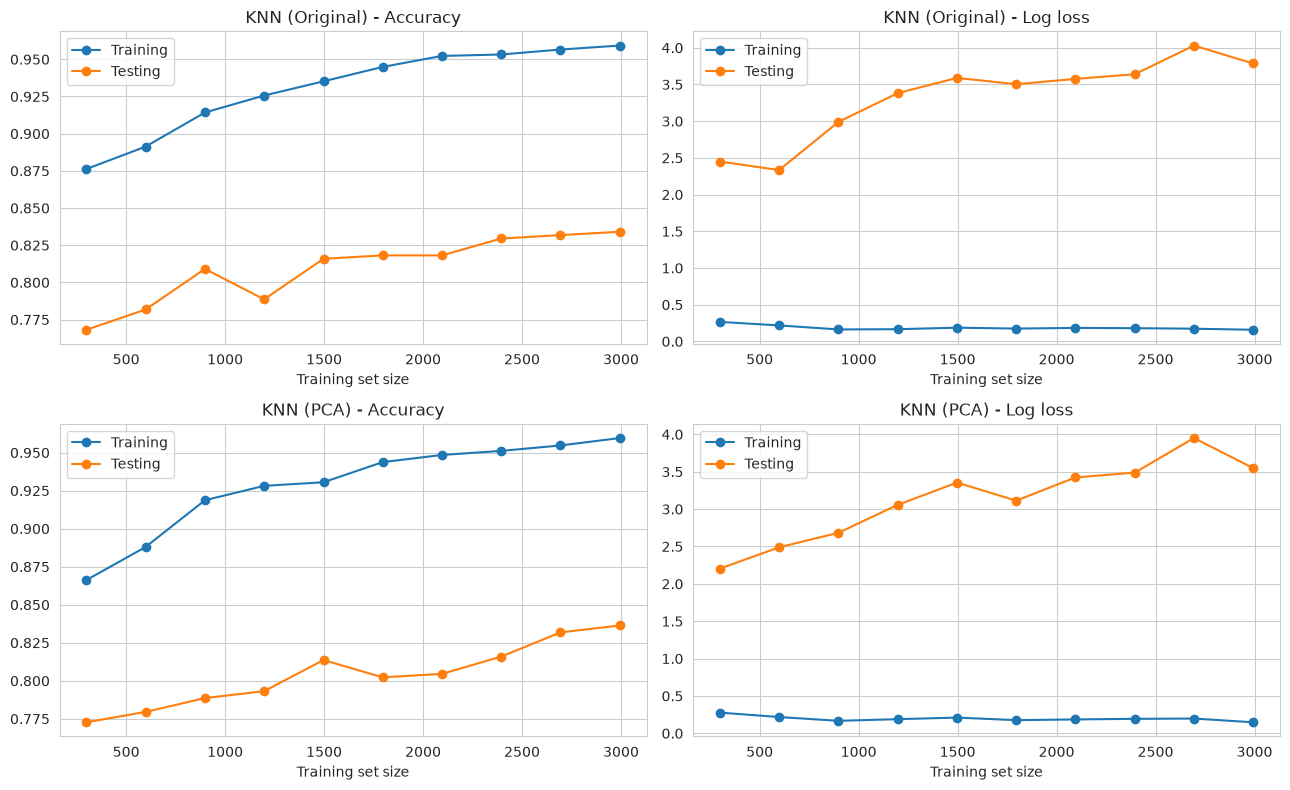

In [167]:
cm_knn = evaluate_model('KNN', 'Original', y_test, y_pred_knn)
cm_knn_pca = evaluate_model('KNN', 'PCA', yp_test, y_pred_knn_pca)
plot_learning_curves({'Original': (knn_orig, X_train, y_train, X_test, y_test),
                      'PCA': (knn_pca, Xp_train, yp_train, Xp_test, yp_test)}, 'KNN')

Visualize confusion matrices:

Create heatmaps to visualize the confusion matrices for both models.

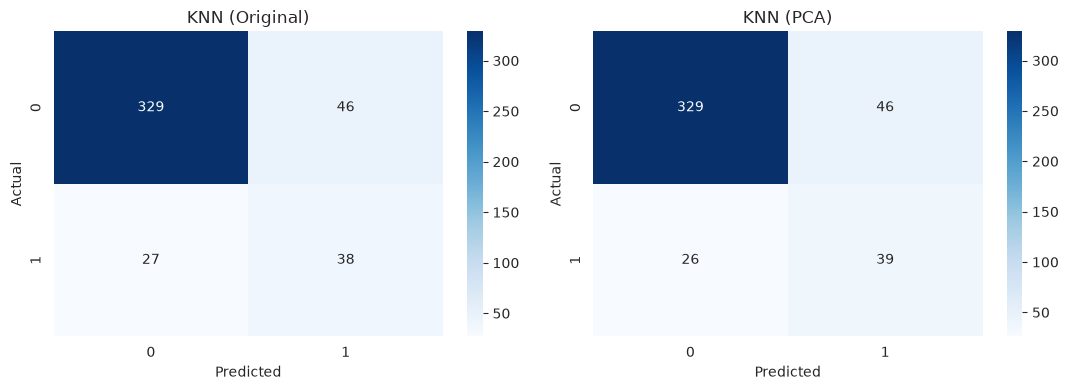

In [168]:
plot_confusion_matrices(cm_knn, cm_knn_pca, 'KNN')

Compare performance:

Analyze the evaluation metrics and visualizations to compare the performance of the models with and without PCA.

,Model,Features,Accuracy,Precision,Recall,F1
0,KNN,Original,0.8341,0.4524,0.5846,0.5101
1,KNN,PCA,0.8364,0.4588,0.6000,0.5200


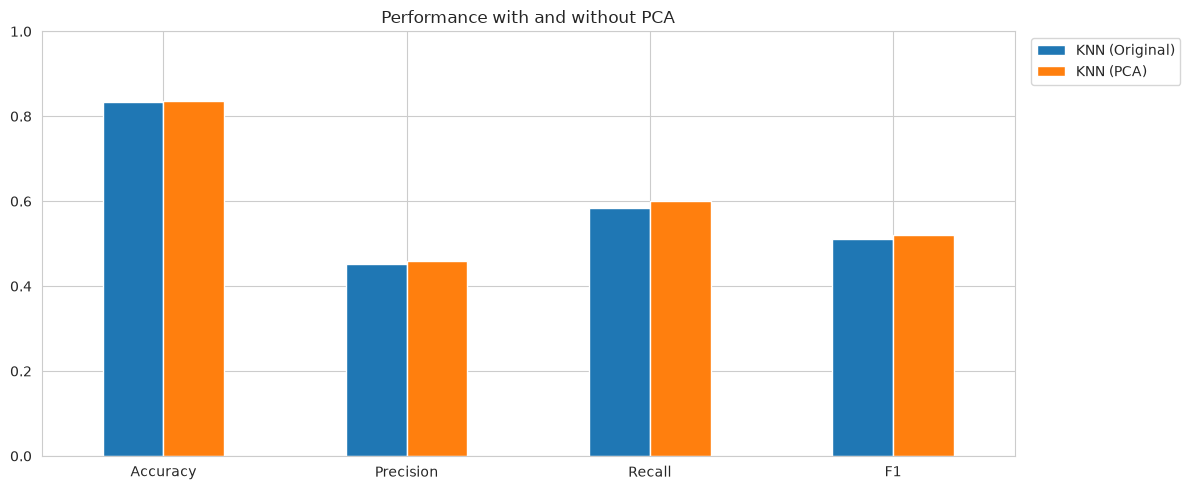

KNN: F1 Original=0.5101, PCA=0.5200 -> better F1 with: PCA


In [169]:
compare_models(['KNN'])

## Decision Tree

Choose hyperparameters:

Experiment with different hyperparameters (e.g., max_depth, min_samples_split) to find the optimal values.

In [170]:
Xt, _, yt, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
dt_grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=42),
                       {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 10, 20, 50]},
                       cv=5, scoring='f1')
dt_grid.fit(Xt, yt)
best_dt_params = dt_grid.best_params_
print('Best parameters:', best_dt_params, '| CV F1:', round(dt_grid.best_score_, 4))

Best parameters: {'max_depth': None, 'min_samples_split': 20} | CV F1: 0.4698


Build models with and without PCA:

Create decision tree models using the original features and the features extracted from PCA.

In [171]:
dt_orig = DecisionTreeClassifier(**best_dt_params, random_state=42)
dt_pca = DecisionTreeClassifier(**best_dt_params, random_state=42)

Split data into training and testing sets:

Randomly split the data into training and testing sets.

In [172]:
X_train, X_test, y_train, y_test = make_split(X, y)
Xp_train, Xp_test, yp_train, yp_test = make_split(X_pca, y)

Train models:

Train the decision tree models on the training sets.

In [173]:
dt_orig.fit(X_train, y_train)
dt_pca.fit(Xp_train, yp_train)

,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sample

Make predictions:

Use the trained models to make predictions on the testing sets.

In [174]:
y_pred_dt = dt_orig.predict(X_test)
y_pred_dt_pca = dt_pca.predict(Xp_test)

Evaluate performance:

Calculate accuracy, precision, recall, F1-score, and confusion matrix for both models.
Plot the learning curves (training and testing loss/accuracy) for both models.

Decision Tree (Original): Accuracy=0.8409  Precision=0.4648  Recall=0.5077  F1=0.4853
Confusion matrix:
 [[337  38]
 [ 32  33]] 

Decision Tree (PCA): Accuracy=0.8182  Precision=0.3973  Recall=0.4462  F1=0.4203
Confusion matrix:
 [[331  44]
 [ 36  29]] 



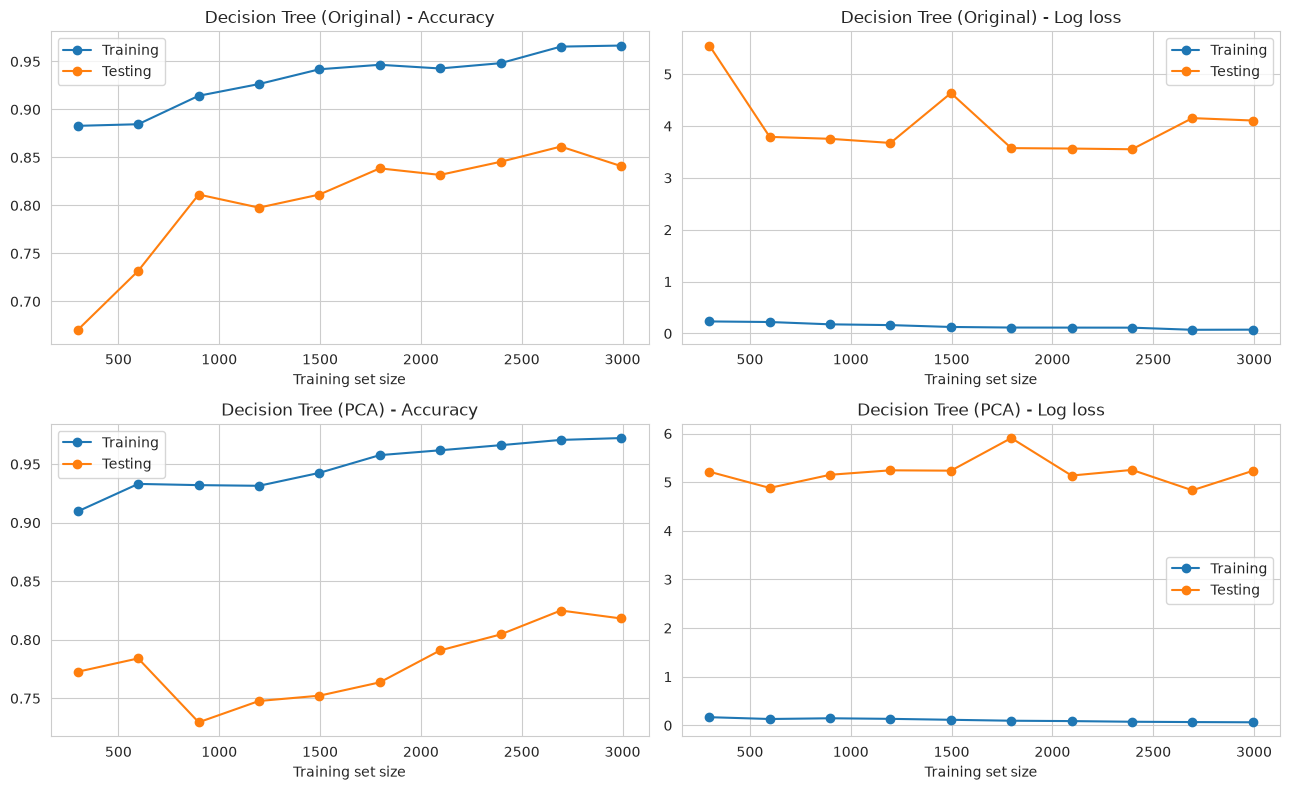

In [175]:
cm_dt = evaluate_model('Decision Tree', 'Original', y_test, y_pred_dt)
cm_dt_pca = evaluate_model('Decision Tree', 'PCA', yp_test, y_pred_dt_pca)
plot_learning_curves({'Original': (dt_orig, X_train, y_train, X_test, y_test),
                      'PCA': (dt_pca, Xp_train, yp_train, Xp_test, yp_test)}, 'Decision Tree')

Visualize decision trees:

Visualize the decision trees to understand the decision-making process.

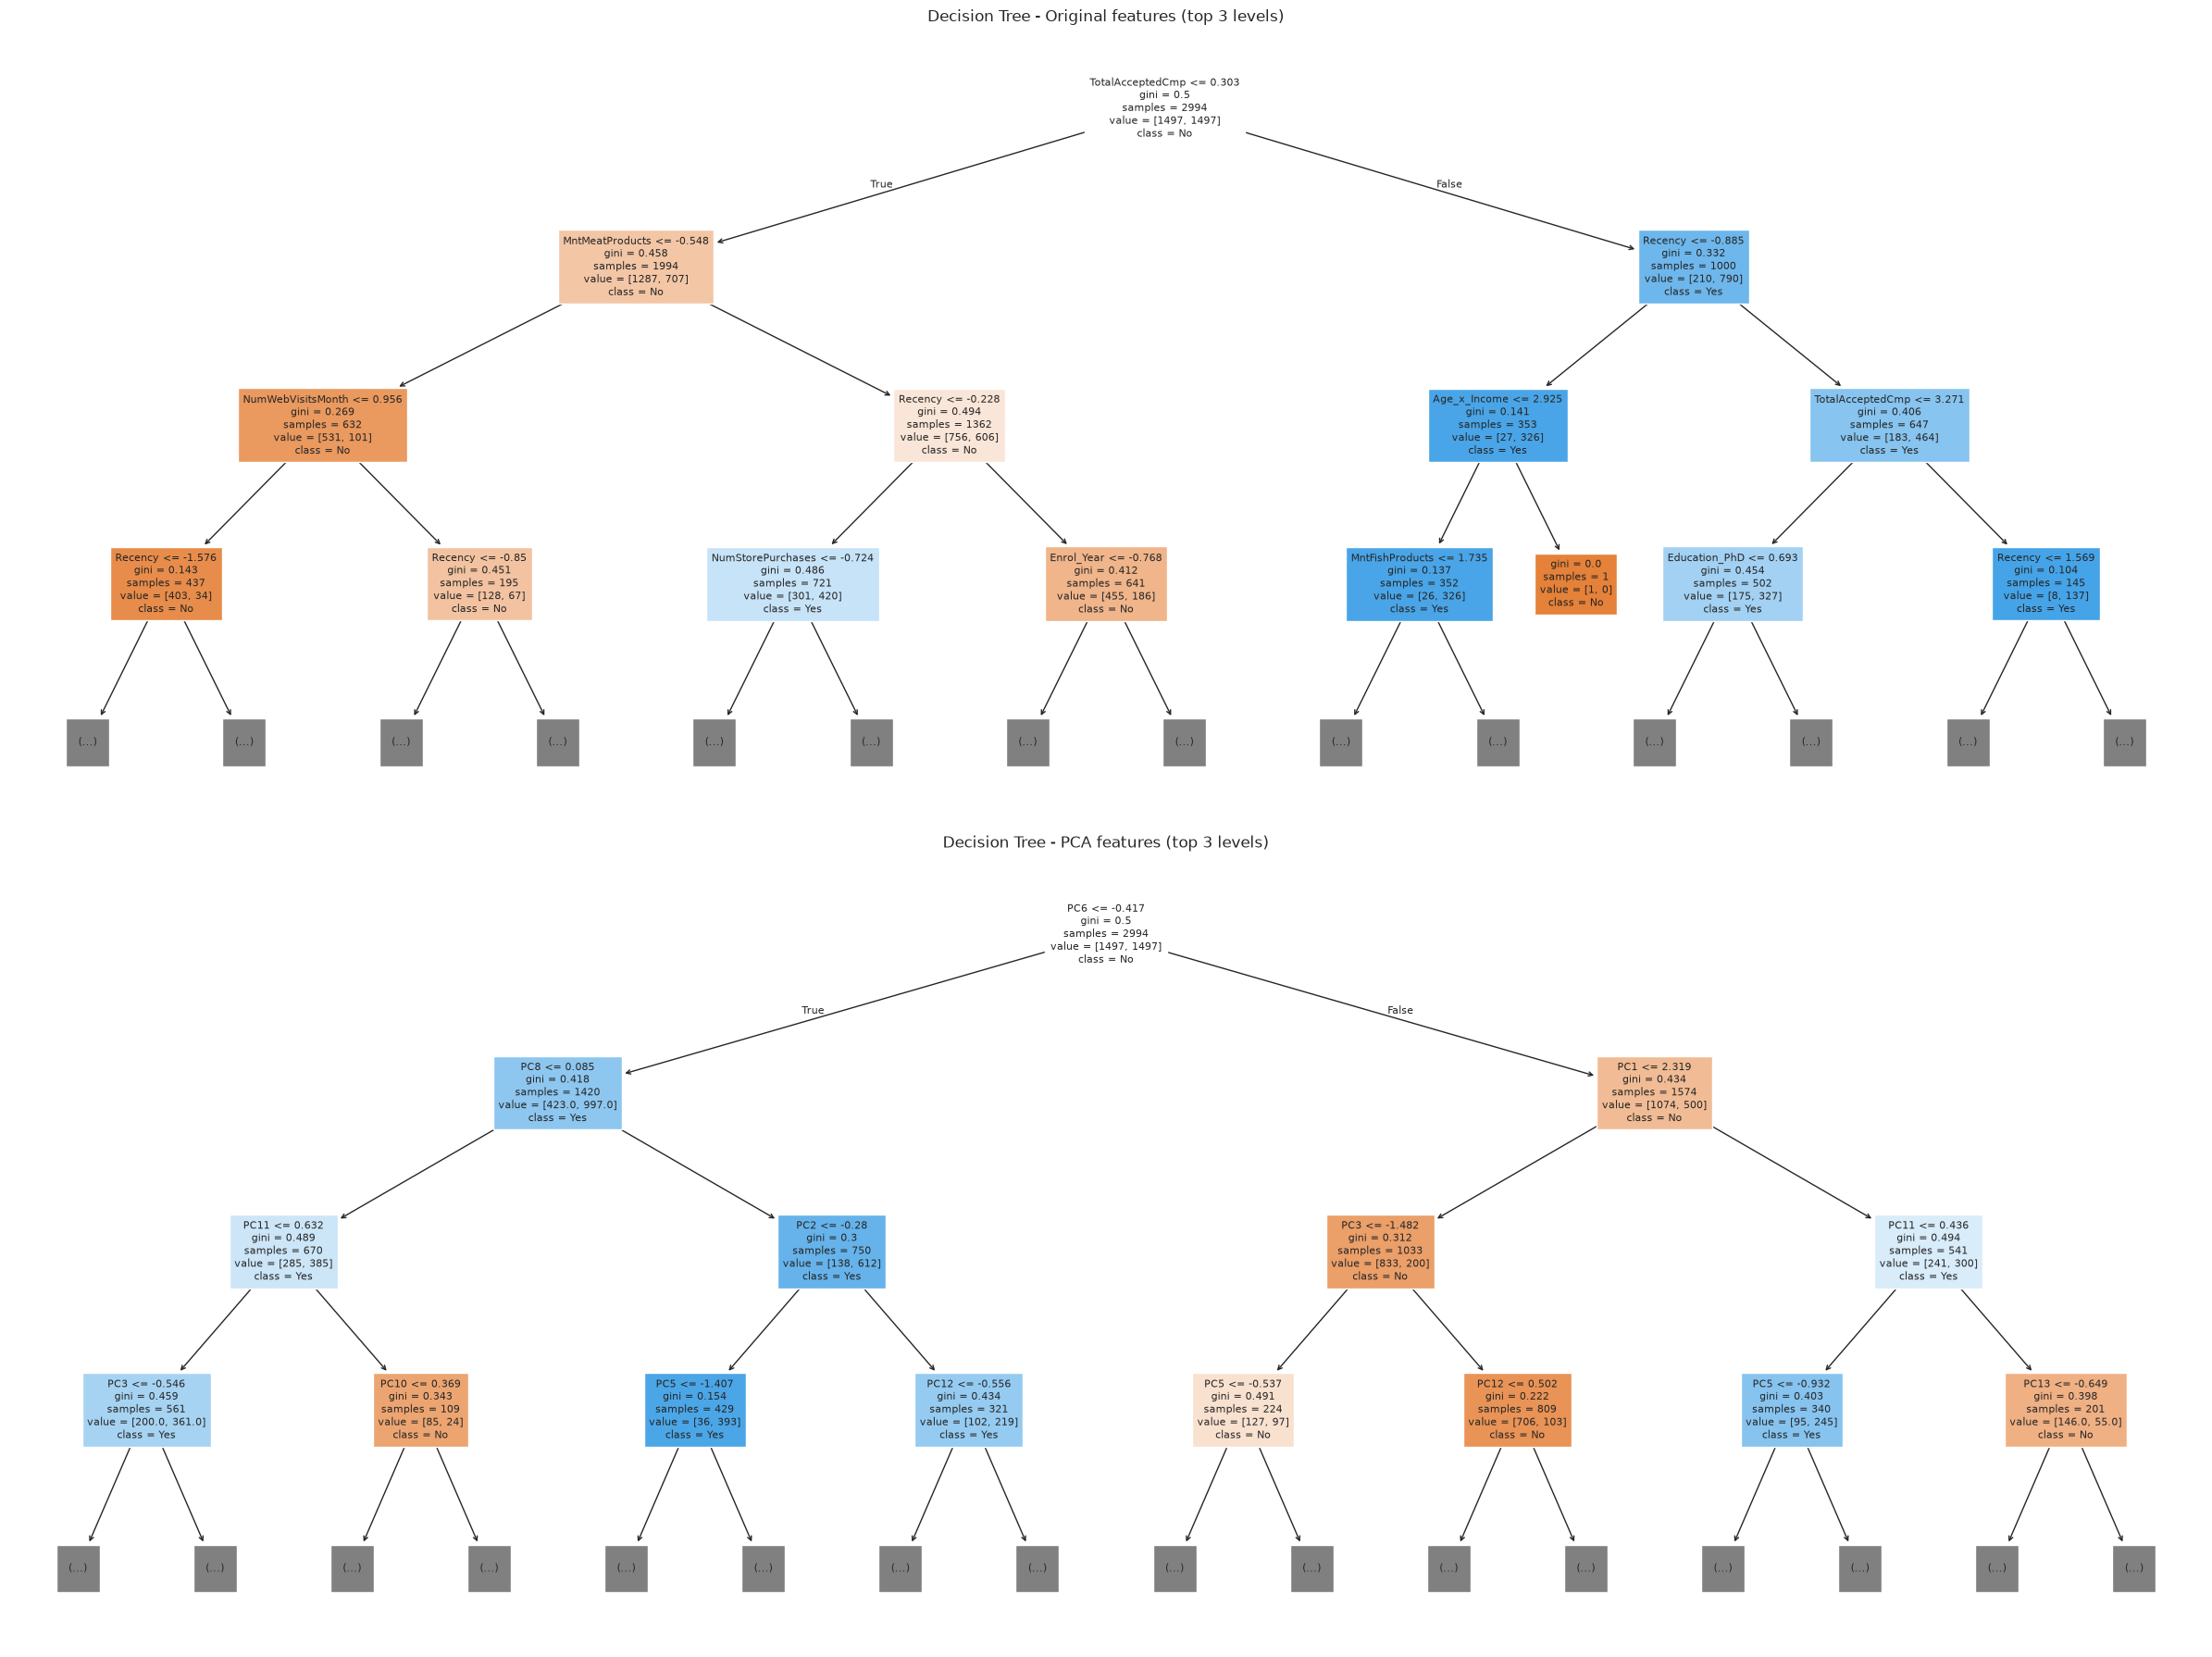

In [176]:
fig, axes = plt.subplots(2, 1, figsize=(24, 18))
plot_tree(dt_orig, feature_names=X.columns.tolist(), class_names=['No', 'Yes'], filled=True,
          max_depth=3, fontsize=8, ax=axes[0])
axes[0].set_title('Decision Tree - Original features (top 3 levels)')
plot_tree(dt_pca, feature_names=pca_names, class_names=['No', 'Yes'], filled=True,
          max_depth=3, fontsize=8, ax=axes[1])
axes[1].set_title('Decision Tree - PCA features (top 3 levels)')
plt.tight_layout()
plt.show()

Compare performance:

Analyze the evaluation metrics and visualizations to compare the performance of the models with and without PCA.

,Model,Features,Accuracy,Precision,Recall,F1
0,Decision Tree,Original,0.8409,0.4648,0.5077,0.4853
1,Decision Tree,PCA,0.8182,0.3973,0.4462,0.4203


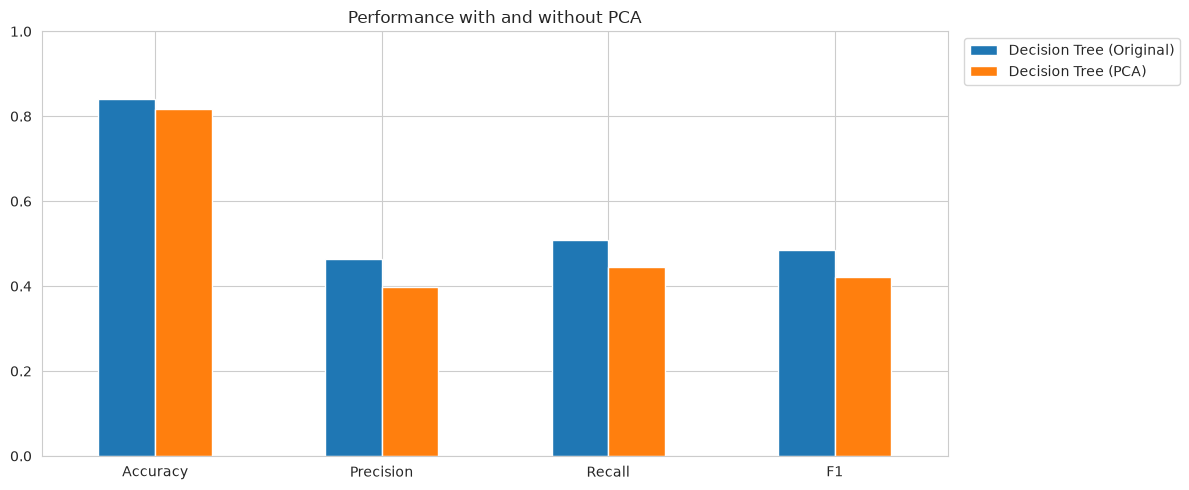

Decision Tree: F1 Original=0.4853, PCA=0.4203 -> better F1 with: Original


In [177]:
compare_models(['Decision Tree'])

## SVM

Choose kernel:

Experiment with different kernels (e.g., linear, RBF, polynomial) to find the optimal one.

In [178]:
Xt, _, yt, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_scores = {k: cross_val_score(SVC(kernel=k, class_weight='balanced'), Xt, yt, cv=5, scoring='f1').mean()
                 for k in kernels}
best_kernel = max(kernel_scores, key=kernel_scores.get)
print({k: round(float(v), 4) for k, v in kernel_scores.items()})
print('Best kernel:', best_kernel)

{'linear': 0.5533, 'rbf': 0.5977, 'poly': 0.5857, 'sigmoid': 0.4013}
Best kernel: rbf


Build models with and without PCA:

Create SVM models using the original features and the features extracted from PCA.

In [179]:
svm_orig = SVC(kernel=best_kernel, probability=True, random_state=42)
svm_pca = SVC(kernel=best_kernel, probability=True, random_state=42)

Split data into training and testing sets:

Randomly split the data into training and testing sets.

In [180]:
X_train, X_test, y_train, y_test = make_split(X, y)
Xp_train, Xp_test, yp_train, yp_test = make_split(X_pca, y)

Train models:

Train the SVM models on the training sets.

In [181]:
svm_orig.fit(X_train, y_train)
svm_pca.fit(Xp_train, yp_train)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


Make predictions:

Use the trained models to make predictions on the testing sets.

In [182]:
y_pred_svm = svm_orig.predict(X_test)
y_pred_svm_pca = svm_pca.predict(Xp_test)

Evaluate performance:

Calculate accuracy, precision, recall, F1-score, and confusion matrix for both models.
Plot the learning curves (training and testing loss/accuracy) for both models.

SVM (Original): Accuracy=0.8818  Precision=0.5714  Recall=0.8000  F1=0.6667
Confusion matrix:
 [[336  39]
 [ 13  52]] 

SVM (PCA): Accuracy=0.8750  Precision=0.5543  Recall=0.7846  F1=0.6497
Confusion matrix:
 [[334  41]
 [ 14  51]] 



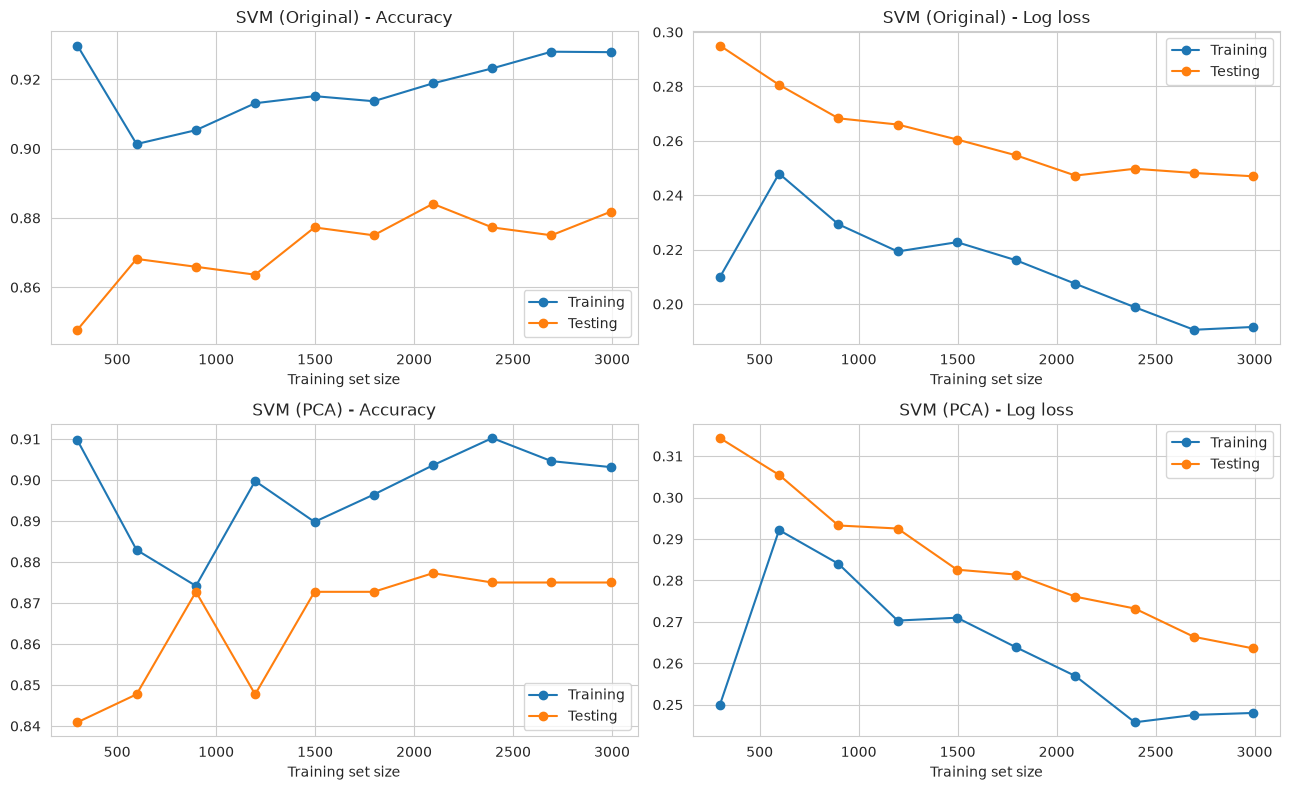

In [183]:
cm_svm = evaluate_model('SVM', 'Original', y_test, y_pred_svm)
cm_svm_pca = evaluate_model('SVM', 'PCA', yp_test, y_pred_svm_pca)
plot_learning_curves({'Original': (svm_orig, X_train, y_train, X_test, y_test),
                      'PCA': (svm_pca, Xp_train, yp_train, Xp_test, yp_test)}, 'SVM')

Compare performance:

Analyze the evaluation metrics and visualizations to compare the performance of the models with and without PCA.

,Model,Features,Accuracy,Precision,Recall,F1
0,SVM,Original,0.8818,0.5714,0.8000,0.6667
1,SVM,PCA,0.8750,0.5543,0.7846,0.6497


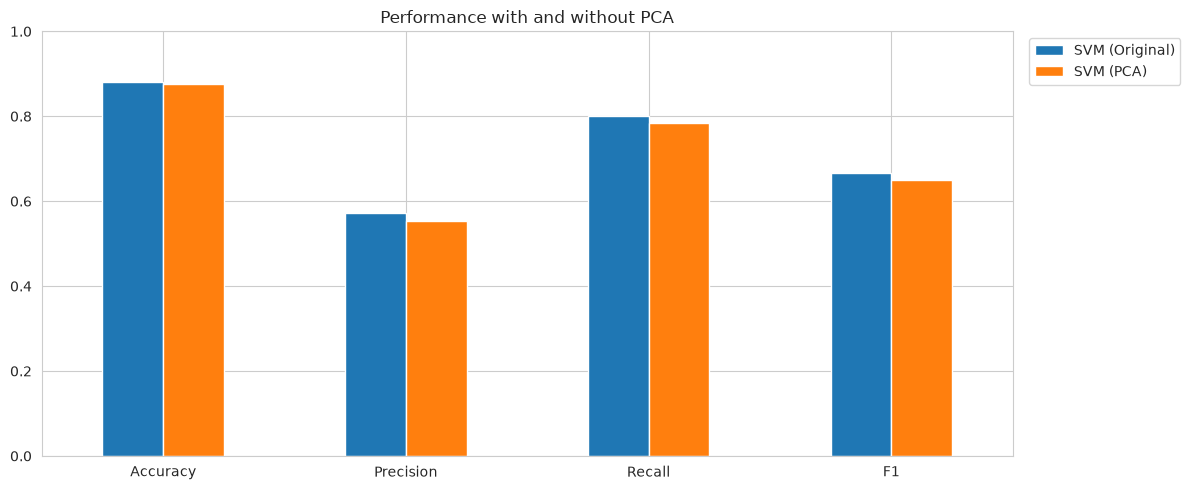

SVM: F1 Original=0.6667, PCA=0.6497 -> better F1 with: Original


In [184]:
compare_models(['SVM'])

## Naive Bayes

Choose a Naive Bayes variant:

Select a suitable Naive Bayes variant (e.g., Gaussian, Bernoulli, Multinomial) based on the data characteristics.

In [185]:
# MultinomialNB is not usable here: standardized and PCA features contain negative values
Xt, _, yt, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
nb_variants = {'GaussianNB': GaussianNB, 'BernoulliNB': BernoulliNB}
nb_scores = {n: cross_val_score(v(), Xt, yt, cv=5, scoring='f1').mean() for n, v in nb_variants.items()}
best_nb_name = max(nb_scores, key=nb_scores.get)
best_nb = nb_variants[best_nb_name]
print({k: round(float(v), 4) for k, v in nb_scores.items()})
print('Selected variant:', best_nb_name)

{'GaussianNB': 0.4112, 'BernoulliNB': 0.4069}
Selected variant: GaussianNB


Build models with and without PCA:

Create Naive Bayes models using the original features and the features extracted from PCA.

In [186]:
nb_orig = best_nb()
nb_pca = best_nb()

Split data into training and testing sets:

Randomly split the data into training and testing sets.

In [187]:
X_train, X_test, y_train, y_test = make_split(X, y)
Xp_train, Xp_test, yp_train, yp_test = make_split(X_pca, y)

Train models:

Train the Naive Bayes models on the training sets.

In [188]:
nb_orig.fit(X_train, y_train)
nb_pca.fit(Xp_train, yp_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[1497.,1497.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,6.684e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 14)","[[-0.19, 0.04, 0.05,...,-0.04, 0.01, 0.01], [ 1.2 ,-0.29,-0.32,..., 0.24,-0.03,-0.09]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 14)","[[5.82,2.41,1.81,...,0.38,0.37,0.28], [6.58,2.71,1.84,...,0.53,0.36,0.38]]"


Make predictions:

Use the trained models to make predictions on the testing sets.

In [189]:
y_pred_nb = nb_orig.predict(X_test)
y_pred_nb_pca = nb_pca.predict(Xp_test)

Evaluate performance:

Calculate accuracy, precision, recall, F1-score, and confusion matrix for both models.
Plot the learning curves (training and testing loss/accuracy) for both models.

Naive Bayes (Original): Accuracy=0.7114  Precision=0.2987  Recall=0.7077  F1=0.4201
Confusion matrix:
 [[267 108]
 [ 19  46]] 

Naive Bayes (PCA): Accuracy=0.8386  Precision=0.4737  Recall=0.8308  F1=0.6034
Confusion matrix:
 [[315  60]
 [ 11  54]] 



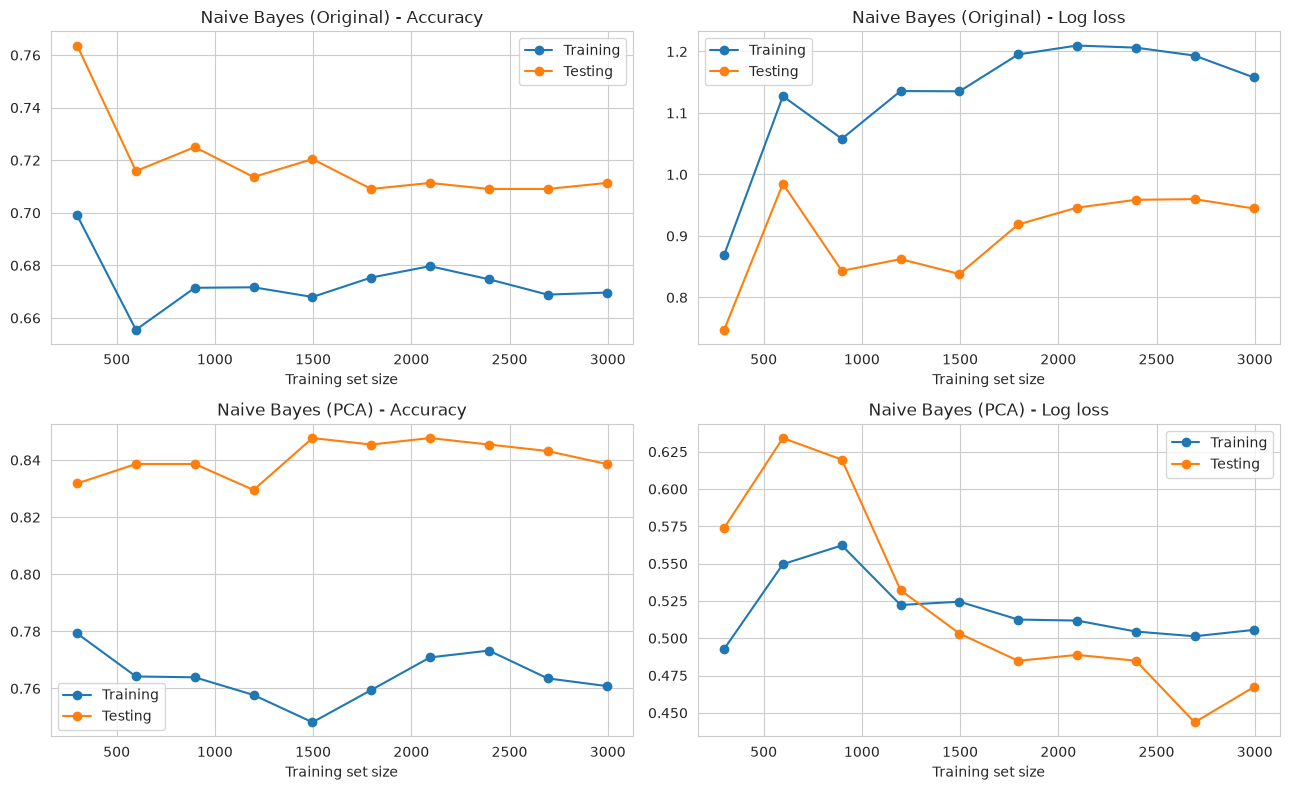

In [190]:
cm_nb = evaluate_model('Naive Bayes', 'Original', y_test, y_pred_nb)
cm_nb_pca = evaluate_model('Naive Bayes', 'PCA', yp_test, y_pred_nb_pca)
plot_learning_curves({'Original': (nb_orig, X_train, y_train, X_test, y_test),
                      'PCA': (nb_pca, Xp_train, yp_train, Xp_test, yp_test)}, 'Naive Bayes')

Compare performance:

Analyze the evaluation metrics and visualizations to compare the performance of the models with and without PCA.

,Model,Features,Accuracy,Precision,Recall,F1
0,Naive Bayes,Original,0.7114,0.2987,0.7077,0.4201
1,Naive Bayes,PCA,0.8386,0.4737,0.8308,0.6034


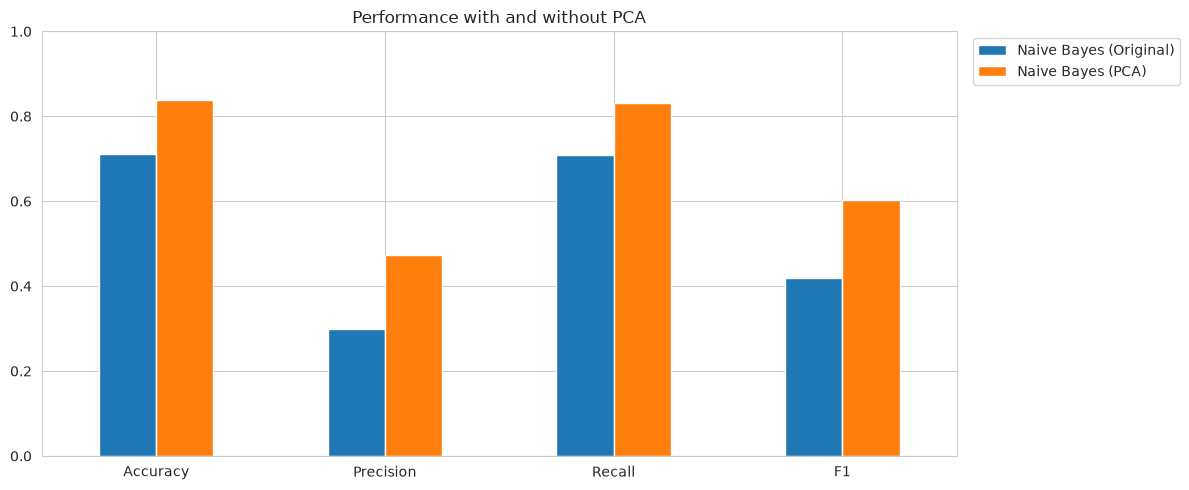

Naive Bayes: F1 Original=0.4201, PCA=0.6034 -> better F1 with: PCA


In [191]:
compare_models(['Naive Bayes'])

## Random Forest

Choose hyperparameters:

Experiment with different hyperparameters (e.g., n_estimators, max_depth) to find the optimal values.

In [192]:
Xt, _, yt, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                       {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, None]},
                       cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(Xt, yt)
best_rf_params = rf_grid.best_params_
print('Best parameters:', best_rf_params, '| CV F1:', round(rf_grid.best_score_, 4))

Best parameters: {'max_depth': 10, 'n_estimators': 100} | CV F1: 0.5747


Build models with and without PCA:

Create random forest models using the original features and the features extracted from PCA.

In [193]:
rf_orig = RandomForestClassifier(**best_rf_params, random_state=42)
rf_pca = RandomForestClassifier(**best_rf_params, random_state=42)

Split data into training and testing sets:

Randomly split the data into training and testing sets.

In [194]:
X_train, X_test, y_train, y_test = make_split(X, y)
Xp_train, Xp_test, yp_train, yp_test = make_split(X_pca, y)

Train models:

Train the random forest models on the training sets.

In [195]:
rf_orig.fit(X_train, y_train)
rf_pca.fit(Xp_train, yp_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

 Make predictions:

Use the trained models to make predictions on the testing sets.

In [196]:
y_pred_rf = rf_orig.predict(X_test)
y_pred_rf_pca = rf_pca.predict(Xp_test)

Calculate accuracy, precision, recall, F1-score, and confusion matrix for both models.
Plot the learning curves (training and testing loss/accuracy) for both models.

Random Forest (Original): Accuracy=0.9023  Precision=0.6833  Recall=0.6308  F1=0.6560
Confusion matrix:
 [[356  19]
 [ 24  41]] 

Random Forest (PCA): Accuracy=0.9114  Precision=0.7321  Recall=0.6308  F1=0.6777
Confusion matrix:
 [[360  15]
 [ 24  41]] 



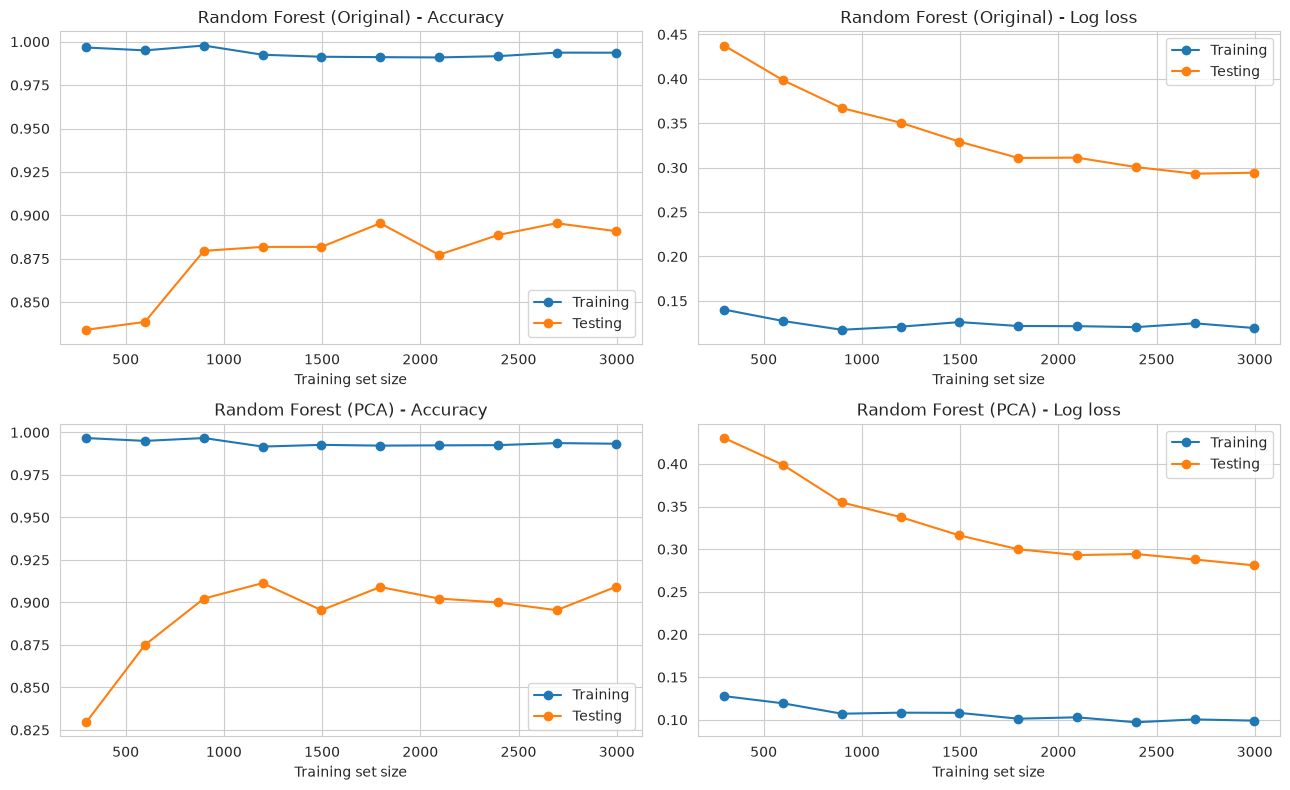

In [197]:
cm_rf = evaluate_model('Random Forest', 'Original', y_test, y_pred_rf)
cm_rf_pca = evaluate_model('Random Forest', 'PCA', yp_test, y_pred_rf_pca)
plot_learning_curves({'Original': (rf_orig, X_train, y_train, X_test, y_test),
                      'PCA': (rf_pca, Xp_train, yp_train, Xp_test, yp_test)}, 'Random Forest')

Analyze the evaluation metrics and visualizations to compare the performance of the models with and without PCA.

,Model,Features,Accuracy,Precision,Recall,F1
0,Random Forest,Original,0.9023,0.6833,0.6308,0.6560
1,Random Forest,PCA,0.9114,0.7321,0.6308,0.6777


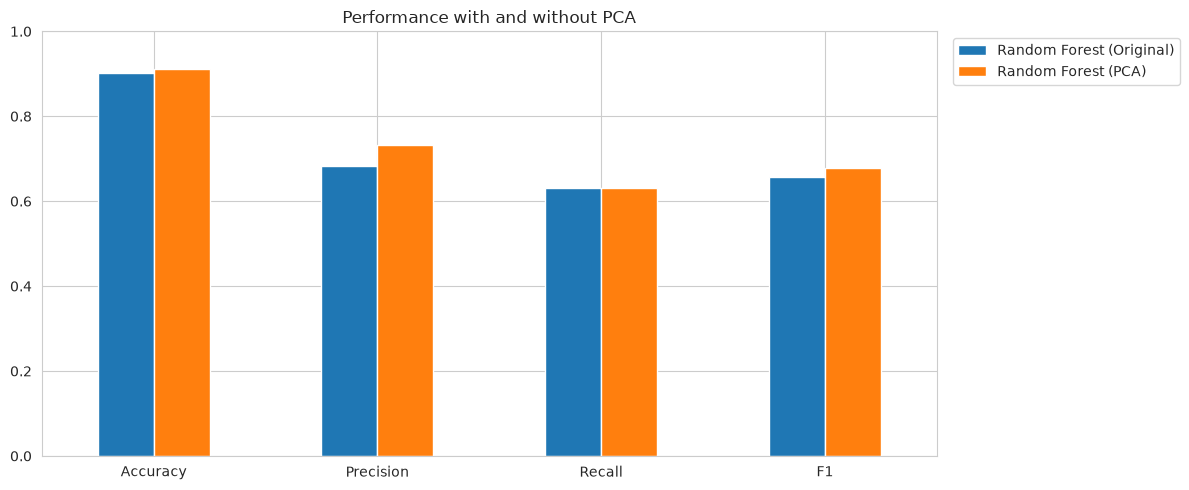

Random Forest: F1 Original=0.6560, PCA=0.6777 -> better F1 with: PCA


In [198]:
compare_models(['Random Forest'])

## Voting Classifiers

Choose base classifiers:

Select a combination of 5 base classifiers to use in the voting classifier.

In [199]:
base_classifiers = [('lr', LogisticRegression(max_iter=1000, random_state=42)),
                    ('knn', KNeighborsClassifier(n_neighbors=best_k)),
                    ('svm', SVC(kernel=best_kernel, probability=True, random_state=42)),
                    ('nb', best_nb()),
                    ('rf', RandomForestClassifier(**best_rf_params, random_state=42))]
print([name for name, _ in base_classifiers])

['lr', 'knn', 'svm', 'nb', 'rf']


Build models with and without PCA:

Create voting classifier models using the original features and the features extracted from PCA.

In [200]:
voting_orig = VotingClassifier(estimators=base_classifiers, voting='soft')
voting_pca = VotingClassifier(estimators=base_classifiers, voting='soft')

Split data into training and testing sets:

Randomly split the data into training and testing sets.

In [201]:
X_train, X_test, y_train, y_test = make_split(X, y)
Xp_train, Xp_test, yp_train, yp_test = make_split(X_pca, y)

Train models:

Train the voting classifier models on the training sets.

In [202]:
voting_orig.fit(X_train, y_train)
voting_pca.fit(Xp_train, yp_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('knn', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...ndom_state=42), KNeighborsCla...n_neighbors=3), SVC(probabili...ndom_state=42), GaussianNB(), ...]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,14


Make predictions:

Use the trained models to make predictions on the testing sets.

In [203]:
y_pred_vote = voting_orig.predict(X_test)
y_pred_vote_pca = voting_pca.predict(Xp_test)

Evaluate performance:

Calculate accuracy, precision, recall, F1-score, and confusion matrix for both models.
Plot the learning curves (training and testing loss/accuracy) for both models.

Voting Classifier (Original): Accuracy=0.8932  Precision=0.5978  Recall=0.8462  F1=0.7006
Confusion matrix:
 [[338  37]
 [ 10  55]] 

Voting Classifier (PCA): Accuracy=0.9045  Precision=0.6420  Recall=0.8000  F1=0.7123
Confusion matrix:
 [[346  29]
 [ 13  52]] 



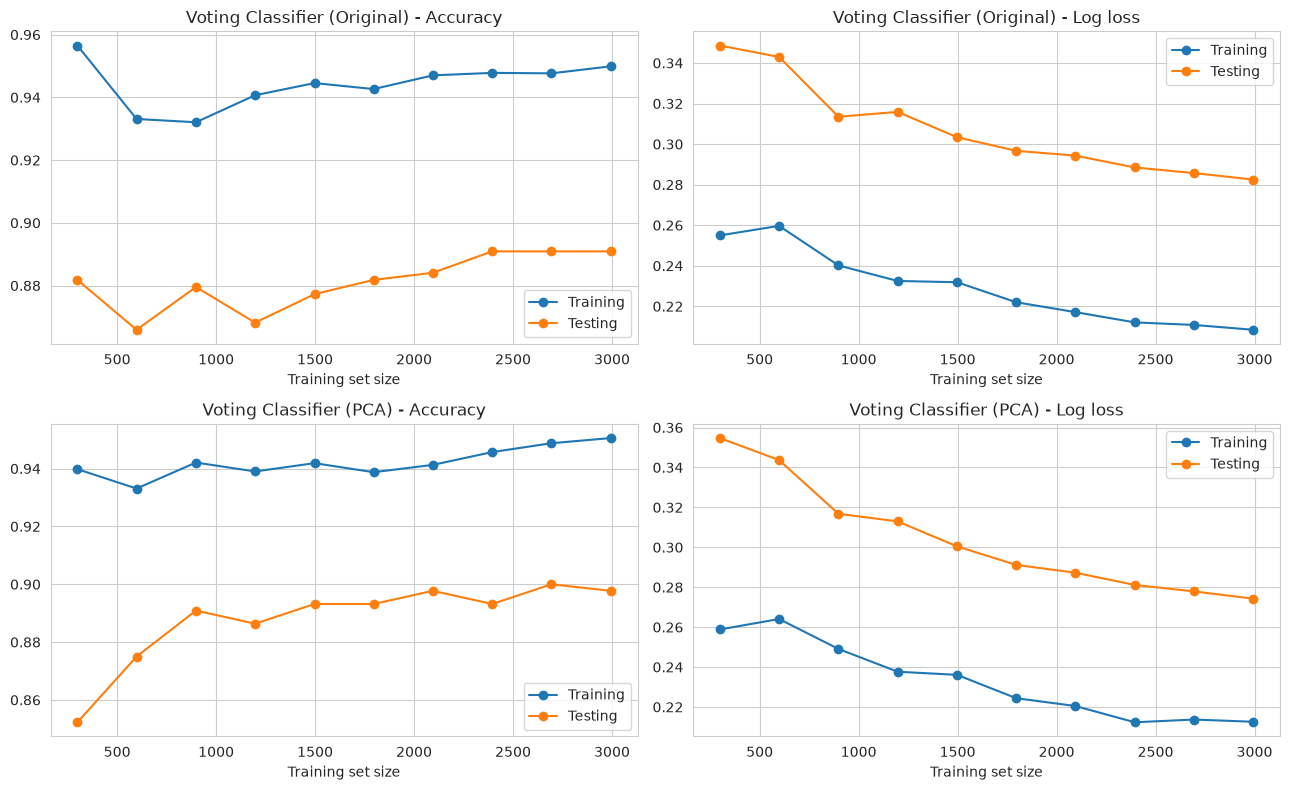

In [204]:
cm_vote = evaluate_model('Voting Classifier', 'Original', y_test, y_pred_vote)
cm_vote_pca = evaluate_model('Voting Classifier', 'PCA', yp_test, y_pred_vote_pca)
plot_learning_curves({'Original': (voting_orig, X_train, y_train, X_test, y_test),
                      'PCA': (voting_pca, Xp_train, yp_train, Xp_test, yp_test)}, 'Voting Classifier')

Compare performance:

Analyze the evaluation metrics and visualizations to compare the performance of the models with and without PCA.

,Model,Features,Accuracy,Precision,Recall,F1
0,Voting Classifier,Original,0.8932,0.5978,0.8462,0.7006
1,Voting Classifier,PCA,0.9045,0.6420,0.8000,0.7123


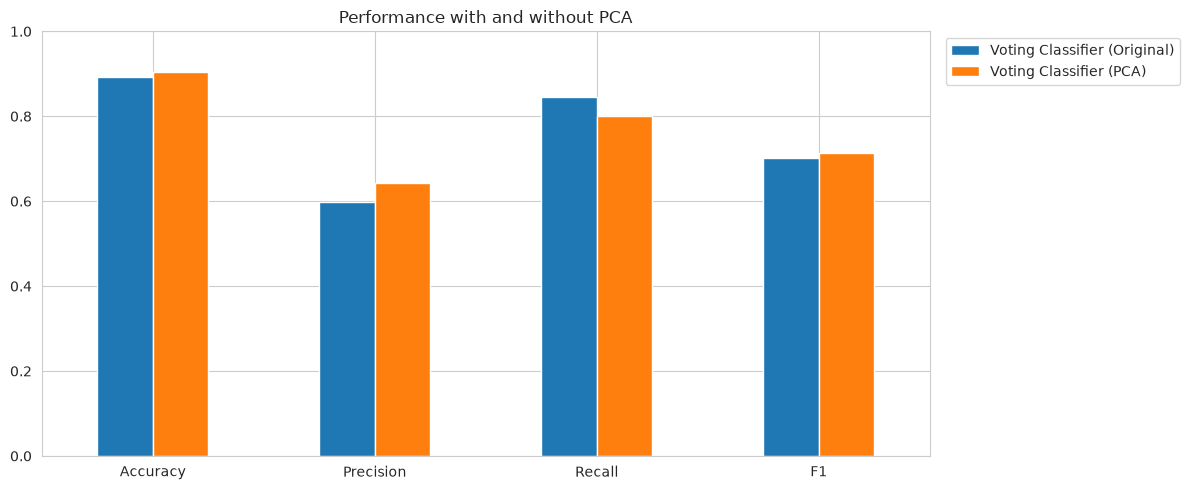

Voting Classifier: F1 Original=0.7006, PCA=0.7123 -> better F1 with: PCA


In [205]:
compare_models(['Voting Classifier'])

## Boosting

Select 3 boosting algorithms (AdaBoost, Gradient Boosting, XGBoost)

In [206]:
def get_boosters():
    return {'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
            'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)}

booster_names = list(get_boosters().keys())
print(booster_names)

['AdaBoost', 'Gradient Boosting', 'XGBoost']


Build models with and without PCA:

Create boosting models using the original features and the features extracted from PCA.

In [207]:
boost_orig = get_boosters()
boost_pca = get_boosters()

Split data into training and testing sets:

Randomly split the data into training and testing sets.

In [208]:
X_train, X_test, y_train, y_test = make_split(X, y)
Xp_train, Xp_test, yp_train, yp_test = make_split(X_pca, y)

Train models:

Train the boosting models on the training sets.

In [209]:
for name in booster_names:
    boost_orig[name].fit(X_train, y_train)
    boost_pca[name].fit(Xp_train, yp_train)

Make predictions:

Use the trained models to make predictions on the testing sets.

In [210]:
y_pred_boost = {name: boost_orig[name].predict(X_test) for name in booster_names}
y_pred_boost_pca = {name: boost_pca[name].predict(Xp_test) for name in booster_names}

Evaluate performance:

Calculate accuracy, precision, recall, F1-score, and confusion matrix for both models.
Plot the learning curves (training and testing loss/accuracy) for both models.

AdaBoost (Original): Accuracy=0.8636  Precision=0.5238  Recall=0.8462  F1=0.6471
Confusion matrix:
 [[325  50]
 [ 10  55]] 

AdaBoost (PCA): Accuracy=0.8591  Precision=0.5155  Recall=0.7692  F1=0.6173
Confusion matrix:
 [[328  47]
 [ 15  50]] 



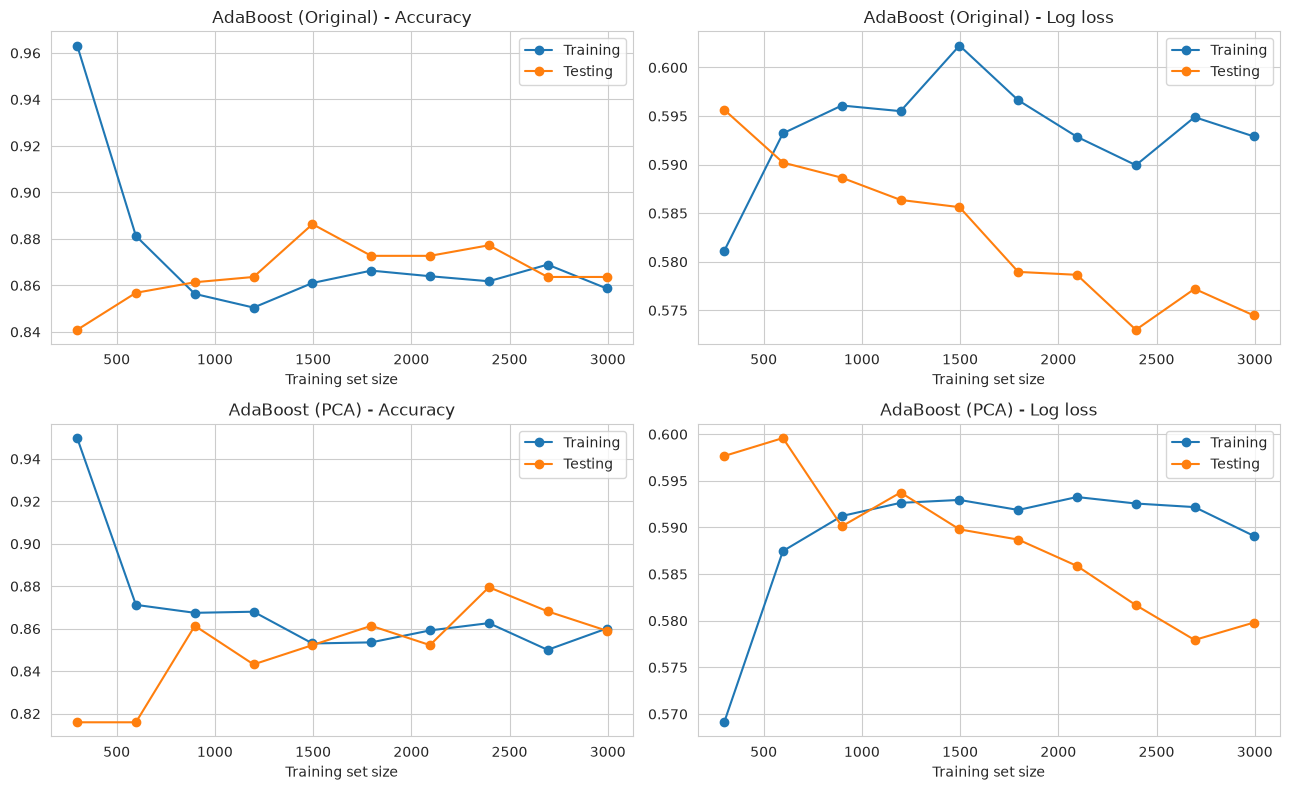

Gradient Boosting (Original): Accuracy=0.8886  Precision=0.5851  Recall=0.8462  F1=0.6918
Confusion matrix:
 [[336  39]
 [ 10  55]] 

Gradient Boosting (PCA): Accuracy=0.8795  Precision=0.5682  Recall=0.7692  F1=0.6536
Confusion matrix:
 [[337  38]
 [ 15  50]] 



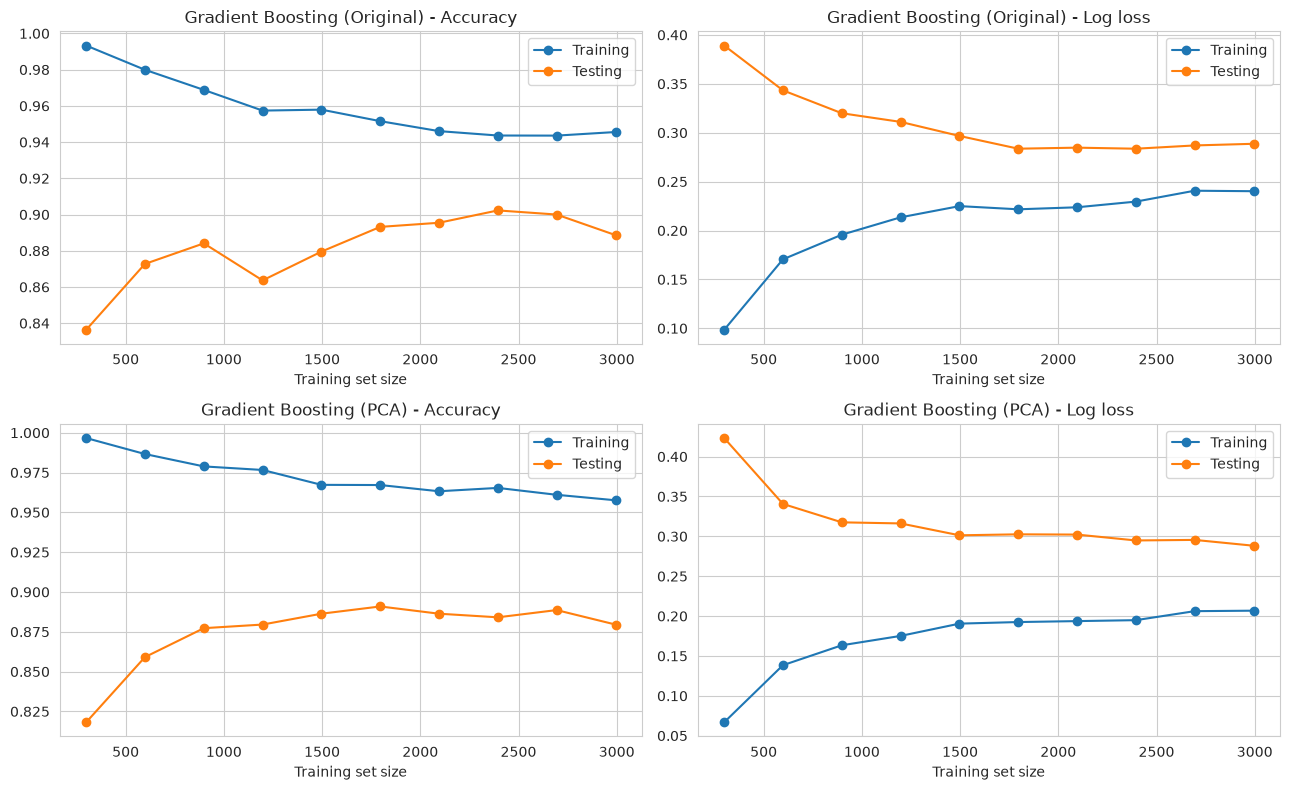

XGBoost (Original): Accuracy=0.8955  Precision=0.6792  Recall=0.5538  F1=0.6102
Confusion matrix:
 [[358  17]
 [ 29  36]] 

XGBoost (PCA): Accuracy=0.9136  Precision=0.7213  Recall=0.6769  F1=0.6984
Confusion matrix:
 [[358  17]
 [ 21  44]] 



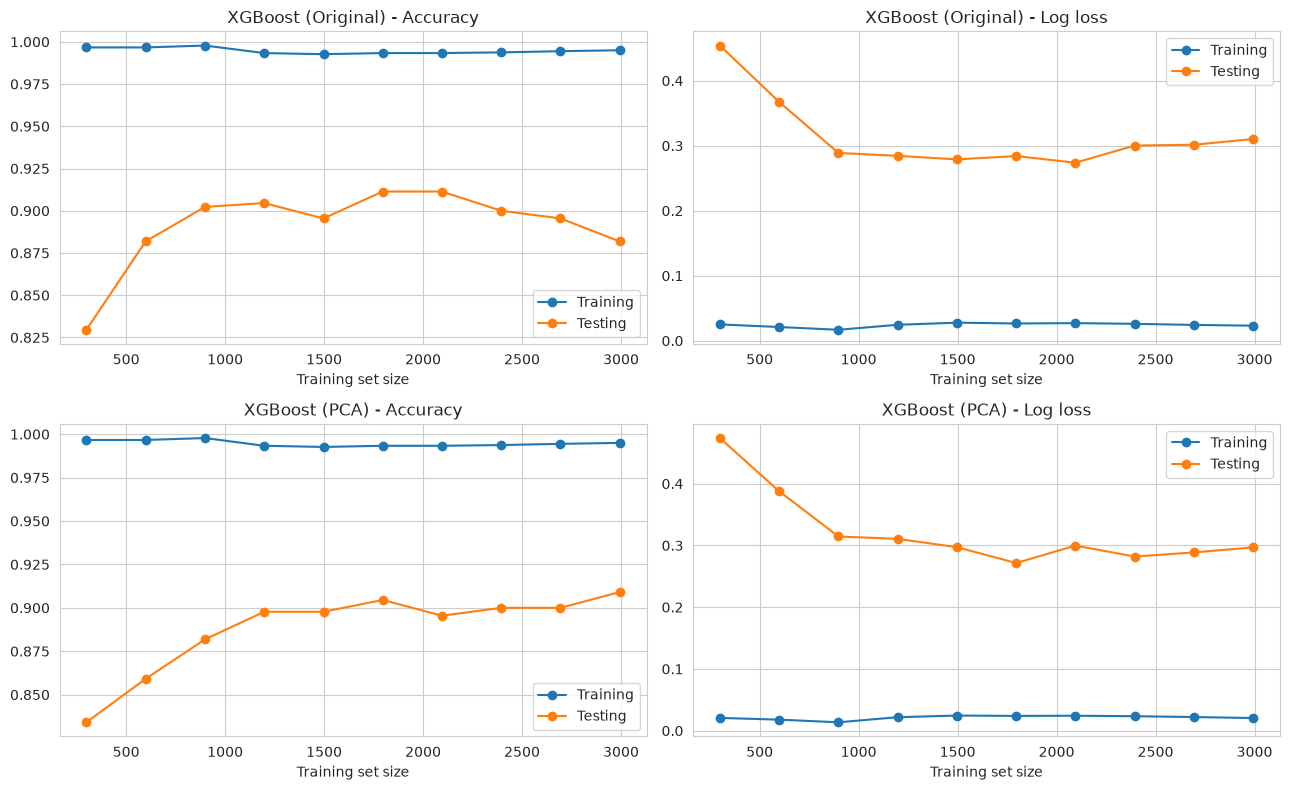

In [211]:
for name in booster_names:
    evaluate_model(name, 'Original', y_test, y_pred_boost[name])
    evaluate_model(name, 'PCA', yp_test, y_pred_boost_pca[name])
    plot_learning_curves({'Original': (boost_orig[name], X_train, y_train, X_test, y_test),
                          'PCA': (boost_pca[name], Xp_train, yp_train, Xp_test, yp_test)}, name)

Compare performance:

Analyze the evaluation metrics and visualizations to compare the performance of the models with and without PCA.

,Model,Features,Accuracy,Precision,Recall,F1
0,AdaBoost,Original,0.8636,0.5238,0.8462,0.6471
1,AdaBoost,PCA,0.8591,0.5155,0.7692,0.6173
2,Gradient Boosting,Original,0.8886,0.5851,0.8462,0.6918
3,Gradient Boosting,PCA,0.8795,0.5682,0.7692,0.6536
4,XGBoost,Original,0.8955,0.6792,0.5538,0.6102
5,XGBoost,PCA,0.9136,0.7213,0.6769,0.6984


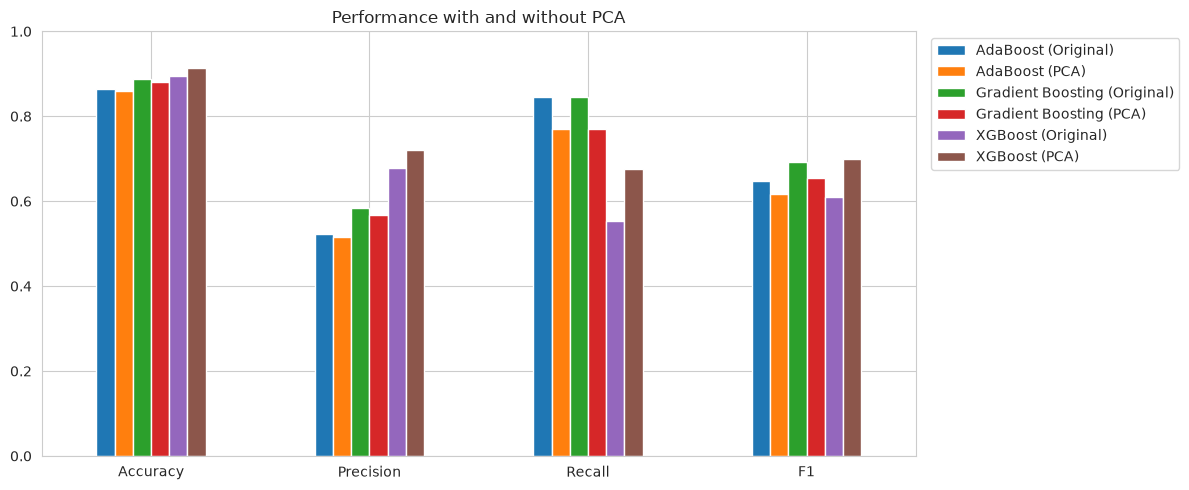

AdaBoost: F1 Original=0.6471, PCA=0.6173 -> better F1 with: Original
Gradient Boosting: F1 Original=0.6918, PCA=0.6536 -> better F1 with: Original
XGBoost: F1 Original=0.6102, PCA=0.6984 -> better F1 with: PCA


In [212]:
compare_models(booster_names)